Exploring the Link Between Personality Traits and Substance Use

Dataset: https://www.kaggle.com/datasets/mexwell/drug-consumption-classification/data

Importing both necessary and custom modules

In [1]:
import sys
import pandas as pd
import plotnine as pn
import sklearn as sk
import numpy as np
import data_analysis
import data_reading
import matplotlib.pyplot as plt
from scipy import stats

Read in the data

In [2]:
data = data_reading.read_data("data/drug_consumption.csv")
dataOG = data.copy()
human_readable_data = data_reading.convert_data(data)
human_readable_data = data_reading.convert_drug_usage_classifiers(human_readable_data)
print(list(data_reading.EDUCATION.values()))
human_readable_data["Education"] = pd.Categorical(
        human_readable_data["Education"],
        categories=list(data_reading.EDUCATION.values()),
        ordered=True,
    )
human_readable_data

['Left School Before 16 years', 'Left School at 16 years', 'Left School at 17 years', 'Left School at 18 years', 'Some College, No Certificate/Degree', 'Professional Certificate/Diploma', 'University Degree', "Master's Degree", 'Doctorate Degree']


,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,35-44,Female,Professional Certificate/Diploma,UK,Mixed-White/Asian,39.0,36.0,42.0,37.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
1,2,25-34,Male,Doctorate Degree,UK,White,29.0,52.0,55.0,48.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Year,Never Used,Used in Last Month,Never Used,Never Used
2,3,35-44,Male,Professional Certificate/Diploma,UK,White,31.0,45.0,40.0,32.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used
3,4,18-24,Female,Master's Degree,UK,White,34.0,34.0,46.0,47.0,...,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
4,5,35-44,Female,Doctorate Degree,UK,White,43.0,28.0,43.0,41.0,...,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used,Never Used
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,18-24,Female,"Some College, No Certificate/Degree",USA,White,25.0,51.0,57.0,48.0,...,Never Used,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Never Used,Never Used,Never Used,Used in Last Week
1881,1885,18-24,Male,"Some College, No Certificate/Degree",USA,White,33.0,51.0,50.0,48.0,...,Used in Last Decade,Never Used,Never Used,Used in Last Year,Used in Last Week,Used in Last Month,Used in Last Month,Used in Last Week,Never Used,Never Used
1882,1886,25-34,Female,University Degree,USA,White,47.0,30.0,37.0,31.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Day,Never Used,Never Used
1883,1887,18-24,Female,"Some College, No Certificate/Degree",USA,White,45.0,26.0,48.0,32.0,...,Used in Last Year,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Used in Last Year,Used in Last Month,Never Used,Never Used


Make a DataFrame useful for categorizing drugs

In [3]:
# Bring data to a shape possible to be shown as a plot
drug_usage = data_analysis.get_columns_unique_value_counts(data[data_reading.DRUG_TYPES])
drug_usage = drug_usage.transpose().reset_index(names="Drug")
drug_usage = drug_usage.melt(id_vars="Drug", var_name="Usage", value_name="Amount")

# Replace NaN amounts with 0-s
drug_usage = drug_usage.fillna(0)

drug_usage

,Drug,Usage,Amount
0,Alcohol,CL0,34.0
1,Amphet,CL0,976.0
2,Amyl,CL0,1305.0
3,Benzos,CL0,1000.0
4,Caff,CL0,27.0
...,...,...,...
128,Meth,CL6,73.0
129,Mushrooms,CL6,4.0
130,Nicotine,CL6,610.0
131,Semer,CL6,0.0


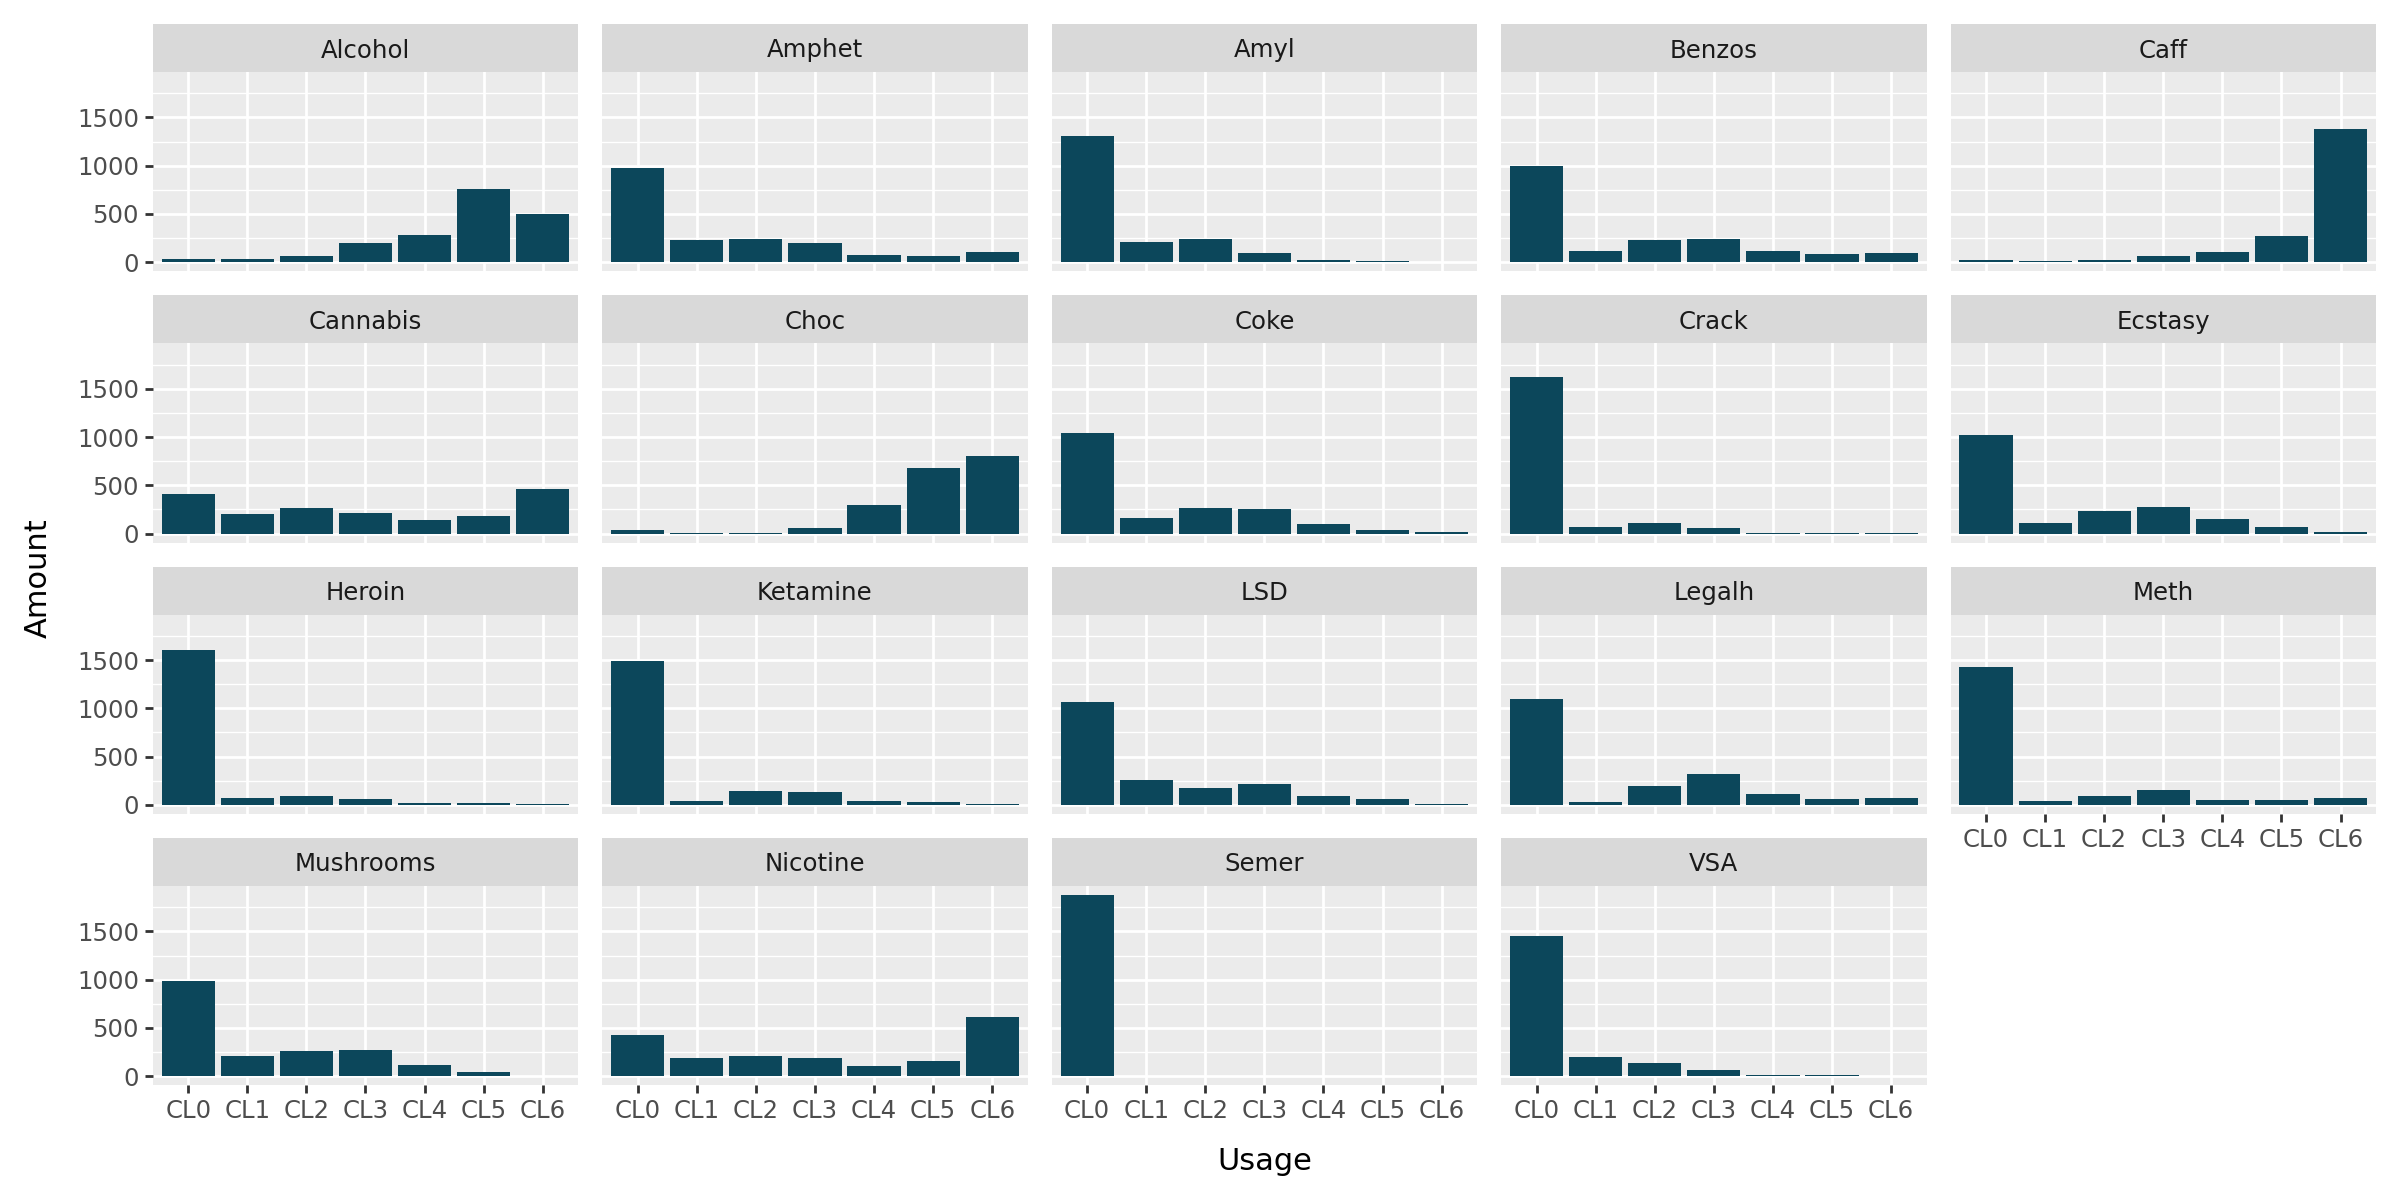

In [4]:
(
    pn.ggplot(drug_usage, pn.aes("Usage", "Amount", fill="Drug")) 
    + pn.geom_col(fill="#0C475B") 
    + pn.facet_wrap("Drug")
    + pn.theme(figure_size=(12, 6))
)

In [5]:
drug_users = drug_usage[drug_usage["Usage"] != "CL0"]
drug_users = drug_users.groupby(["Drug"], as_index=False)["Amount"].sum()
drug_users["Amount"] = drug_users["Amount"].astype(int)

# Sort values
drug_users = drug_users.assign(
    Drug=pd.Categorical(drug_users["Drug"], categories=drug_users.sort_values("Amount", ascending=False)["Drug"])
)

drug_users

,Drug,Amount
0,Alcohol,1851
1,Amphet,909
2,Amyl,580
3,Benzos,885
4,Caff,1858
5,Cannabis,1472
6,Choc,1853
7,Coke,847
8,Crack,258
9,Ecstasy,864


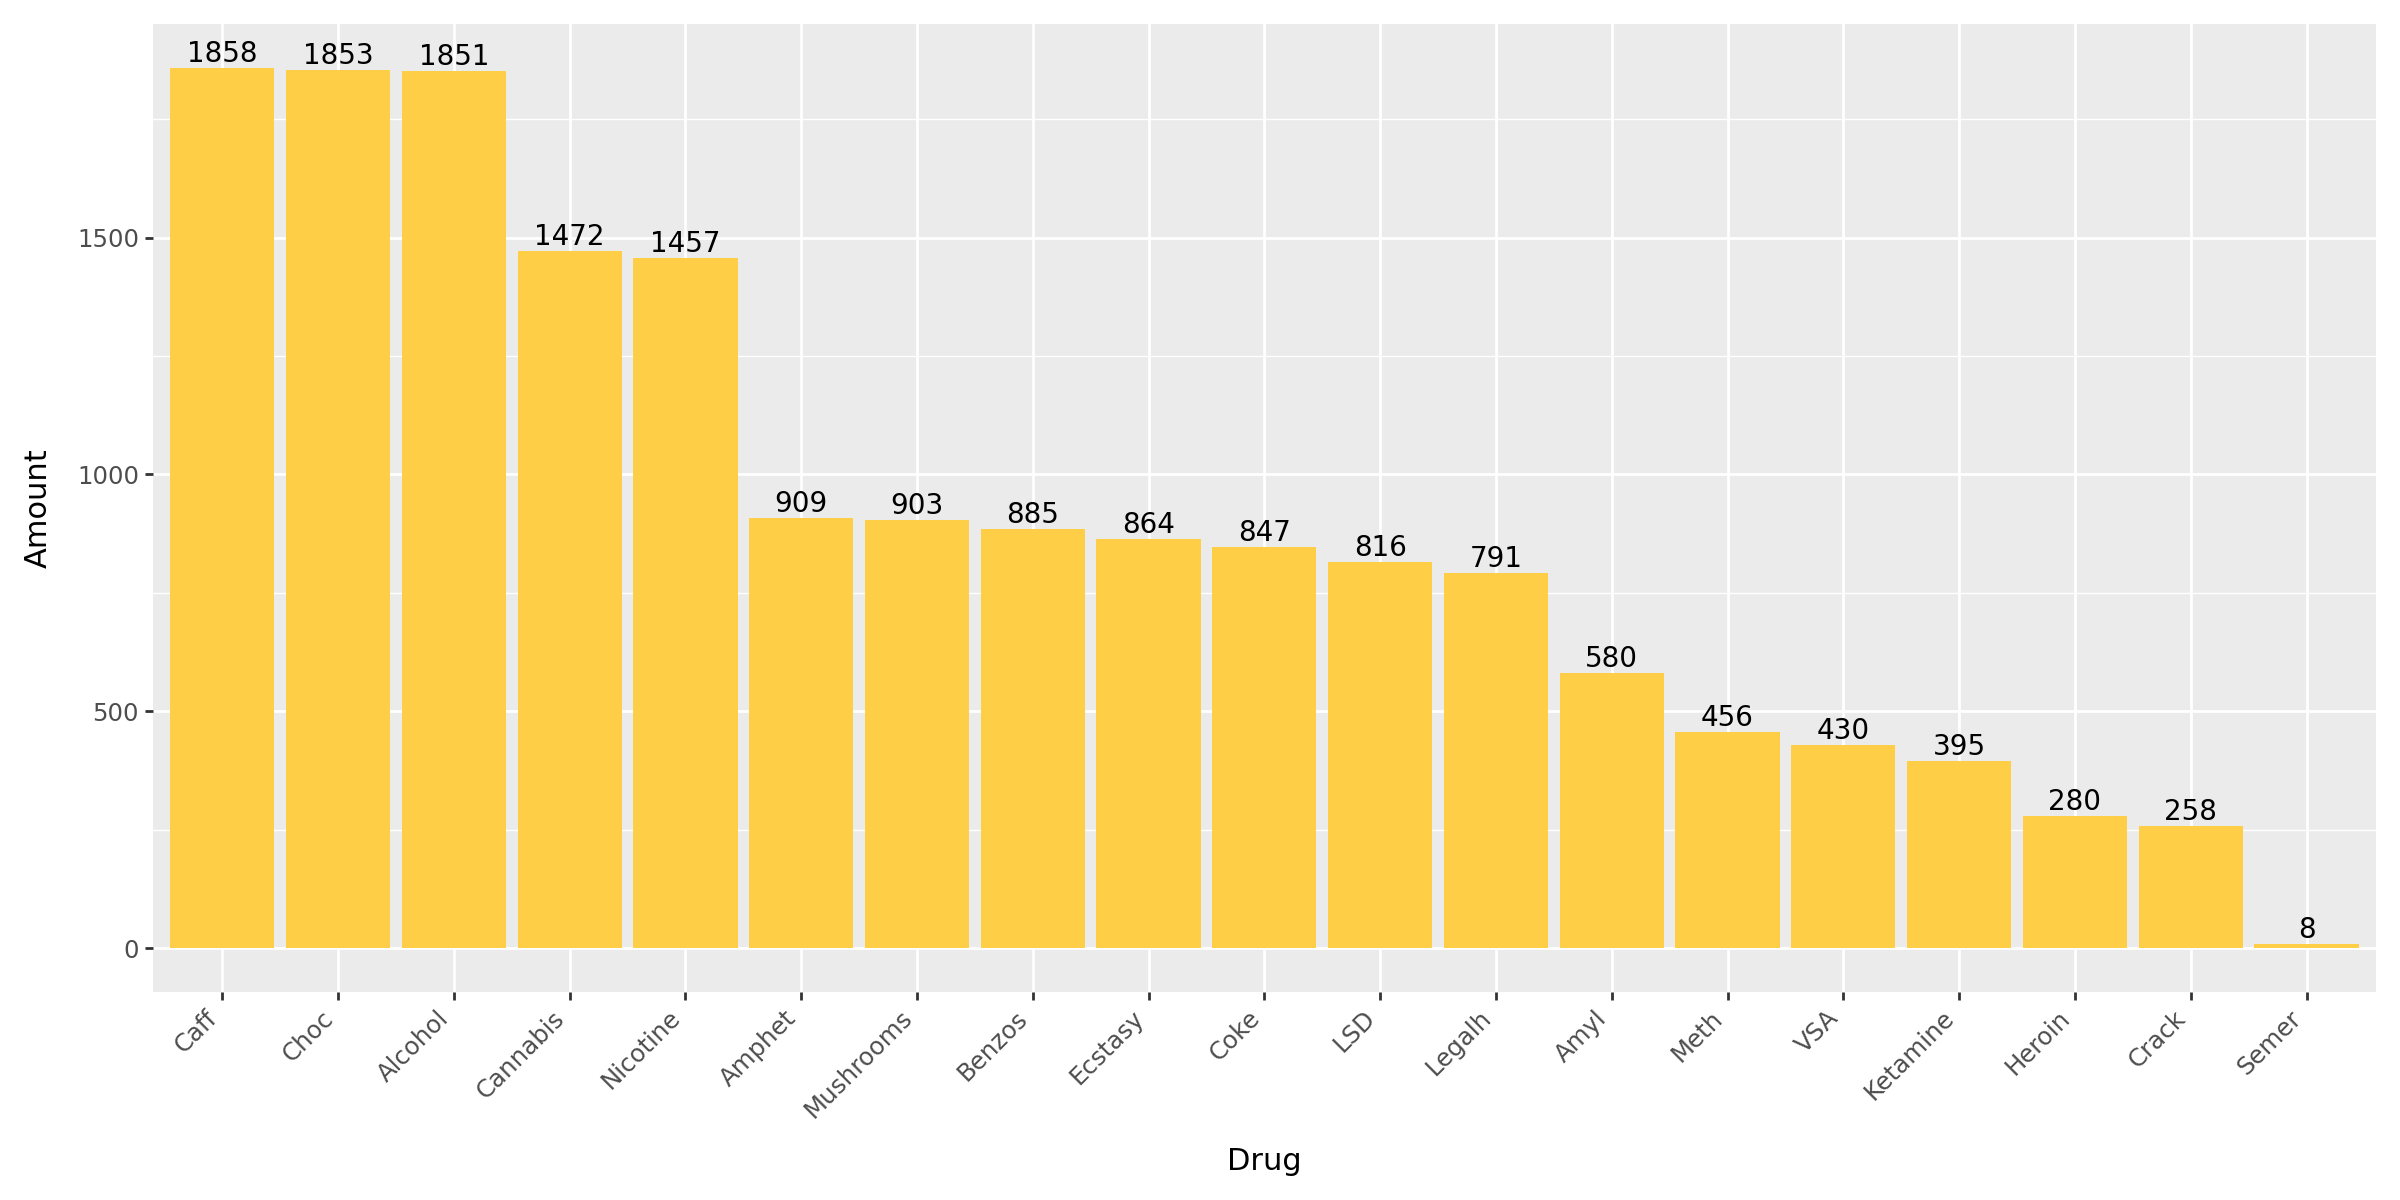

In [6]:
(
    pn.ggplot(drug_users, pn.aes("Drug", "Amount"))
    + pn.geom_col(fill="#ffce47")
    + pn.geom_text(pn.aes(label = "Amount"), size=10, va="bottom")
    + pn.labs(y="Amount")
    + pn.theme(figure_size=(12, 6), axis_text_x=pn.element_text(rotation=45, hjust=1))
)

Visualize the distribution of demographics

In [7]:
countries = human_readable_data.groupby("Country")["Country"].size().rename("Count").reset_index()

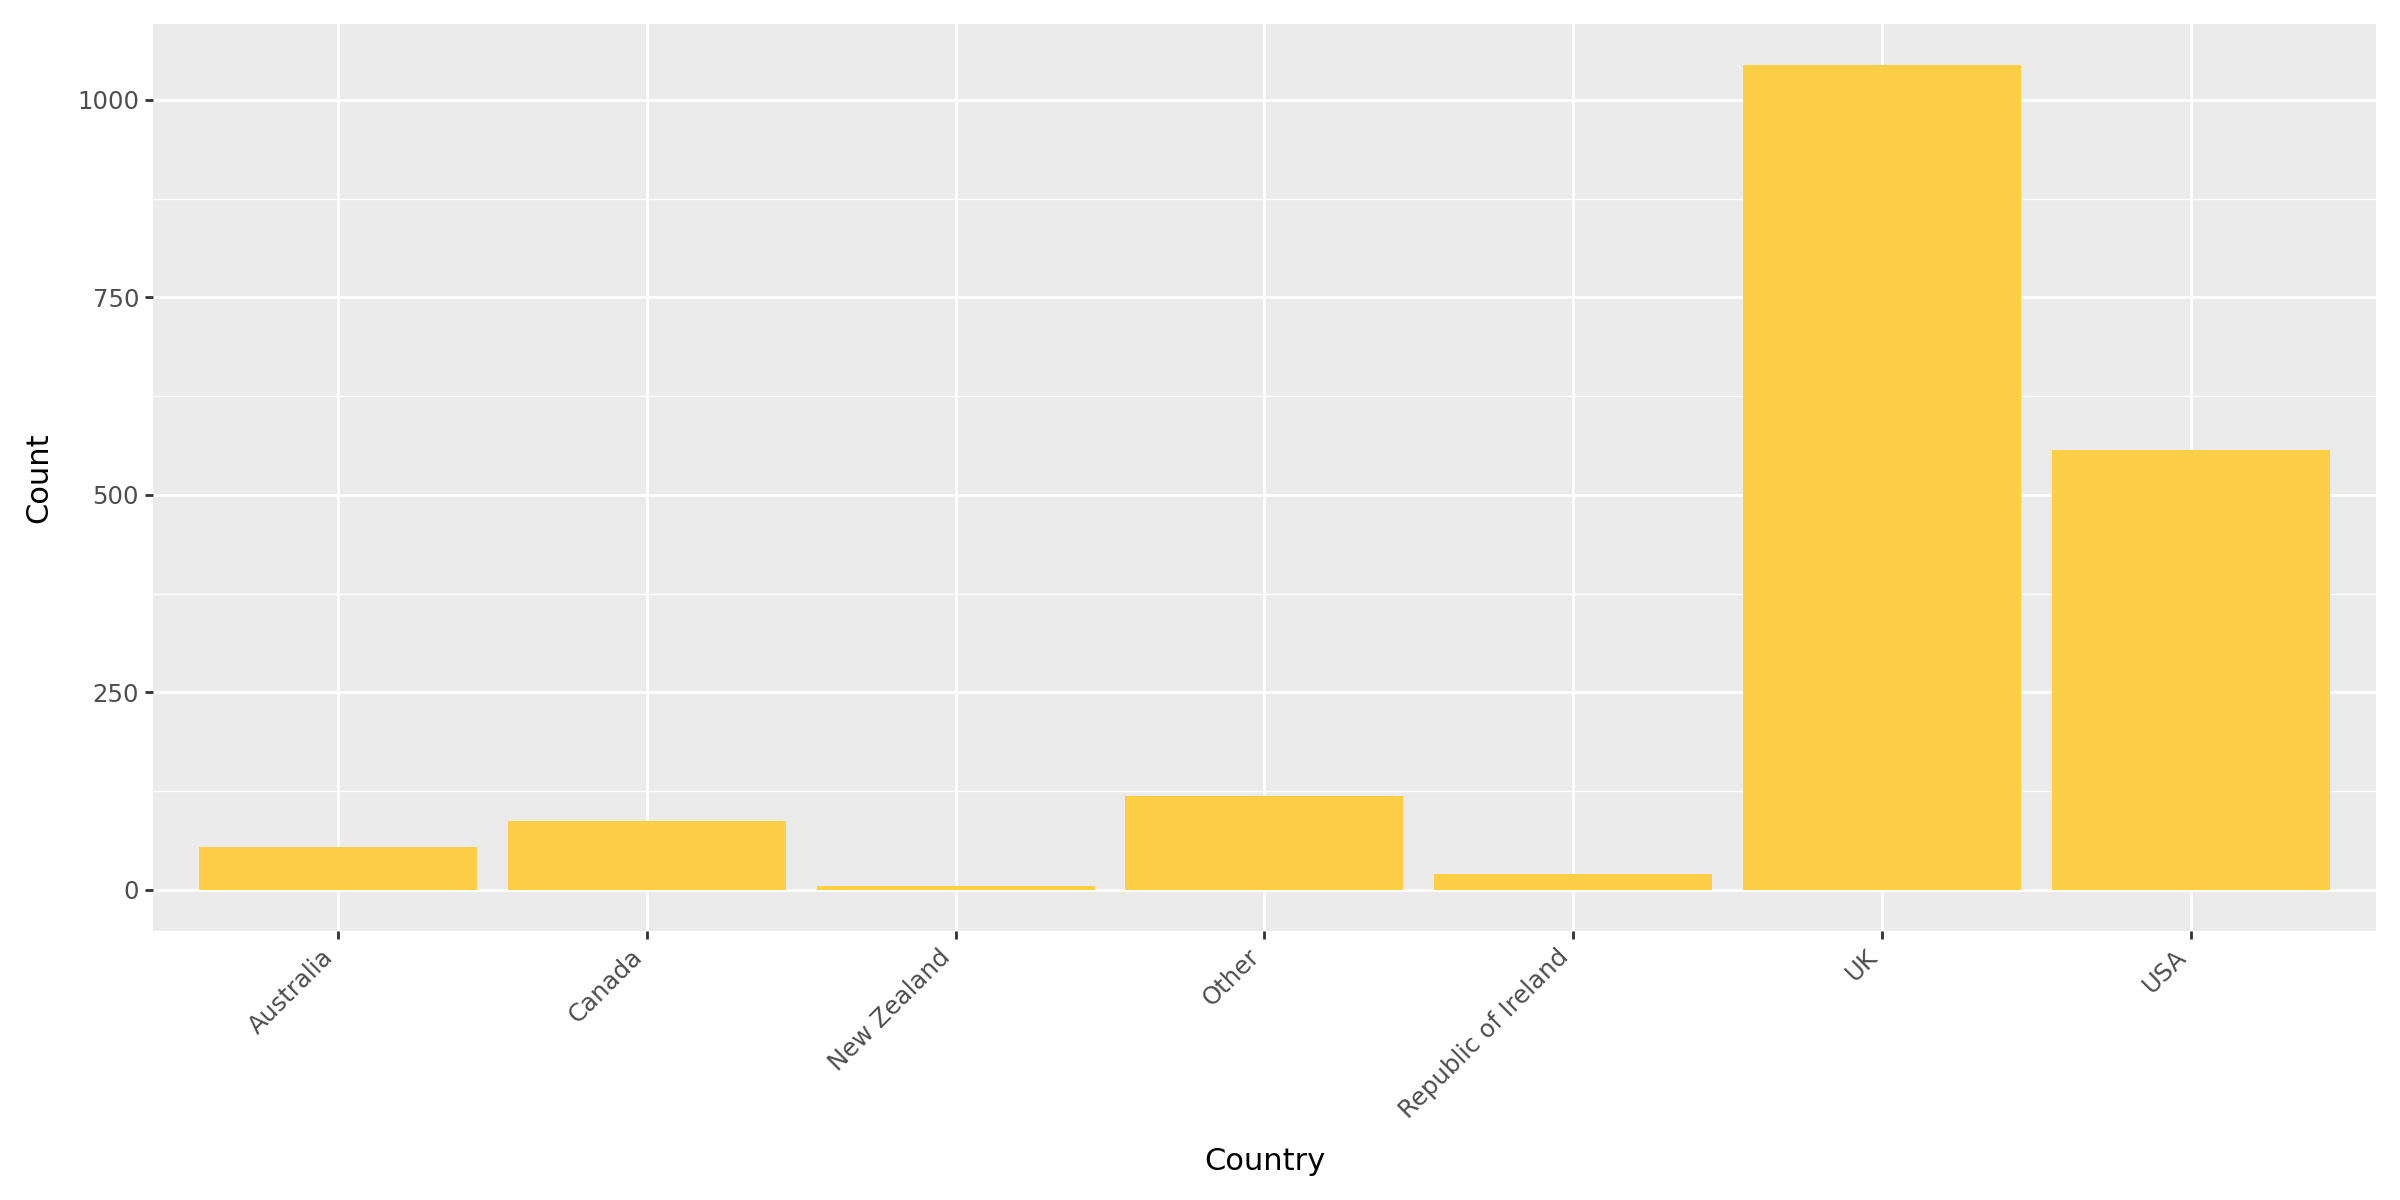

In [8]:
(
    pn.ggplot(countries, pn.aes("Country", "Count"))
    + pn.geom_col(fill="#ffce47")
    + pn.theme(figure_size=(12, 6), axis_text_x=pn.element_text(rotation=45, hjust=1))
)

Filter out data from countries other than UK and USA, due to lack of data (too few samples). It is to reduce the amount of change due to cultural and regional differences.

In [9]:
human_readable_data = human_readable_data[human_readable_data["Country"].isin(["USA", "UK"])]
data = data[data["Country"].isin([0.96082, -0.57009])]
human_readable_data

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,35-44,Female,Professional Certificate/Diploma,UK,Mixed-White/Asian,39.0,36.0,42.0,37.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
1,2,25-34,Male,Doctorate Degree,UK,White,29.0,52.0,55.0,48.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Year,Never Used,Used in Last Month,Never Used,Never Used
2,3,35-44,Male,Professional Certificate/Diploma,UK,White,31.0,45.0,40.0,32.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used
3,4,18-24,Female,Master's Degree,UK,White,34.0,34.0,46.0,47.0,...,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
4,5,35-44,Female,Doctorate Degree,UK,White,43.0,28.0,43.0,41.0,...,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used,Never Used
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,1881,18-24,Male,Left School at 17 years,USA,White,50.0,26.0,42.0,31.0,...,Used in Last Decade,Used in Last Week,Never Used,Used in Last Decade,Never Used,Used in Last Day,Never Used,Used in Last Day,Never Used,Used in Last Decade
1880,1884,18-24,Female,"Some College, No Certificate/Degree",USA,White,25.0,51.0,57.0,48.0,...,Never Used,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Never Used,Never Used,Never Used,Used in Last Week
1881,1885,18-24,Male,"Some College, No Certificate/Degree",USA,White,33.0,51.0,50.0,48.0,...,Used in Last Decade,Never Used,Never Used,Used in Last Year,Used in Last Week,Used in Last Month,Used in Last Month,Used in Last Week,Never Used,Never Used
1882,1886,25-34,Female,University Degree,USA,White,47.0,30.0,37.0,31.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Day,Never Used,Never Used


Also filter out Semer, since it was a fictitious drug (Semeron) which was introduced to identify over-claimers

In [10]:
human_readable_data = human_readable_data[human_readable_data["Semer"] == "Never Used"]
data = data[data["Semer"] == "Never Used"]
human_readable_data = human_readable_data.drop("Semer", axis=1)
data = data.drop("Semer", axis=1)
data_reading.DRUG_TYPES.remove("Semer")

Get drug usage and personality trait dataframe

In [11]:
columns = data_reading.PERSONALITY_TRAITS + data_reading.DRUG_TYPES
drug_personality_grouping = human_readable_data[columns]
drug_personality_grouping

,Nscore,Ascore,Oscore,Escore,Cscore,Impulsive,SS,Alcohol,Amphet,Amyl,...,Crack,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,VSA
0,39.0,37.0,42.0,36.0,42.0,4.0,3.0,Used in Last Week,Used in Last Decade,Never Used,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used
1,29.0,48.0,55.0,52.0,41.0,3.0,6.0,Used in Last Week,Used in Last Decade,Used in Last Decade,...,Never Used,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Year,Never Used,Used in Last Month,Never Used
2,31.0,32.0,40.0,45.0,34.0,2.0,8.0,Used in Last Day,Never Used,Never Used,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used
3,34.0,47.0,46.0,34.0,46.0,2.0,3.0,Used in Last Month,Never Used,Never Used,...,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used
4,43.0,41.0,43.0,28.0,50.0,4.0,6.0,Used in Last Month,Used over a Decade Ago,Used over a Decade Ago,...,Never Used,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,50.0,31.0,42.0,26.0,46.0,4.0,10.0,Used in Last Day,Used in Last Decade,Never Used,...,Never Used,Used in Last Decade,Used in Last Week,Never Used,Used in Last Decade,Never Used,Used in Last Day,Never Used,Used in Last Day,Used in Last Decade
1880,25.0,48.0,57.0,51.0,33.0,7.0,11.0,Used in Last Week,Never Used,Never Used,...,Never Used,Never Used,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Never Used,Never Used,Used in Last Week
1881,33.0,48.0,50.0,51.0,30.0,7.0,9.0,Used in Last Week,Never Used,Never Used,...,Never Used,Used in Last Decade,Never Used,Never Used,Used in Last Year,Used in Last Week,Used in Last Month,Used in Last Month,Used in Last Week,Never Used
1882,47.0,31.0,37.0,30.0,31.0,6.0,5.0,Used in Last Month,Used in Last Day,Used in Last Week,...,Never Used,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Day,Never Used


In [12]:
drug_index = pd.MultiIndex.from_product(
    [data_reading.DRUG_TYPES, data_reading.DRUG_CLASSIFIER.values()], 
    names=["Drug", "Classifier"]
)
drug_index

MultiIndex([( 'Alcohol',             'Never Used'),
            ( 'Alcohol', 'Used over a Decade Ago'),
            ( 'Alcohol',    'Used in Last Decade'),
            ( 'Alcohol',      'Used in Last Year'),
            ( 'Alcohol',     'Used in Last Month'),
            ( 'Alcohol',      'Used in Last Week'),
            ( 'Alcohol',       'Used in Last Day'),
            (  'Amphet',             'Never Used'),
            (  'Amphet', 'Used over a Decade Ago'),
            (  'Amphet',    'Used in Last Decade'),
            ...
            ('Nicotine',     'Used in Last Month'),
            ('Nicotine',      'Used in Last Week'),
            ('Nicotine',       'Used in Last Day'),
            (     'VSA',             'Never Used'),
            (     'VSA', 'Used over a Decade Ago'),
            (     'VSA',    'Used in Last Decade'),
            (     'VSA',      'Used in Last Year'),
            (     'VSA',     'Used in Last Month'),
            (     'VSA',      'Used in Last Week

Get all single drug users

In [13]:
grouped_usage = pd.DataFrame(columns=["Drug", "Classifier", "Trait", "Score"])
for drug_type in data_reading.DRUG_TYPES:
    single_drug_grouping = drug_personality_grouping[data_reading.PERSONALITY_TRAITS + [drug_type]]
    single_drug_grouping = single_drug_grouping.groupby(drug_type).mean().reset_index()
    single_drug_grouping = single_drug_grouping.rename(columns={drug_type: "Classifier"})
    single_drug_grouping["Drug"] = drug_type

    melted = single_drug_grouping.melt(
        id_vars=["Drug", "Classifier"],
        value_vars=data_reading.PERSONALITY_TRAITS,
        var_name="Trait",
        value_name="Score"
    )
    
    grouped_usage = pd.concat(
        (grouped_usage, melted)
    )

grouped_usage

/tmp/ipykernel_35366/323744696.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


,Drug,Classifier,Trait,Score
0,Alcohol,Never Used,Nscore,34.807692
1,Alcohol,Used in Last Day,Nscore,36.232877
2,Alcohol,Used in Last Decade,Nscore,38.898305
3,Alcohol,Used in Last Month,Nscore,36.214286
4,Alcohol,Used in Last Week,Nscore,35.150456
...,...,...,...,...
44,VSA,Used in Last Decade,SS,8.407080
45,VSA,Used in Last Month,SS,8.500000
46,VSA,Used in Last Week,SS,9.900000
47,VSA,Used in Last Year,SS,8.229167


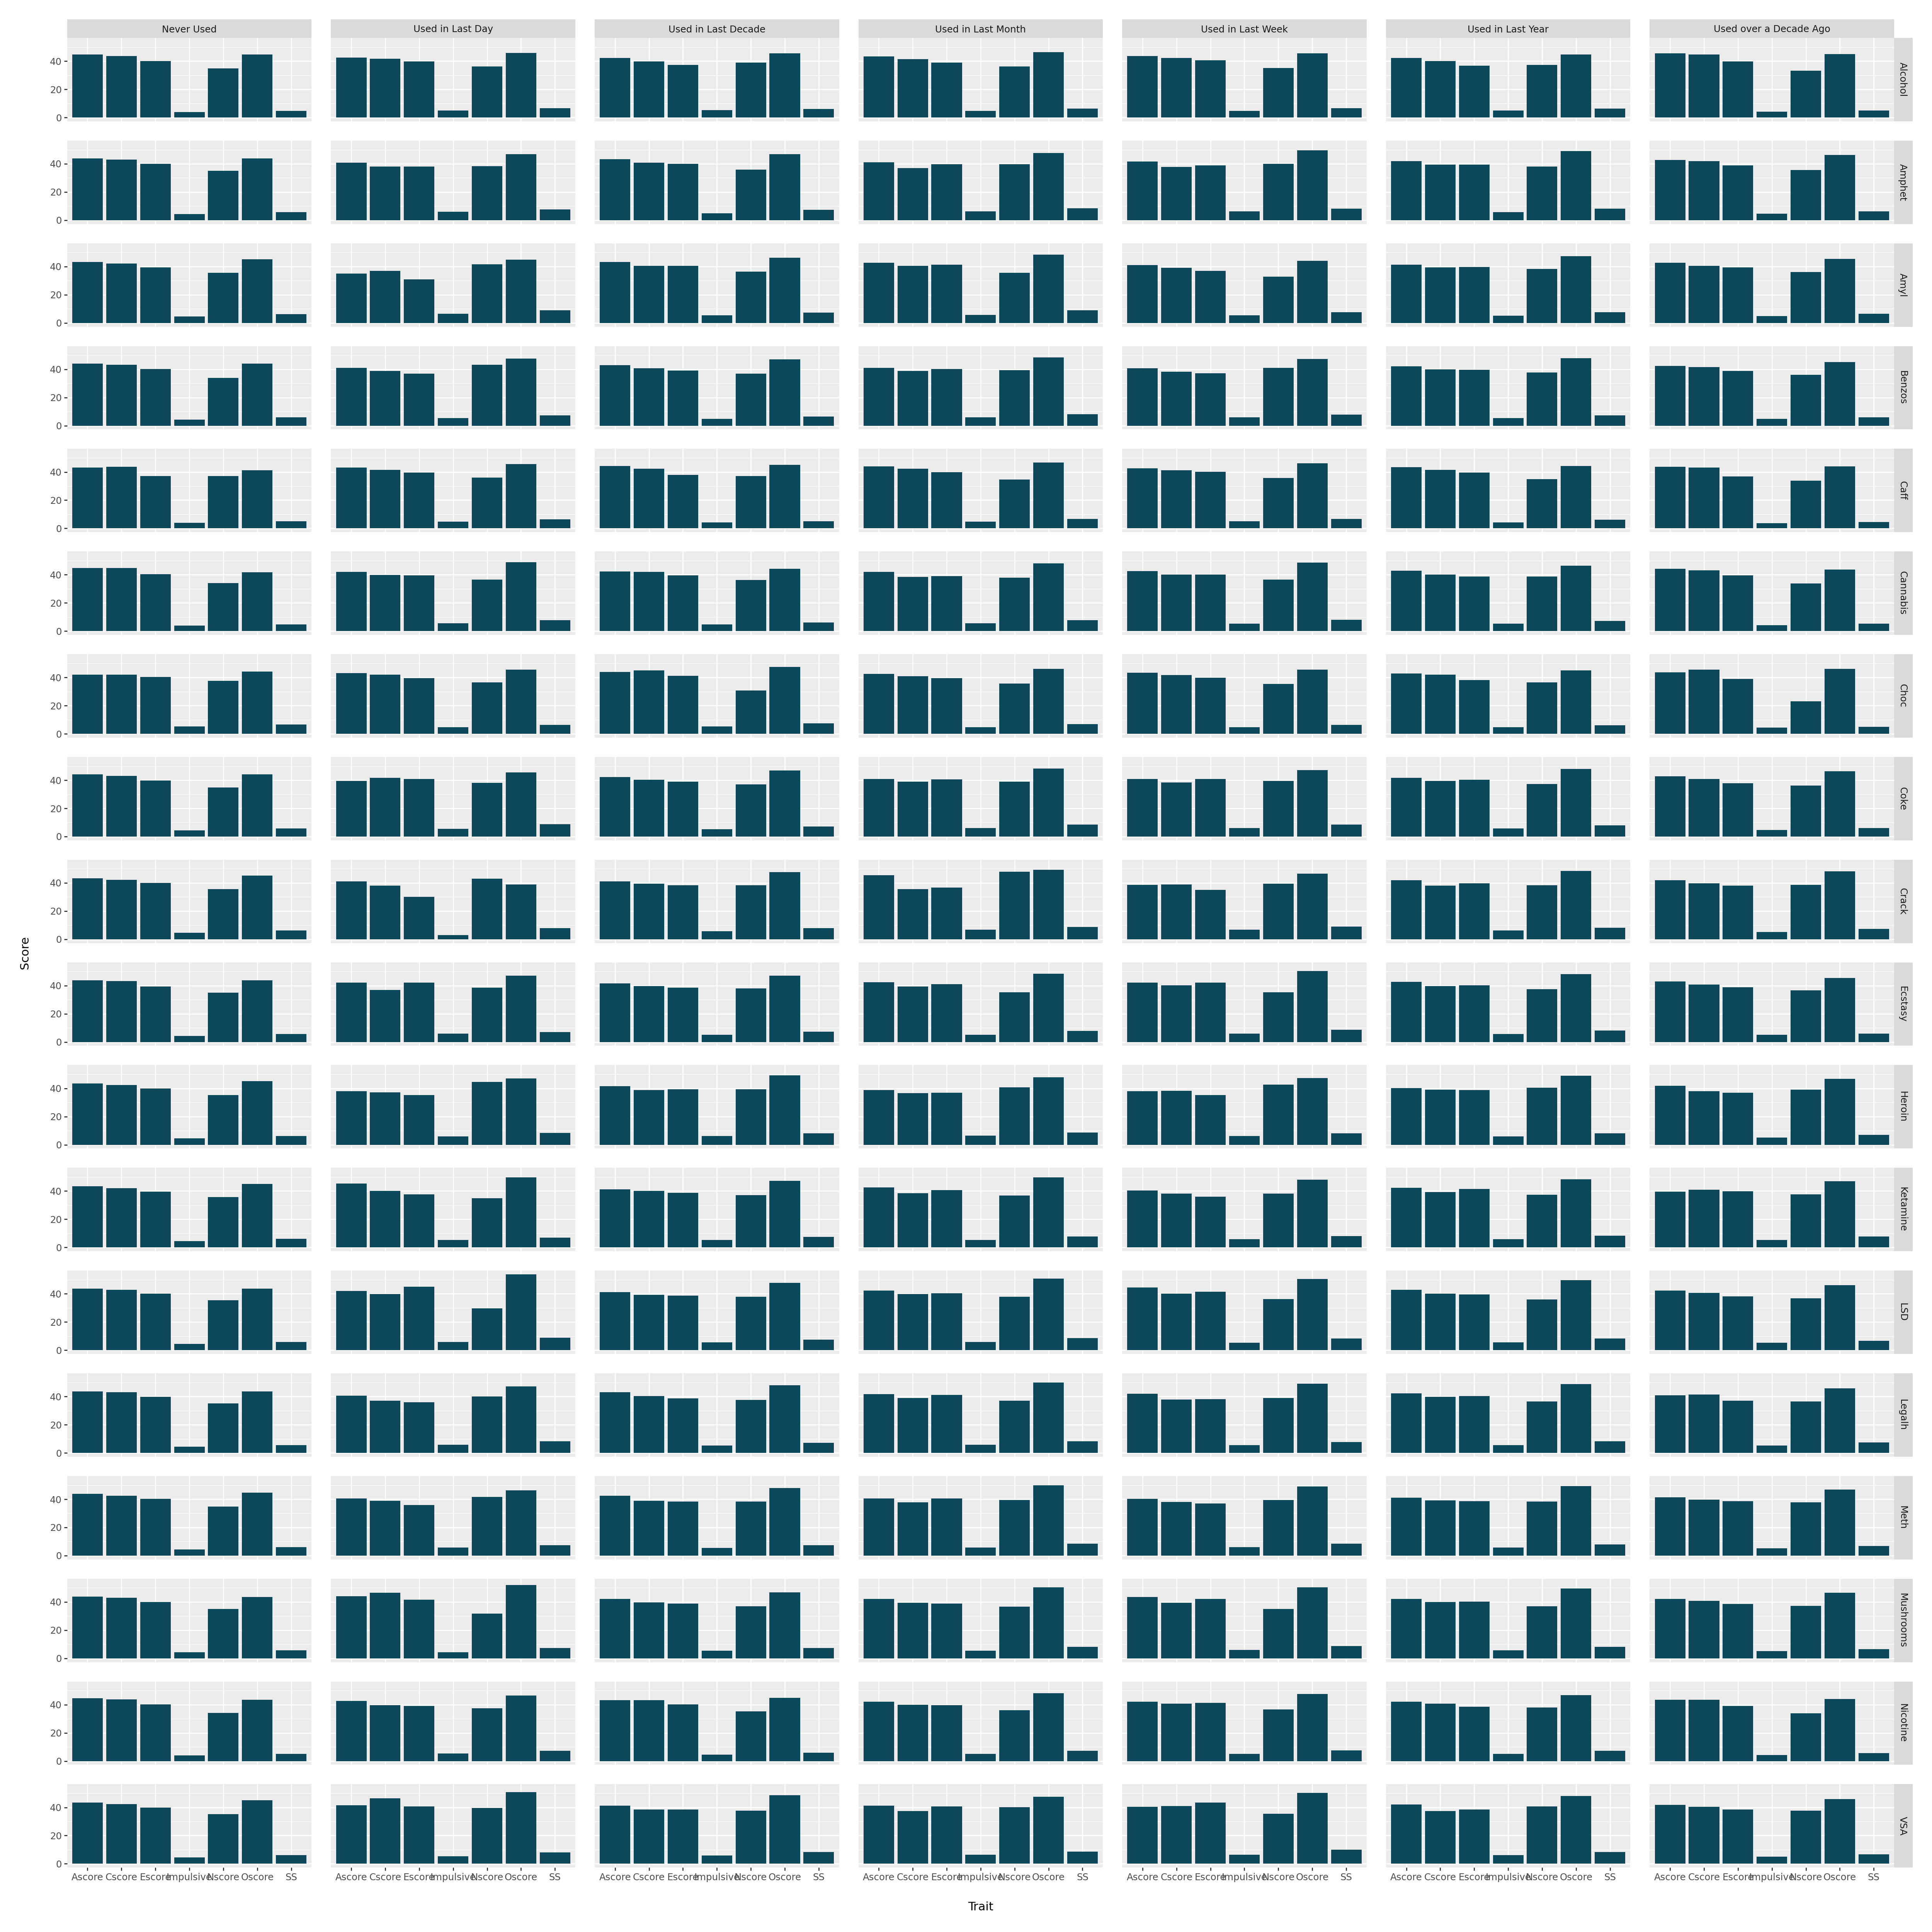

In [14]:
(
    pn.ggplot(grouped_usage, pn.aes("Trait", "Score", fill="Drug")) 
    + pn.geom_col(fill="#0C475B")
    + pn.facet_grid("Drug ~ Classifier")
    + pn.theme(figure_size=(25, 25))
)

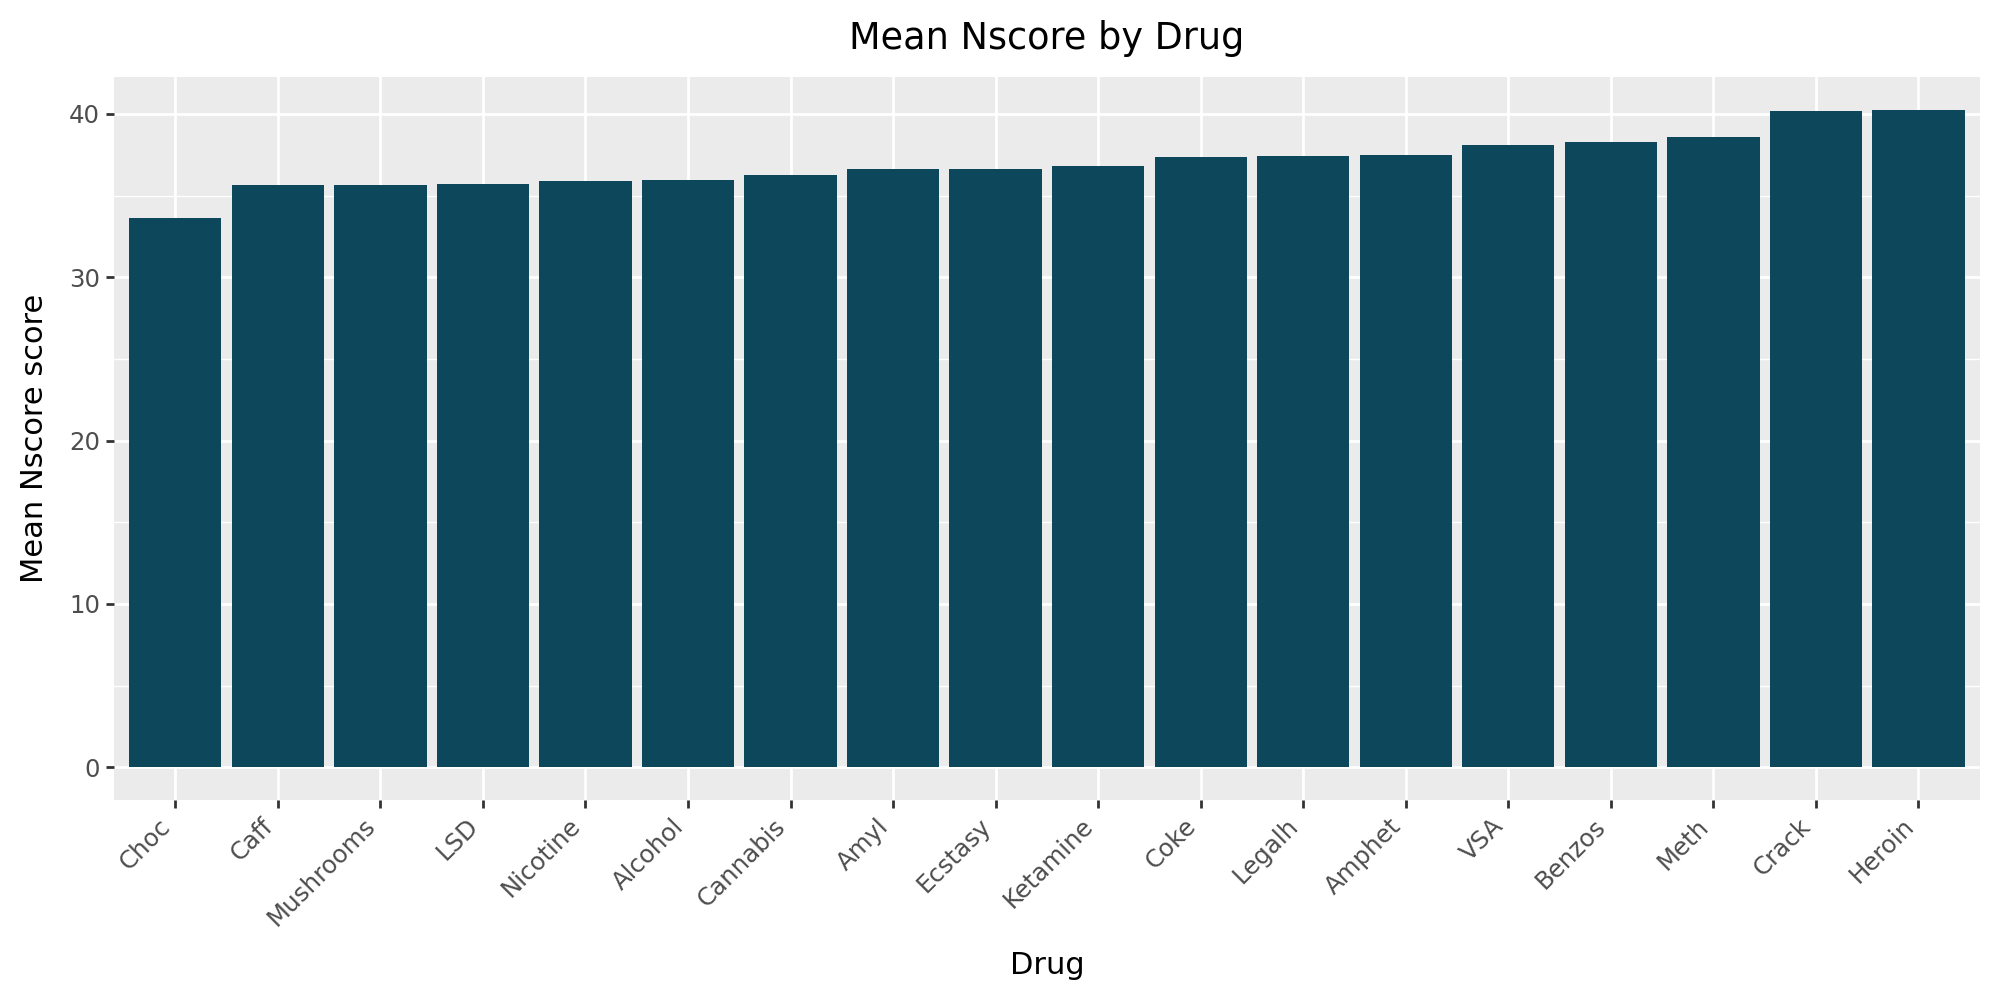

In [15]:
def plot_trait_by_drug(grouped_usage, trait):
    trait_means = (
        grouped_usage[grouped_usage["Trait"] == trait]
        .groupby("Drug", as_index=False)["Score"]
        .mean()
    )

    trait_means = trait_means.assign(
        Drug=pd.Categorical(
            trait_means["Drug"],
            categories=trait_means.sort_values("Score")["Drug"]
        )
    )

    return (
        pn.ggplot(trait_means, pn.aes("Drug", "Score"))
        + pn.geom_col(fill="#0C475B")
        + pn.labs(
            title=f"Mean {trait} by Drug",
            x="Drug",
            y=f"Mean {trait} score"
        )
        + pn.theme(
            figure_size=(10, 5),
            axis_text_x=pn.element_text(rotation=45, hjust=1)
        )
    )

# Example:
plot_trait_by_drug(grouped_usage, "Nscore")
#plot_trait_by_drug(grouped_usage, "Escore")

If we take chocolate and caffeine as a baseline, because almost all people eat chocolate and have tried coffe (excluding alcohol) then we see that maybe more neurotic people do illegal drugs. Let's now do a confidence test for this.

In [16]:
data2 = dataOG.copy()
data2 = data_reading.convert_drug_usage_classifiers(data2)  # map CL0..CL6 → 'Never Used', etc.
data2 = data_reading.convert_data(data2)

# 1) melt drugs to long
long_drugs = data2.melt(
    id_vars=data_reading.PERSONALITY_TRAITS,
    value_vars=data_reading.DRUG_TYPES,
    var_name="Drug",
    value_name="Classifier",
)



# 2) melt traits to long
trait_long = long_drugs.melt(
    id_vars=["Drug", "Classifier"],
    value_vars=data_reading.PERSONALITY_TRAITS,
    var_name="Trait",
    value_name="Score",
)

trait_long

,Drug,Classifier,Trait,Score
0,Alcohol,Used in Last Week,Nscore,39.0
1,Alcohol,Used in Last Week,Nscore,29.0
2,Alcohol,Used in Last Day,Nscore,31.0
3,Alcohol,Used in Last Month,Nscore,34.0
4,Alcohol,Used in Last Month,Nscore,43.0
...,...,...,...,...
237505,VSA,Used in Last Week,SS,11.0
237506,VSA,Never Used,SS,9.0
237507,VSA,Never Used,SS,5.0
237508,VSA,Never Used,SS,10.0


In [17]:
def plot_trait_boxplot(trait_long: pd.DataFrame, trait: str, users_only: bool = True):
    """
    Boxplot of a given personality trait by Drug.

    trait_long: output of make_trait_long
    trait: e.g. "Nscore", "Escore", "Impulsive", "SS"
    users_only: if True, exclude 'Never Used' rows
    """
    df = trait_long[trait_long["Trait"] == trait].copy()

    if users_only:
        df = df[df["Classifier"] != "Never Used"]

    # Order drugs by median trait score
    order = (
        df.groupby("Drug")["Score"]
        .median()
        .sort_values()
        .index
    )
    df["Drug"] = pd.Categorical(df["Drug"], categories=order, ordered=True)

    p = (
        pn.ggplot(df, pn.aes("Drug", "Score"))
        + pn.geom_boxplot()
        + pn.labs(
            title=f"{trait} distribution by drug ({'users only' if users_only else 'all respondents'})",
            x="Drug",
            y=f"{trait} score",
        )
        + pn.theme(
            figure_size=(10, 5),
            axis_text_x=pn.element_text(rotation=45, hjust=1),
        )
    )
    return p



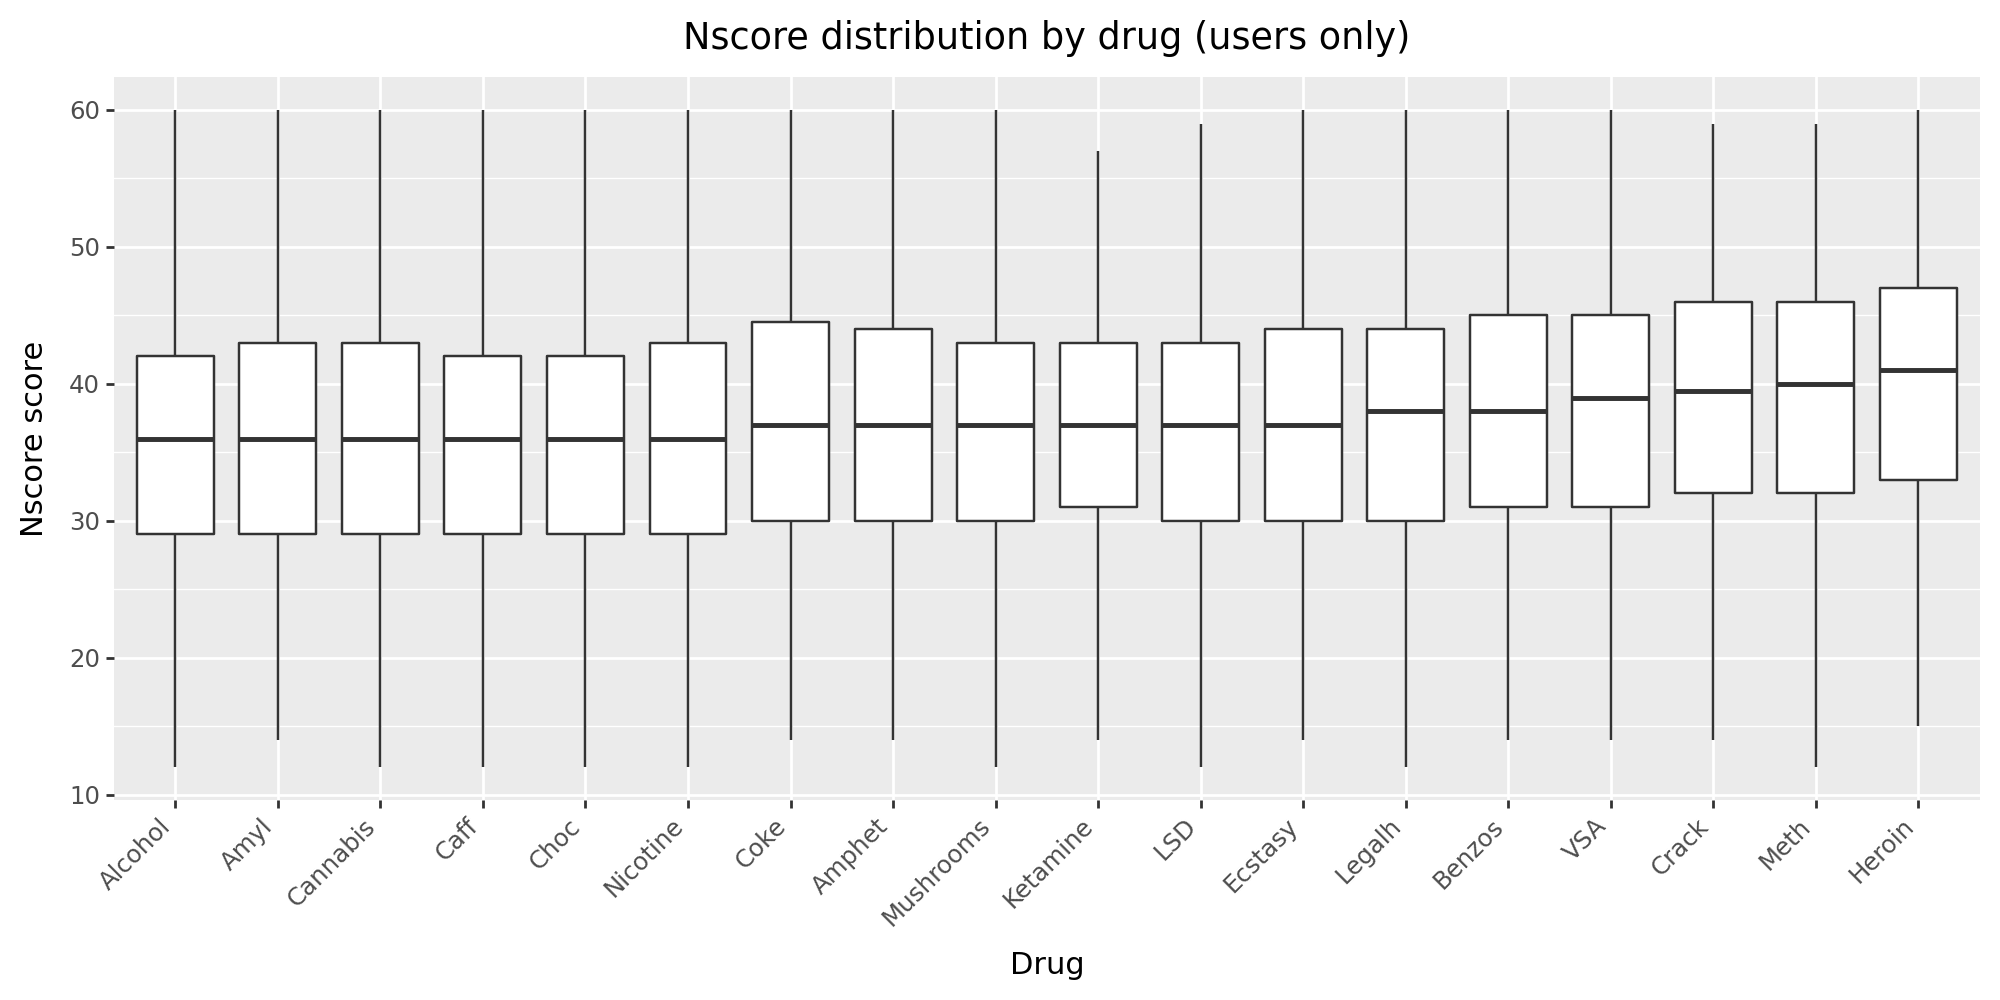

In [18]:
plot_trait_boxplot(trait_long, "Nscore", users_only=True)

In [19]:
def compute_trait_ci(trait_long: pd.DataFrame, trait: str, users_only: bool = True):
    """
    Compute mean and normal-approx 95% CI for a given trait by Drug.
    Returns a DataFrame with columns:
      Drug, Mean, SD, N, SE, CI_low, CI_high
    """
    df = trait_long[trait_long["Trait"] == trait].copy()

    if users_only:
        df = df[df["Classifier"] != "Never Used"]

    agg = (
        df.groupby("Drug", as_index=False)
        .agg(
            Mean=("Score", "mean"),
            SD=("Score", "std"),
            N=("Score", "size"),
        )
    )

    # standard error
    agg["SE"] = agg["SD"] / np.sqrt(agg["N"])

    # 95% CI using normal approximation (z = 1.96)
    z = 1.96
    agg["CI_low"] = agg["Mean"] - z * agg["SE"]
    agg["CI_high"] = agg["Mean"] + z * agg["SE"]

    return agg


def drugs_vs_choc_ci(
    trait_long: pd.DataFrame,
    trait: str = "Nscore",
    users_only: bool = True,
    reverese_calculations: bool = False,
) -> pd.DataFrame:
    """
    For a given trait, compute CI statistics for all drugs and compare to Chocolate.

    Adds two columns:
      - CI_gap_ChocHigh_minus_DrugLow 
      - SignificantlyHigherThanChoc
    """
    # CI stats for all drugs
    stats = compute_trait_ci(trait_long, trait, users_only=users_only).copy()

    # get Chocolate row
    choc = stats[stats["Drug"] == "Choc"]
    if choc.empty:
        raise ValueError("No Chocolate data found for this trait.")

    choc_ci_high = float(choc["CI_high"].iloc[0])
    choc_ci_low  = float(choc["CI_low"].iloc[0])


    if (not reverese_calculations):
        # CI gap: Chocolate upper bound minus each drug's lower bound
        stats["CI_gap_ChocHigh_minus_DrugLow"] = stats["CI_low"] - choc_ci_high
    
        # significance flag: drug CI fully above Chocolate CI
        stats["SignificantlyHigherThanChoc"] = stats["CI_low"] > choc_ci_high
    else:
        stats["CI_gap_ChocHigh_minus_DrugLow"] = choc_ci_low - stats["CI_high"]
        stats["SignificantlyLowerThanChoc"] = stats["CI_high"] < choc_ci_low


    return stats



def plot_trait_mean_ci(trait_long: pd.DataFrame, trait: str, users_only: bool = True):
    """
    Barplot of mean trait score by Drug with 95% CI, using compute_trait_ci().
    """

    # Re-use the central CI computation function
    agg = compute_trait_ci(trait_long, trait, users_only=users_only)

    # Order drugs by mean for nicer plotting
    order = agg.sort_values("Mean")["Drug"]
    agg["Drug"] = pd.Categorical(agg["Drug"], categories=order, ordered=True)

    p = (
        pn.ggplot(agg, pn.aes("Drug", "Mean"))
        + pn.geom_col(fill="#0C475B")
        + pn.geom_errorbar(
            pn.aes(ymin="CI_low", ymax="CI_high"),
            width=0.2
        )
        + pn.labs(
            title=f"Mean {trait} by drug with 95% CI "
                  f"({'users only' if users_only else 'all respondents'})",
            x="Drug",
            y=f"Mean {trait} score",
        )
        + pn.theme(
            figure_size=(10, 5),
            axis_text_x=pn.element_text(rotation=45, hjust=1),
        )
    )

    return p



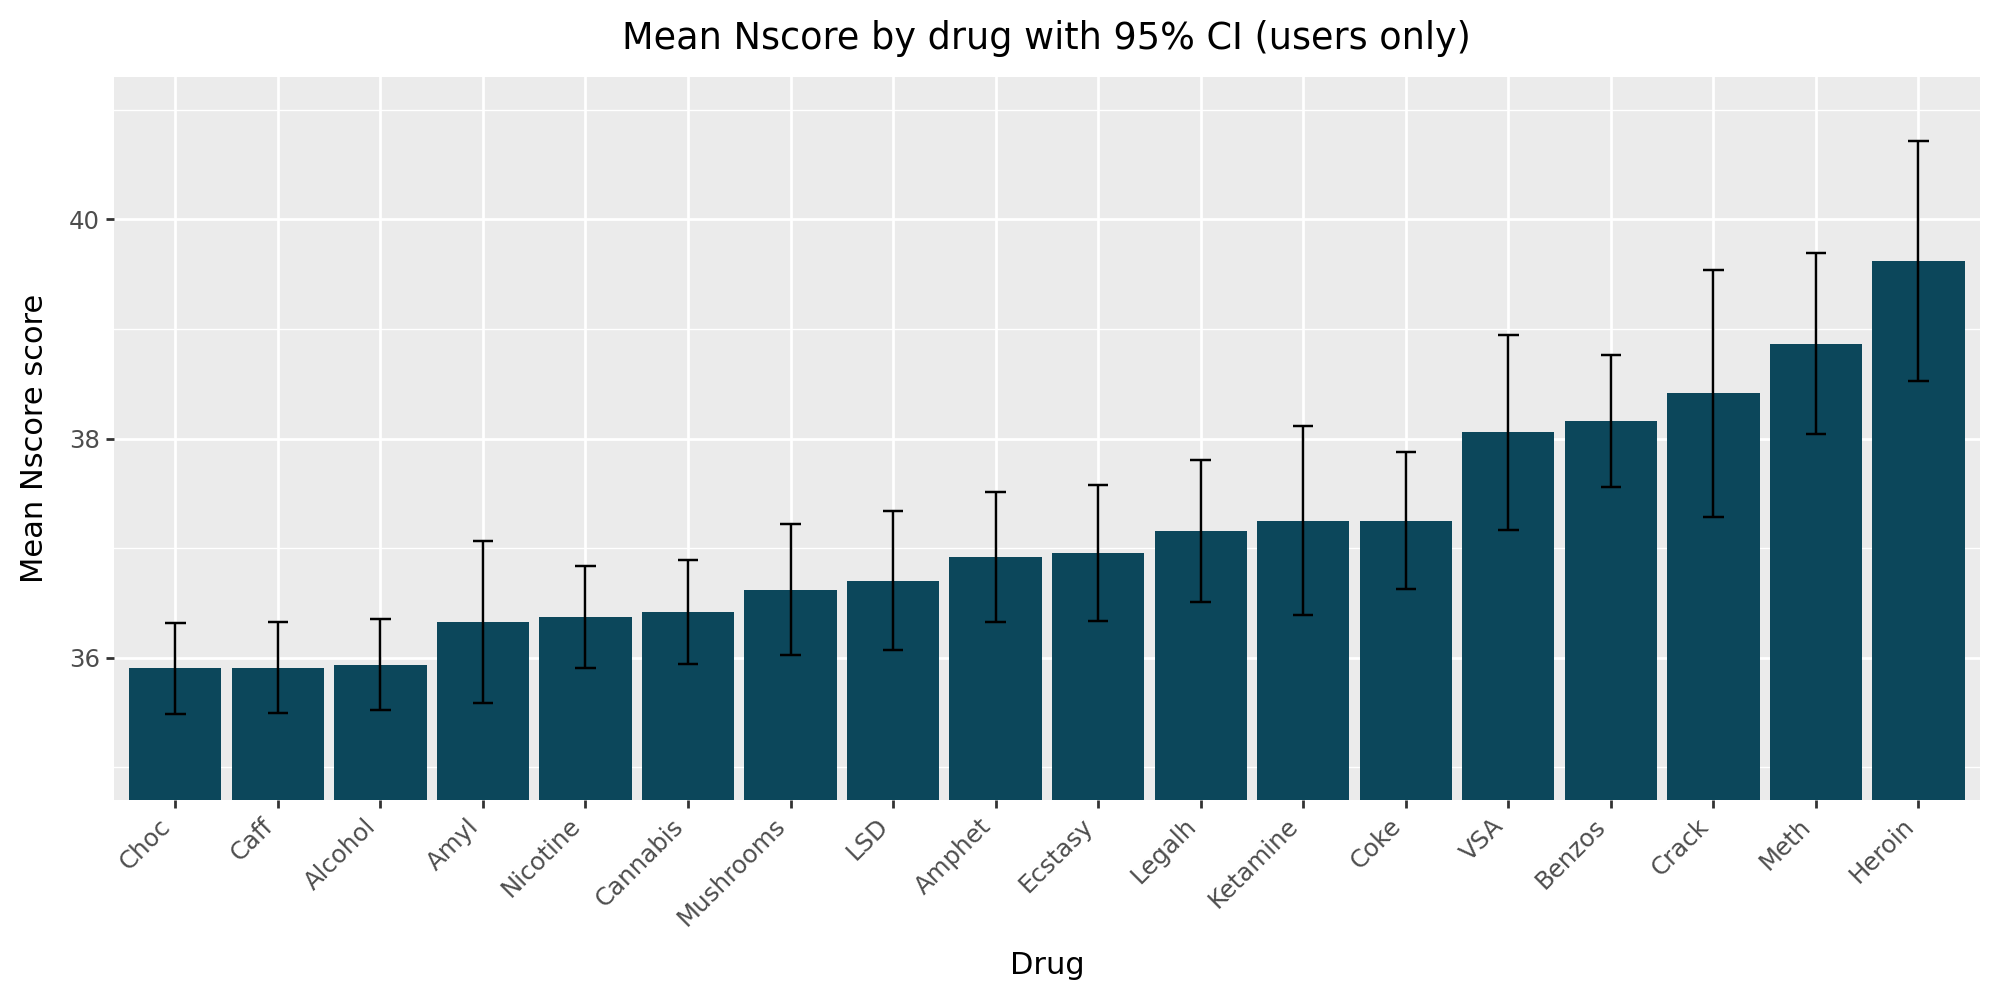

In [20]:
(
    plot_trait_mean_ci(trait_long, "Nscore", users_only=True)
    + pn.coord_cartesian(ylim=(35, 41))
)

In [21]:
stats_nscore = drugs_vs_choc_ci(trait_long, "Nscore", users_only=True)
stats_nscore.sort_values("Mean", ascending=False)

,Drug,Mean,SD,N,SE,CI_low,CI_high,CI_gap_ChocHigh_minus_DrugLow,SignificantlyHigherThanChoc
10,Heroin,39.625000,9.348226,280,0.558663,38.530020,40.719980,2.212526,True
14,Meth,38.866228,9.022419,456,0.422513,38.038102,39.694354,1.720608,True
8,Crack,38.414729,9.237595,258,0.575108,37.287518,39.541940,0.970024,True
3,Benzos,38.159322,9.098539,885,0.305844,37.559868,38.758776,1.242374,True
17,VSA,38.055814,9.378428,430,0.452268,37.169369,38.942259,0.851875,True
7,Coke,37.251476,9.317834,847,0.320165,36.623953,37.878998,0.306460,True
11,Ketamine,37.250633,8.757620,395,0.440644,36.386971,38.114295,0.069478,True
13,Legalh,37.159292,9.309443,791,0.331006,36.510521,37.808063,0.193027,True
9,Ecstasy,36.952546,9.291909,864,0.316117,36.332957,37.572136,0.015463,True
1,Amphet,36.918592,9.178358,909,0.304427,36.321915,37.515269,0.004422,True


As we can see, it is statistically significant that users of Heroin, Methamphetamine, Crack cocaine, Benzodiazepines, Volatile Substance Abuse, Cocaine, Ketamine, Legal highs, MDMA/Ecstasy, and Amphetamines are more neurotic.


In [22]:
print(data_reading.PERSONALITY_TRAITS)

['Nscore', 'Ascore', 'Oscore', 'Escore', 'Cscore', 'Impulsive', 'SS']


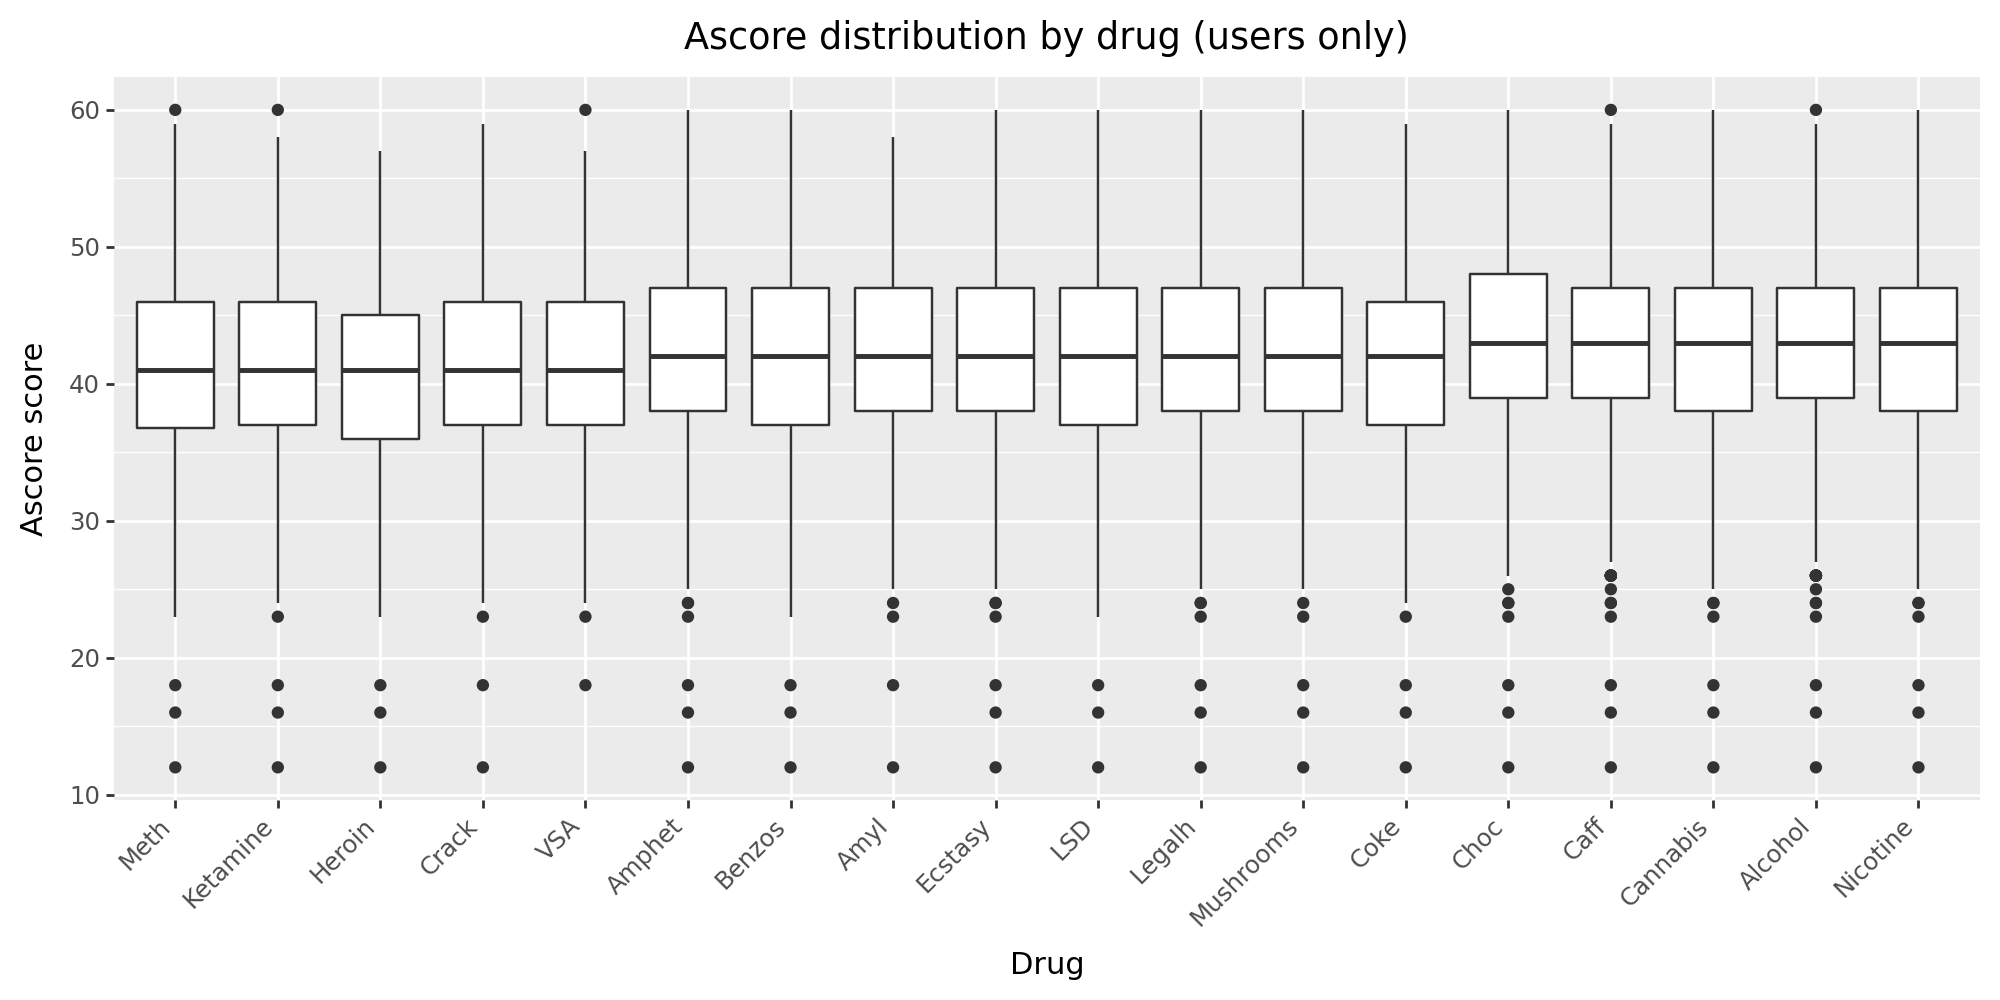

In [23]:

plot_trait_boxplot(trait_long, "Ascore", users_only=True)

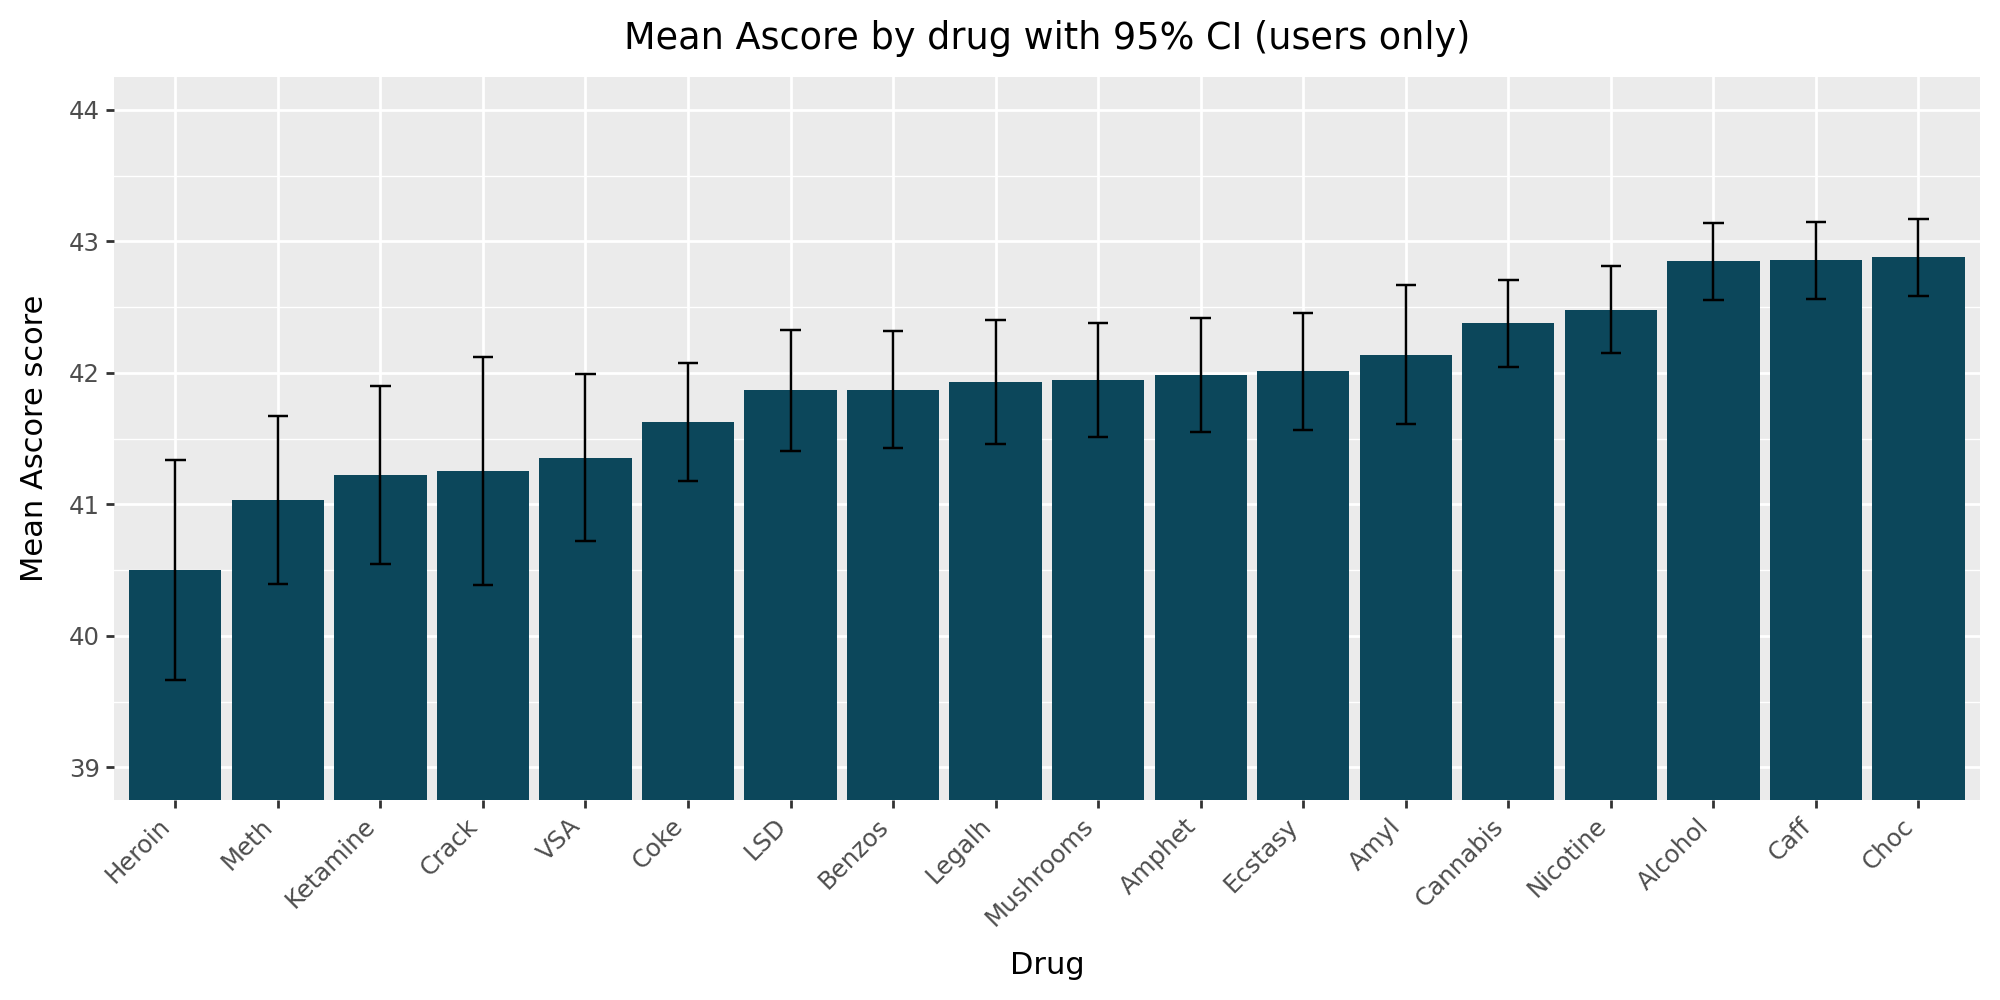

In [24]:
(
    plot_trait_mean_ci(trait_long, "Ascore", users_only=True)
    + pn.coord_cartesian(ylim=(39, 44))
)

In [25]:
stats_ascore = drugs_vs_choc_ci(trait_long, "Ascore", users_only=True, reverese_calculations=True)
stats_ascore.sort_values("Mean", ascending=False)

,Drug,Mean,SD,N,SE,CI_low,CI_high,CI_gap_ChocHigh_minus_DrugLow,SignificantlyLowerThanChoc
6,Choc,42.879115,6.414958,1853,0.149024,42.587028,43.171202,-0.584174,False
4,Caff,42.856835,6.429348,1858,0.149157,42.564487,43.149183,-0.562155,False
0,Alcohol,42.849811,6.432109,1851,0.149503,42.556785,43.142837,-0.555809,False
16,Nicotine,42.479067,6.433707,1457,0.168551,42.148706,42.809427,-0.222399,False
5,Cannabis,42.375679,6.488250,1472,0.169112,42.044220,42.707138,-0.120110,False
2,Amyl,42.139655,6.516843,580,0.270597,41.609285,42.670026,-0.082998,False
9,Ecstasy,42.010417,6.657392,864,0.226489,41.566498,42.454335,0.132693,True
1,Amphet,41.982398,6.632396,909,0.219983,41.551232,42.413564,0.173464,True
15,Mushrooms,41.946844,6.610769,903,0.219993,41.515658,42.378029,0.208999,True
13,Legalh,41.931732,6.802858,791,0.241882,41.457644,42.405820,0.181208,True


As we can see, it is statistically significant that, compared to chocolate users, people who use MDMA/Ecstasy, amphetamines, psilocybin mushrooms, legal highs, benzodiazepines, LSD, cocaine, volatile substances (VSA), crack cocaine, ketamine, methamphetamine, and heroin are less agreeable (have lower Ascore).

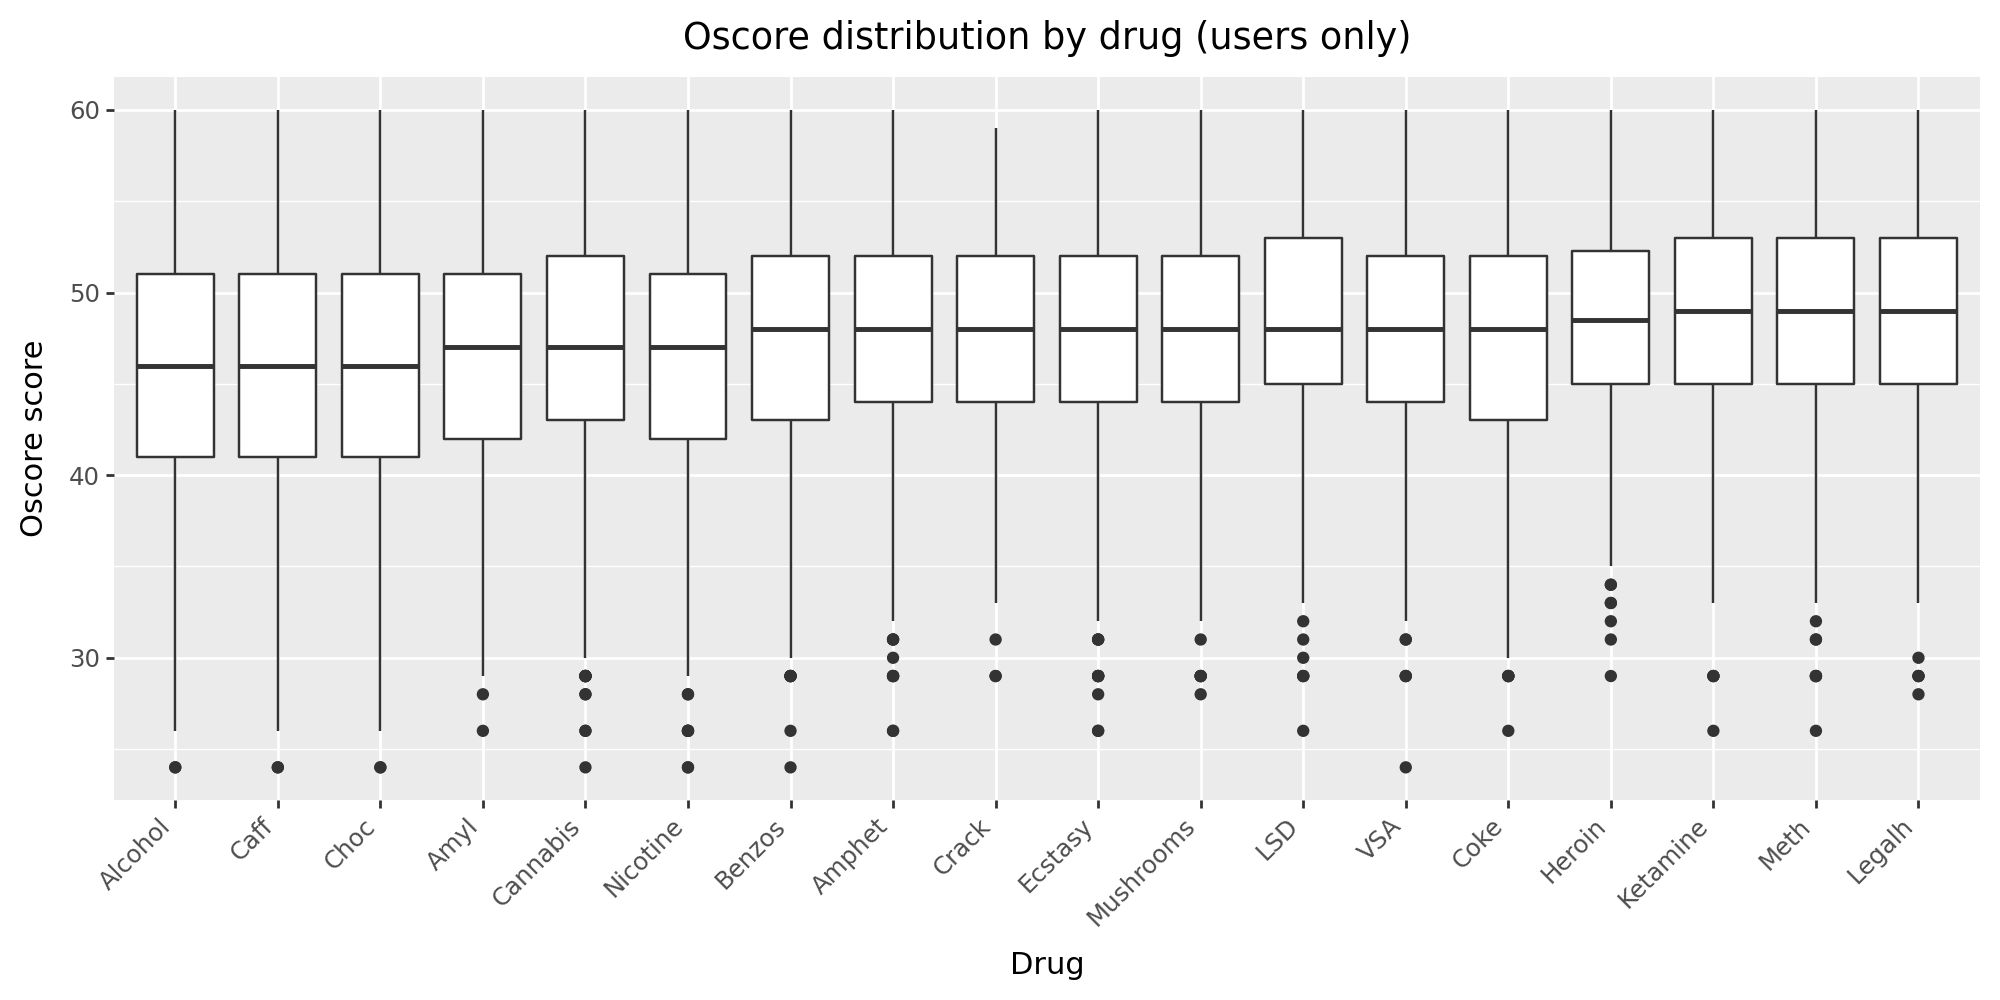

In [26]:
plot_trait_boxplot(trait_long, "Oscore", users_only=True)

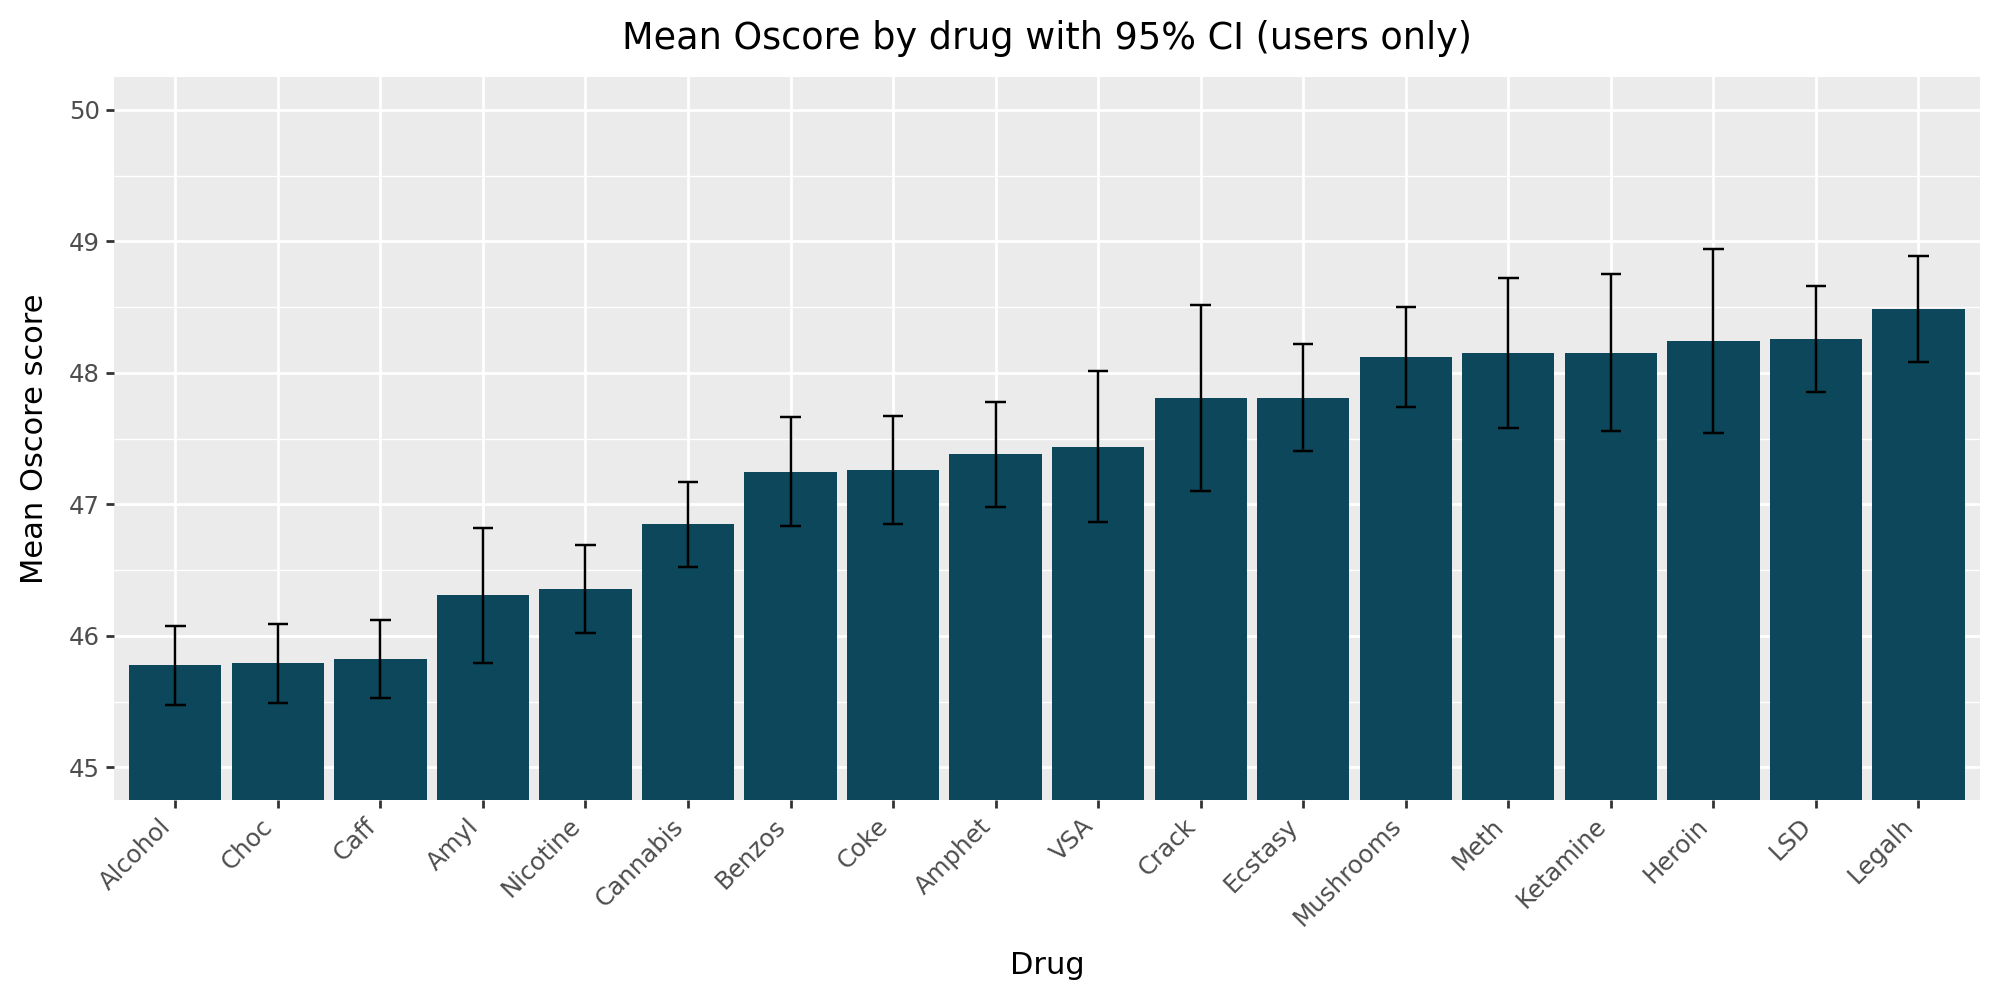

In [27]:
(
    plot_trait_mean_ci(trait_long, "Oscore", users_only=True)
    + pn.coord_cartesian(ylim=(45, 50))
)

In [28]:
stats_oscore = drugs_vs_choc_ci(trait_long, "Oscore", users_only=True, reverese_calculations=False)
stats_oscore.sort_values("Mean", ascending=False)

,Drug,Mean,SD,N,SE,CI_low,CI_high,CI_gap_ChocHigh_minus_DrugLow,SignificantlyHigherThanChoc
13,Legalh,48.485461,5.763216,791,0.204916,48.083825,48.887098,1.993634,True
12,LSD,48.256127,5.904295,816,0.206692,47.851012,48.661243,1.760820,True
10,Heroin,48.242857,5.968701,280,0.356698,47.543729,48.941985,1.453537,True
11,Ketamine,48.151899,6.056604,395,0.304741,47.554607,48.749191,1.464415,True
14,Meth,48.149123,6.216932,456,0.291135,47.578499,48.719746,1.488308,True
15,Mushrooms,48.121816,5.805285,903,0.193188,47.743168,48.500464,1.652977,True
9,Ecstasy,47.812500,6.141214,864,0.208928,47.403000,48.222000,1.312809,True
8,Crack,47.806202,5.786846,258,0.360273,47.100066,48.512337,1.009874,True
17,VSA,47.437209,6.072561,430,0.292845,46.863233,48.011185,0.773042,True
1,Amphet,47.380638,6.149594,909,0.203969,46.980858,47.780418,0.890667,True


As we can see, it is statistically significant that, compared to chocolate users, people who use legal highs, LSD, heroin, ketamine, methamphetamine, psilocybin mushrooms, MDMA/ecstasy, crack cocaine, volatile substances (VSA), amphetamines, cocaine, benzodiazepines, and cannabis have lower Openess (open to new experiences) scores than chocolate users.

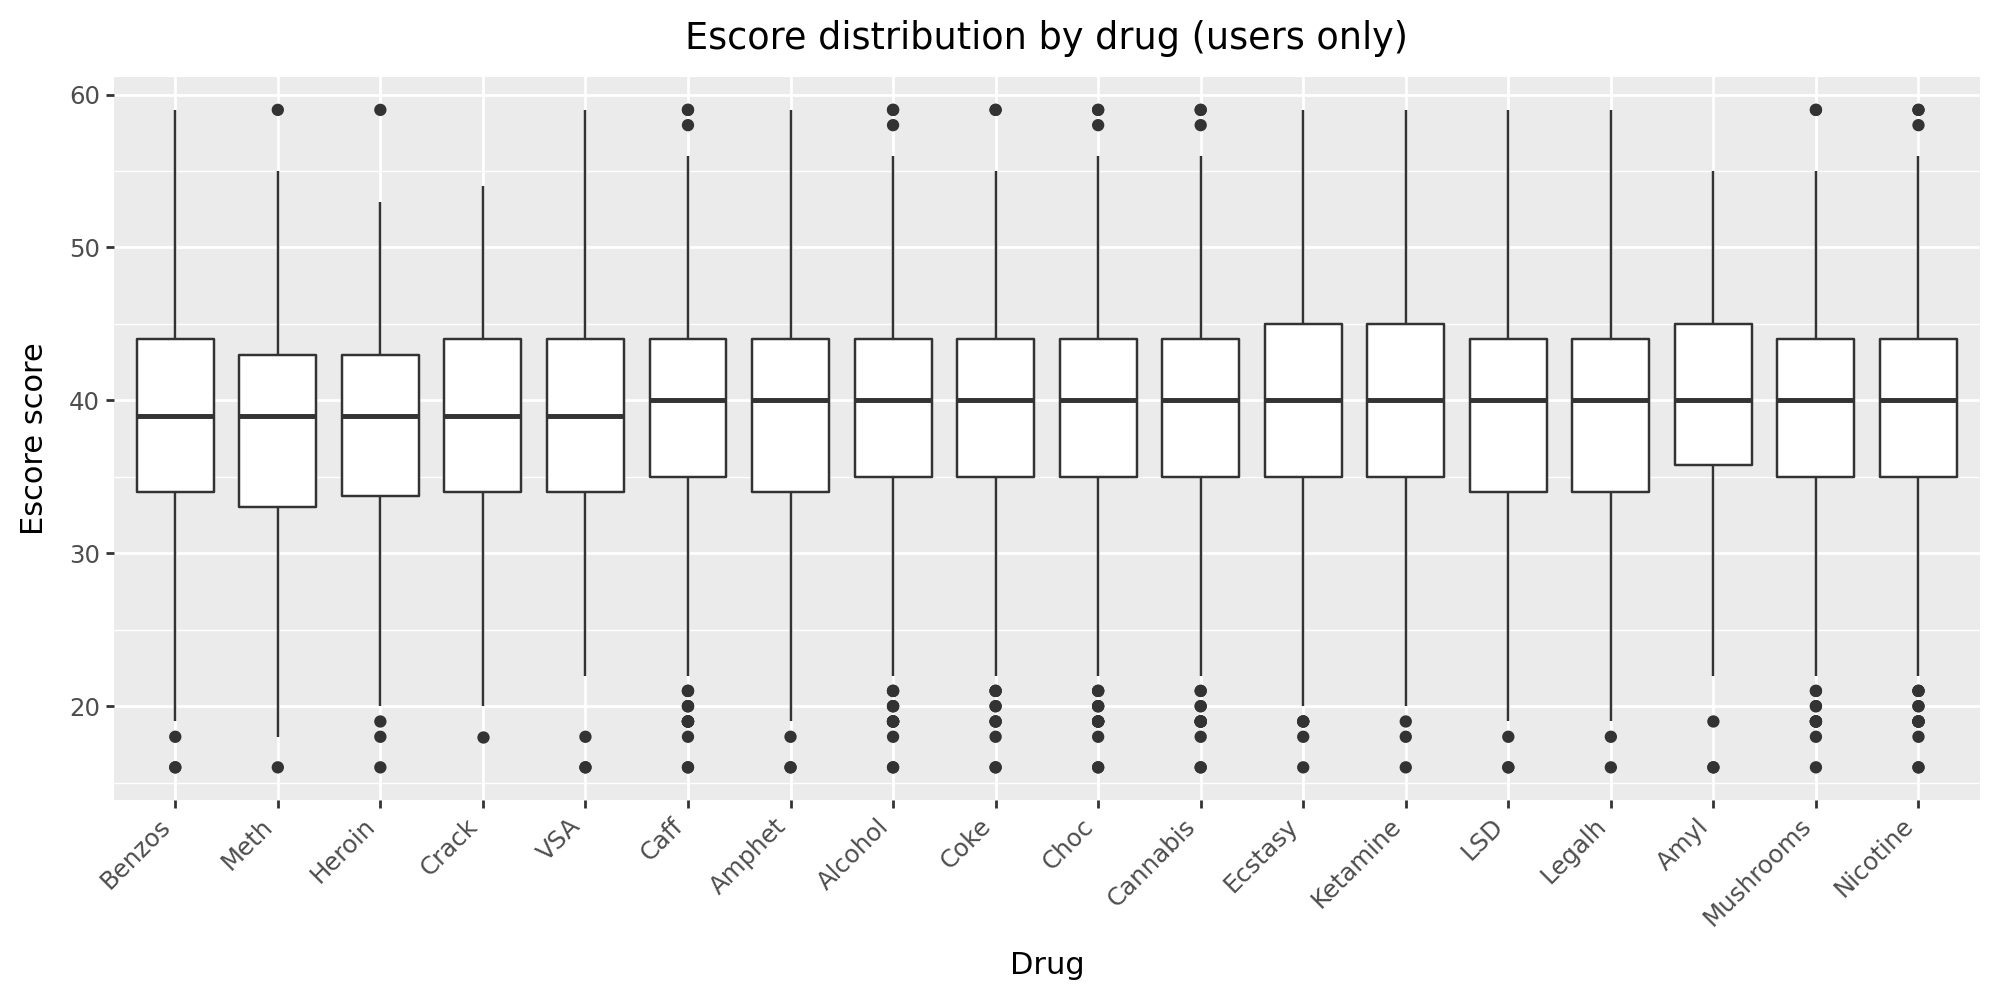

In [29]:
plot_trait_boxplot(trait_long, "Escore", users_only=True)

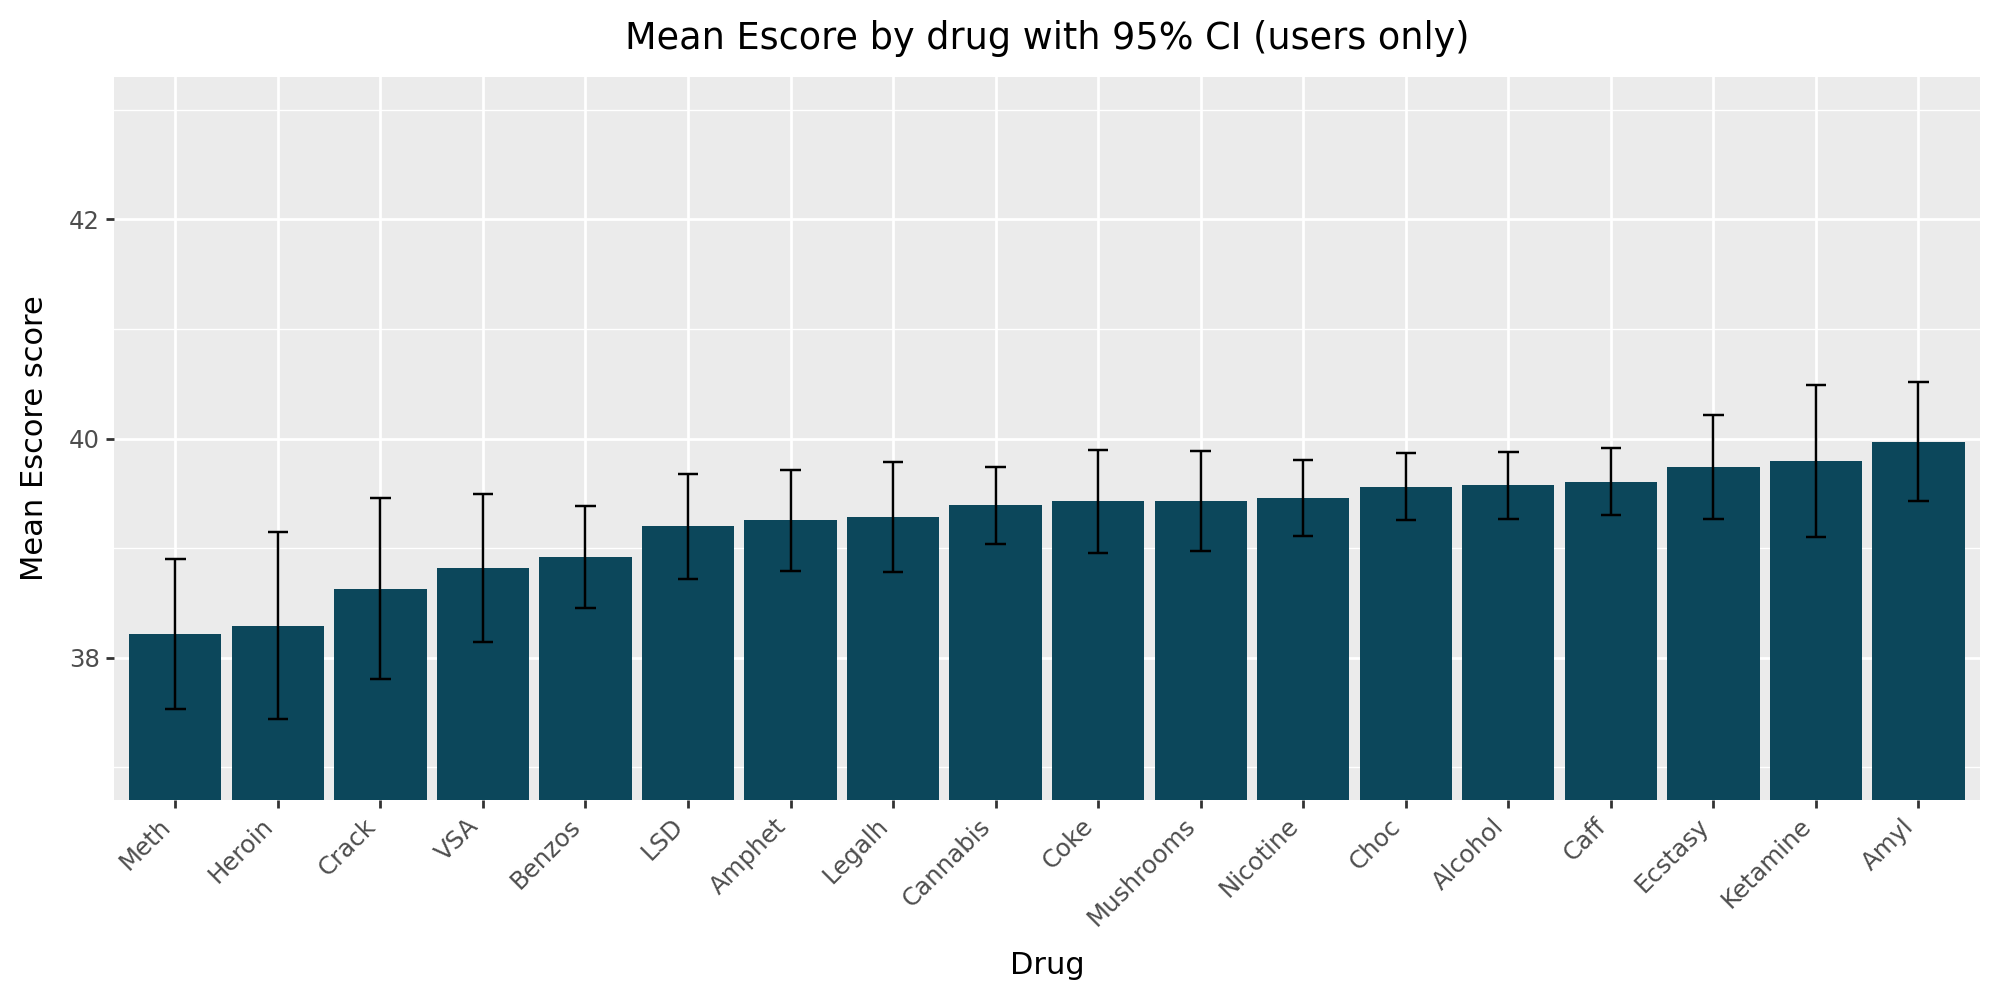

In [30]:
(
    plot_trait_mean_ci(trait_long, "Escore", users_only=True)
    + pn.coord_cartesian(ylim=(37, 43))
)

In [31]:
stats_escore = drugs_vs_choc_ci(trait_long, "Escore", users_only=True, reverese_calculations=True)
stats_escore.sort_values("Mean", ascending=False)

,Drug,Mean,SD,N,SE,CI_low,CI_high,CI_gap_ChocHigh_minus_DrugLow,SignificantlyLowerThanChoc
2,Amyl,39.972414,6.659957,580,0.276540,39.430396,40.514432,-1.260317,False
11,Ketamine,39.797468,7.041537,395,0.354298,39.103044,40.491893,-1.237778,False
9,Ecstasy,39.741898,7.136270,864,0.242781,39.266048,40.217749,-0.963634,False
4,Caff,39.606566,6.777541,1858,0.157235,39.298386,39.914747,-0.660632,False
0,Alcohol,39.572663,6.763934,1851,0.157216,39.264521,39.880806,-0.626691,False
6,Choc,39.562871,6.781053,1853,0.157529,39.254115,39.871627,-0.617512,False
16,Nicotine,39.457104,6.807880,1457,0.178354,39.107530,39.806677,-0.552562,False
15,Mushrooms,39.433001,7.029688,903,0.233933,38.974492,39.891511,-0.637396,False
7,Coke,39.428571,7.007040,847,0.240765,38.956673,39.900470,-0.646355,False
5,Cannabis,39.391984,6.905344,1472,0.179983,39.039217,39.744750,-0.490635,False


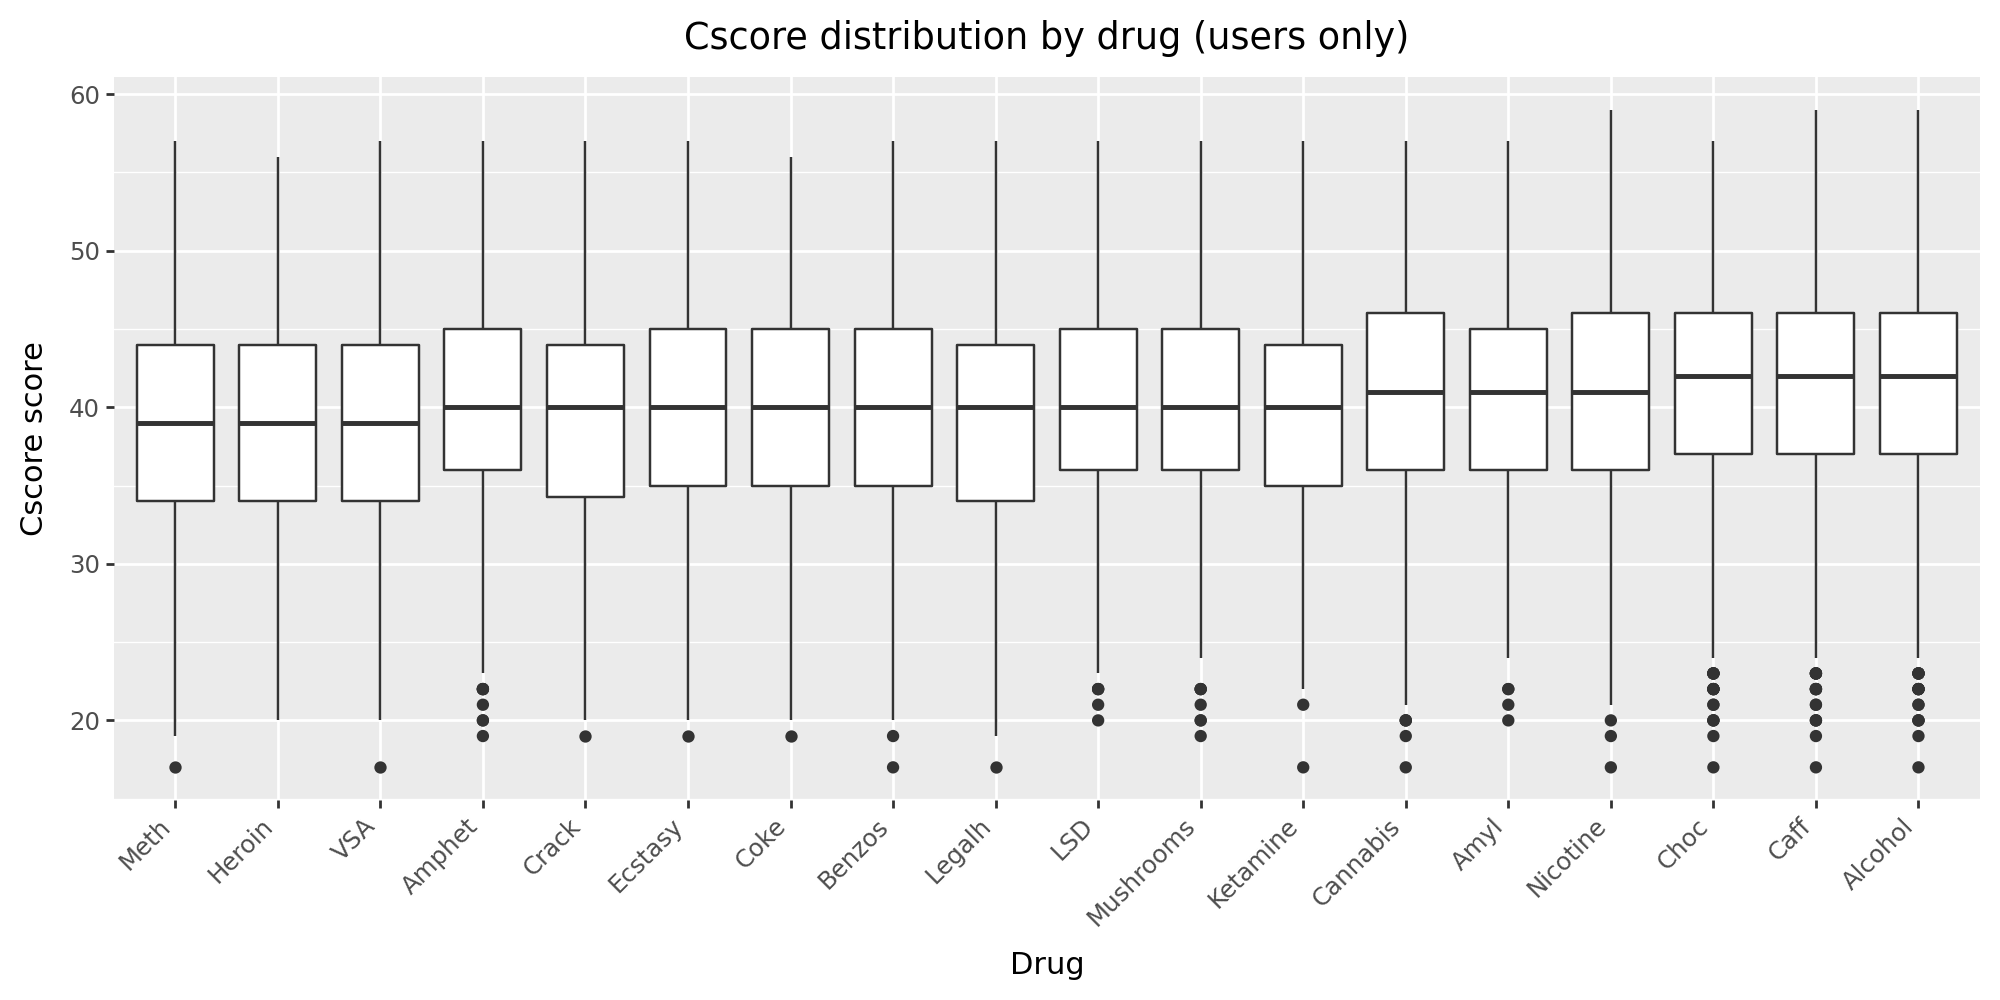

In [32]:
plot_trait_boxplot(trait_long, "Cscore", users_only=True)

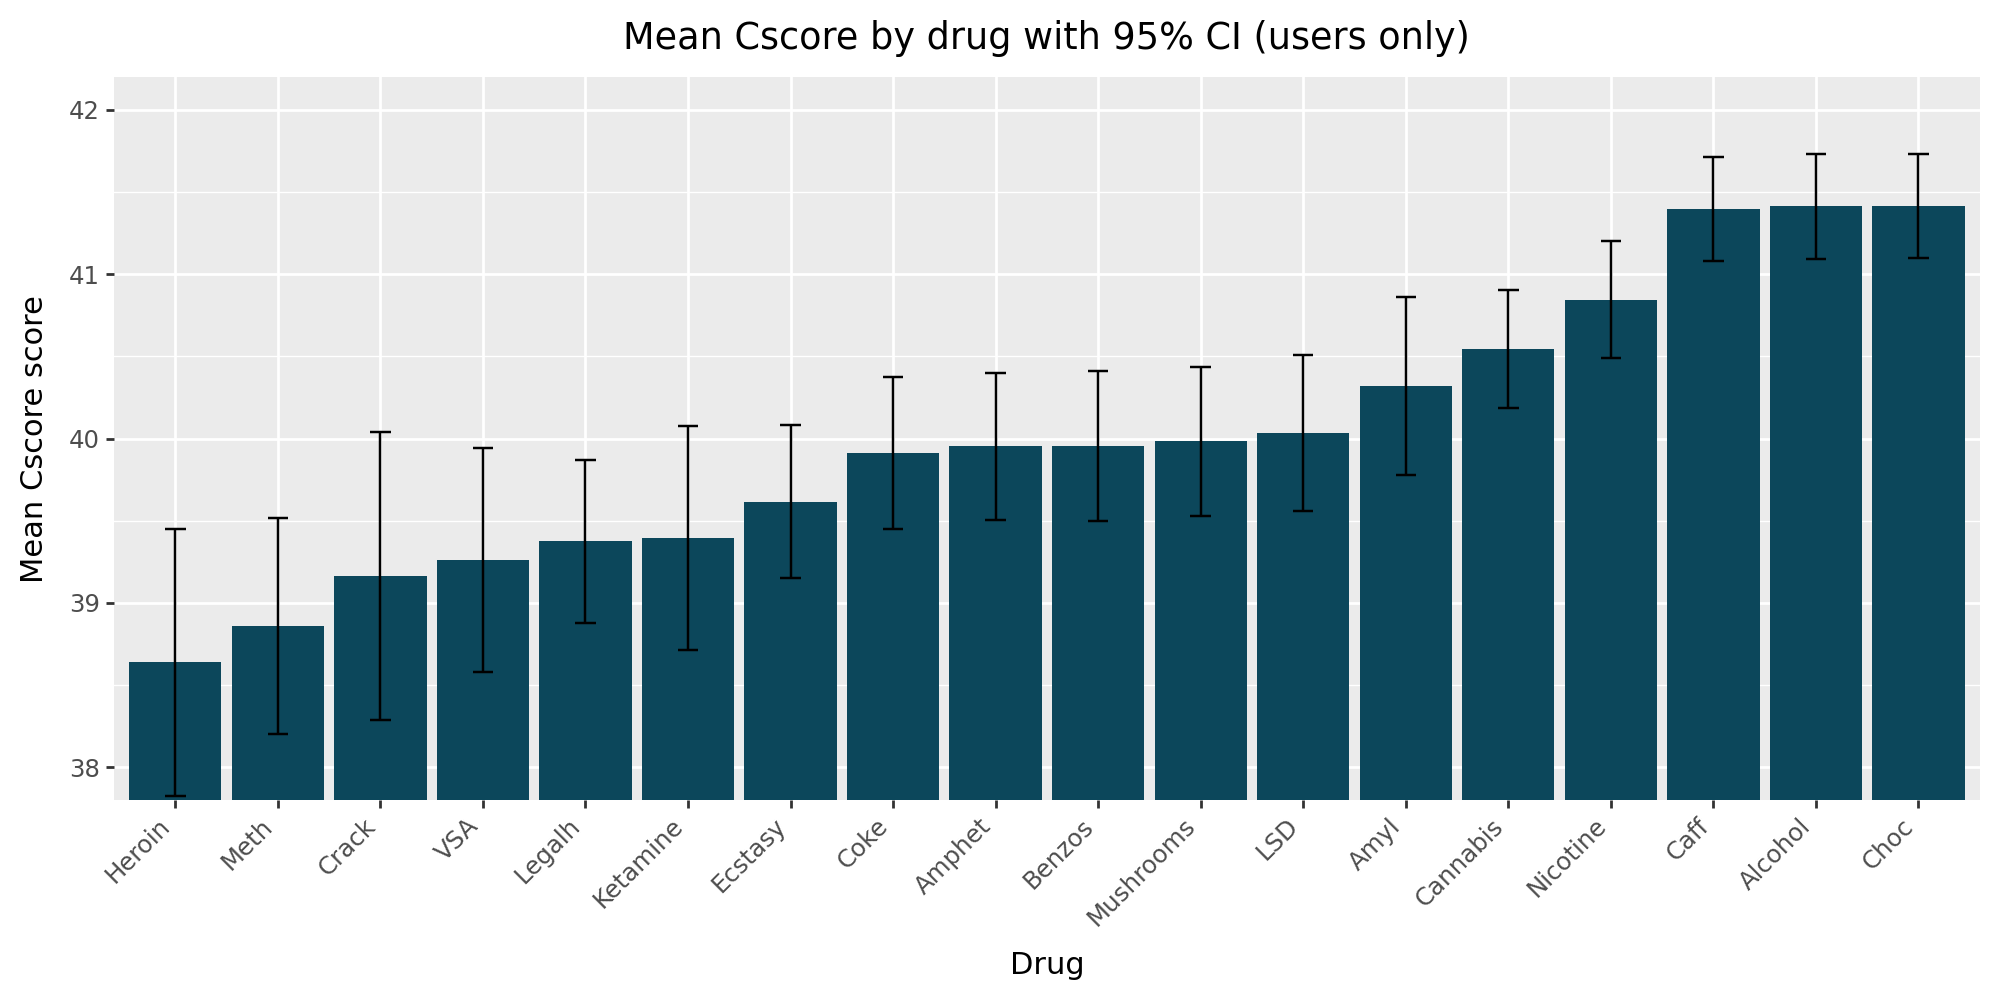

In [33]:
(
    plot_trait_mean_ci(trait_long, "Cscore", users_only=True)
    + pn.coord_cartesian(ylim=(38, 42))
)

In [34]:
stats_cscore = drugs_vs_choc_ci(trait_long, "Cscore", users_only=True, reverese_calculations=True)
stats_cscore.sort_values("Mean", ascending=False)

,Drug,Mean,SD,N,SE,CI_low,CI_high,CI_gap_ChocHigh_minus_DrugLow,SignificantlyLowerThanChoc
6,Choc,41.413384,6.959748,1853,0.161680,41.096491,41.730276,-0.633785,False
0,Alcohol,41.413290,6.970937,1851,0.162027,41.095717,41.730863,-0.634372,False
4,Caff,41.396663,6.967834,1858,0.161650,41.079830,41.713496,-0.617005,False
16,Nicotine,40.845573,6.971698,1457,0.182645,40.487588,41.203558,-0.107067,False
5,Cannabis,40.544837,7.026561,1472,0.183142,40.185878,40.903796,0.192695,True
2,Amyl,40.320690,6.632514,580,0.275400,39.780905,40.860474,0.236017,True
12,LSD,40.033088,6.891989,816,0.241268,39.560203,40.505973,0.590518,True
15,Mushrooms,39.984496,6.935543,903,0.230800,39.532127,40.436865,0.659626,True
3,Benzos,39.954802,6.958035,885,0.233892,39.496374,40.413230,0.683261,True
1,Amphet,39.953795,6.896821,909,0.228753,39.505439,40.402152,0.694340,True


As we can see, it is statistically significant that, compared to chocolate users, people who use cannabis, amyl nitrite, LSD, psilocybin mushrooms, benzodiazepines, amphetamines, cocaine, MDMA/ecstasy, ketamine, legal highs, volatile substances (VSA), crack cocaine, methamphetamine and heroin are less conscientious (have lower Cscore) (are less disciplined).

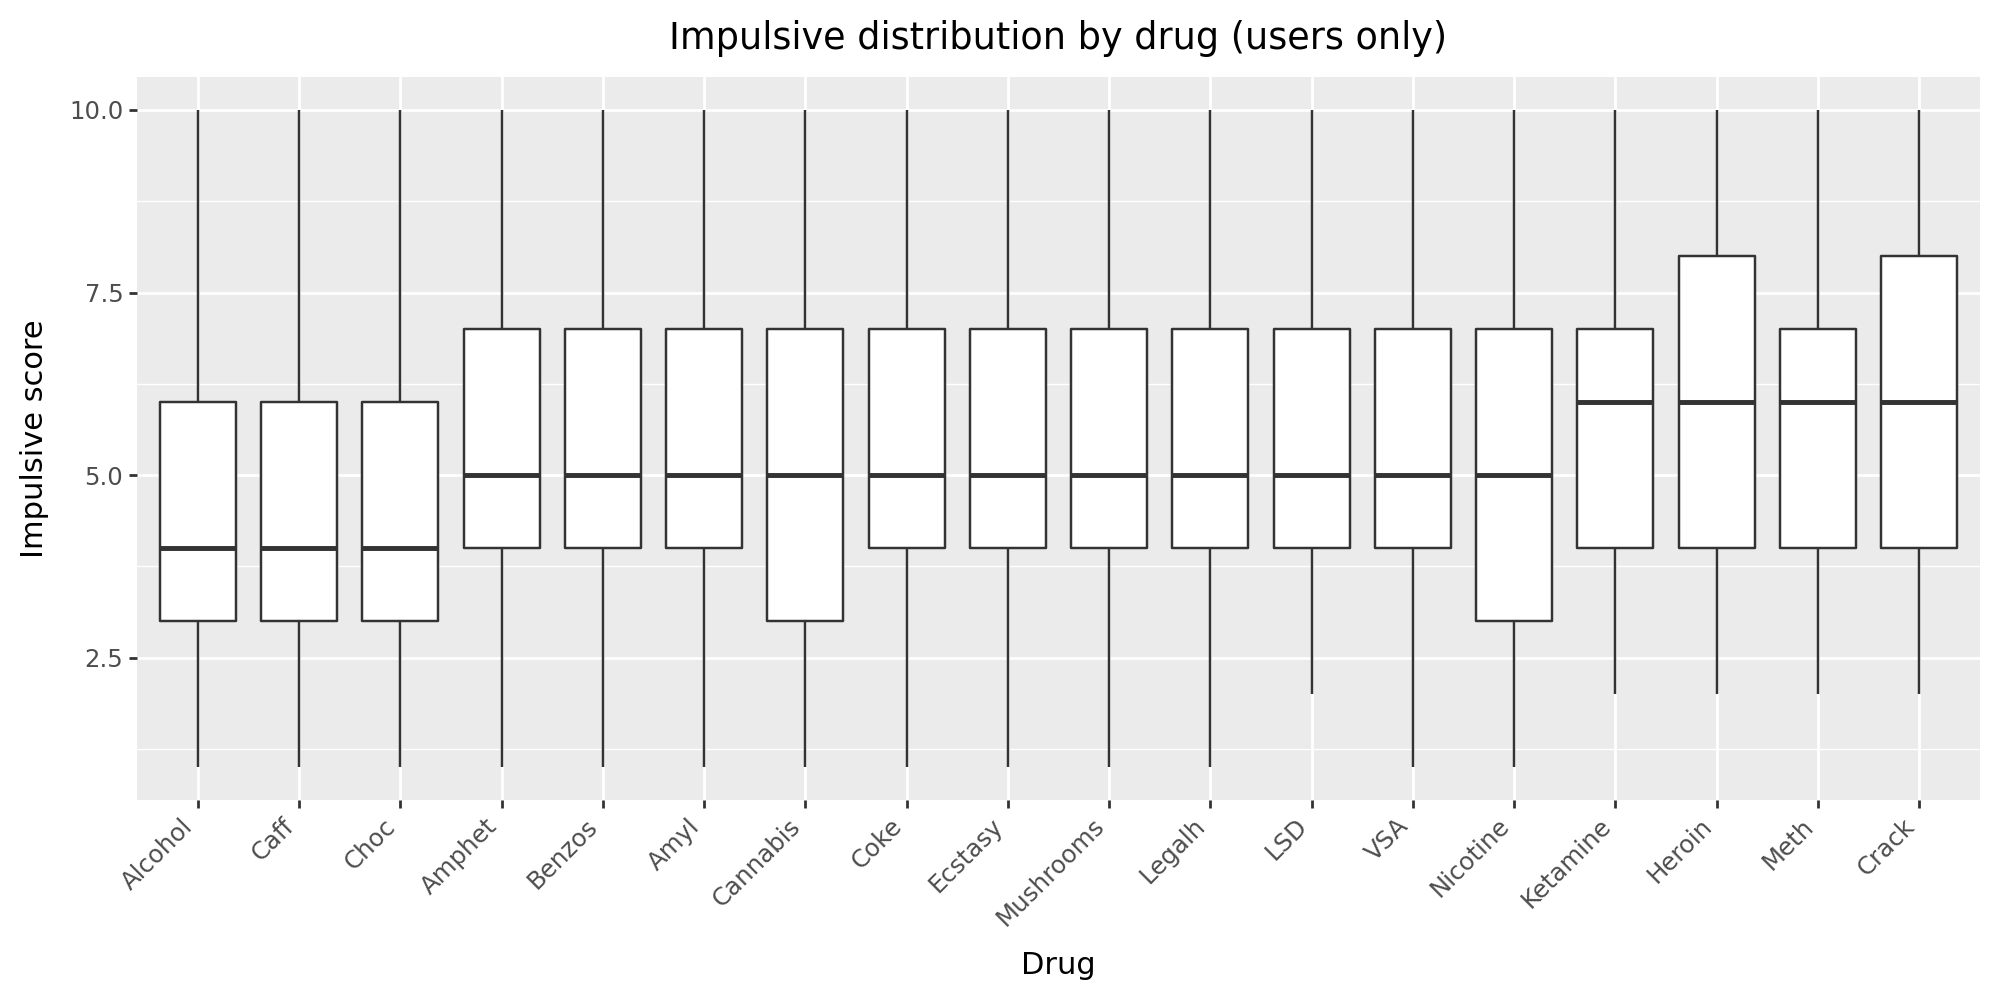

In [35]:
plot_trait_boxplot(trait_long, "Impulsive", users_only=True)

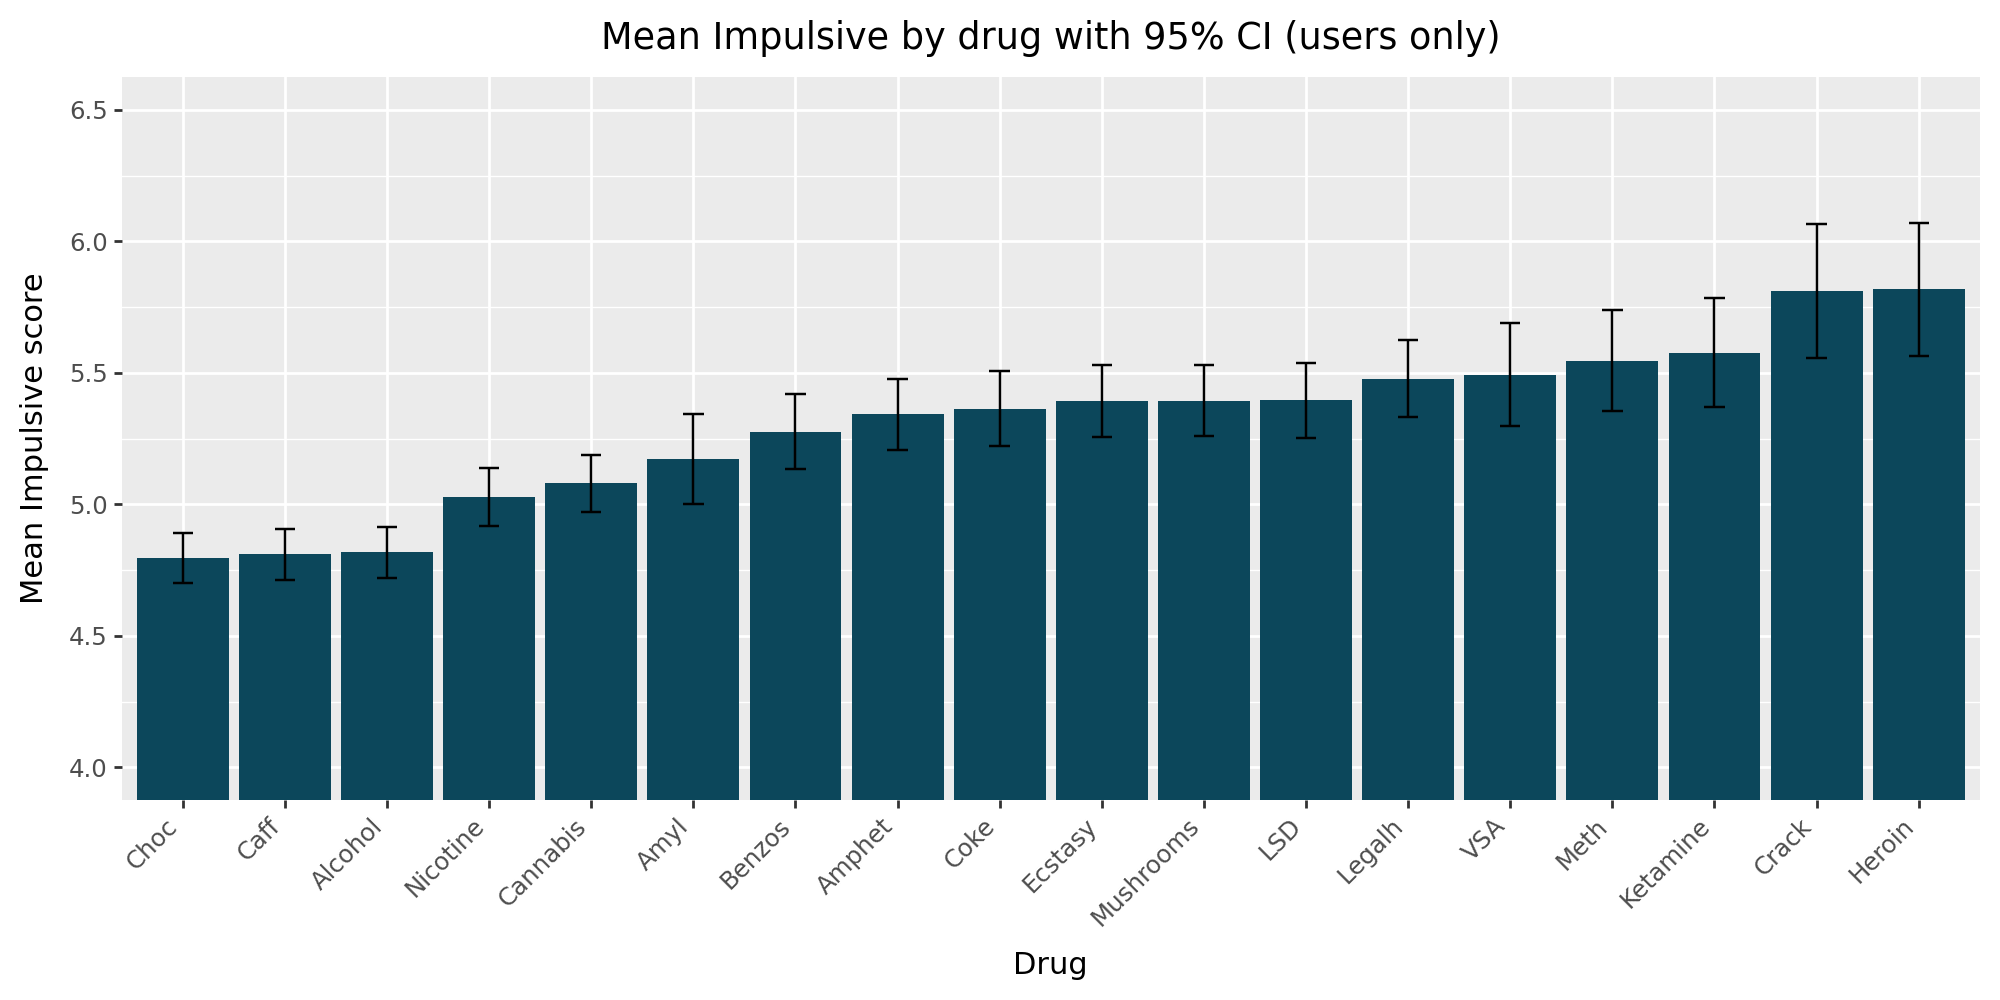

In [36]:
(
    plot_trait_mean_ci(trait_long, "Impulsive", users_only=True)
    + pn.coord_cartesian(ylim=(4, 6.5))
)

In [37]:
stats_impulsive_score = drugs_vs_choc_ci(trait_long, "Impulsive", users_only=True, reverese_calculations=False)
stats_impulsive_score.sort_values("Mean", ascending=False)

,Drug,Mean,SD,N,SE,CI_low,CI_high,CI_gap_ChocHigh_minus_DrugLow,SignificantlyHigherThanChoc
10,Heroin,5.817857,2.150028,280,0.128489,5.566019,6.069695,0.673466,True
8,Crack,5.810078,2.085426,258,0.129833,5.555605,6.064550,0.663051,True
11,Ketamine,5.577215,2.108958,395,0.106113,5.369233,5.785197,0.476680,True
14,Meth,5.546053,2.089762,456,0.097862,5.354243,5.737862,0.461689,True
17,VSA,5.493023,2.071833,430,0.099913,5.297194,5.688852,0.404641,True
13,Legalh,5.477876,2.087141,791,0.074210,5.332424,5.623328,0.439871,True
12,LSD,5.395833,2.064941,816,0.072287,5.254150,5.537517,0.361596,True
15,Mushrooms,5.394241,2.079264,903,0.069194,5.258622,5.529861,0.366068,True
9,Ecstasy,5.393519,2.072332,864,0.070502,5.255334,5.531703,0.362781,True
7,Coke,5.363636,2.125495,847,0.073033,5.220492,5.506781,0.327938,True


As we can see, it is statistically significant that, compared to chocolate users, people who use heroin, crack cocaine, ketamine, methamphetamine, volatile substances (VSA), legal highs, LSD, psilocybin mushrooms, MDMA/ecstasy, cocaine, amphetamines, benzodiazepines, amyl nitrite, cannabis, and nicotine are more impulsive (have higher impulsivity scores).

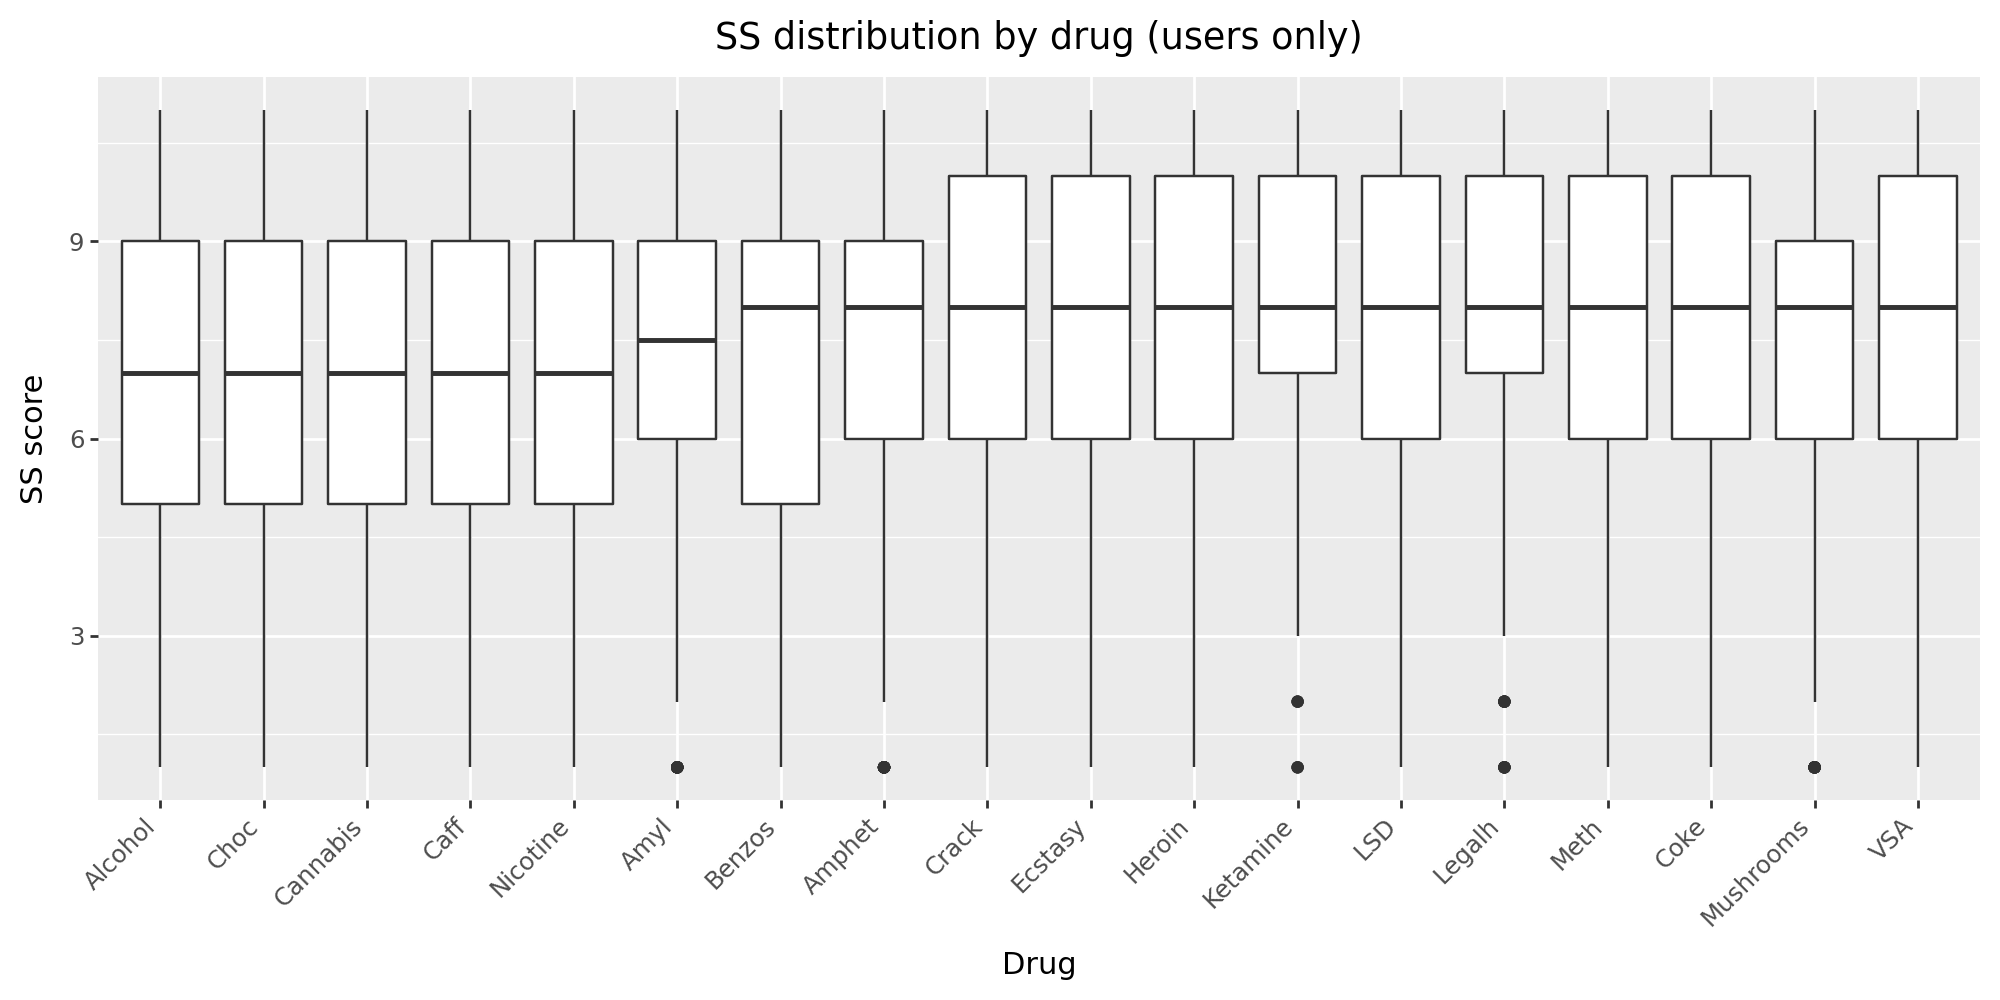

In [38]:
plot_trait_boxplot(trait_long, "SS", users_only=True)

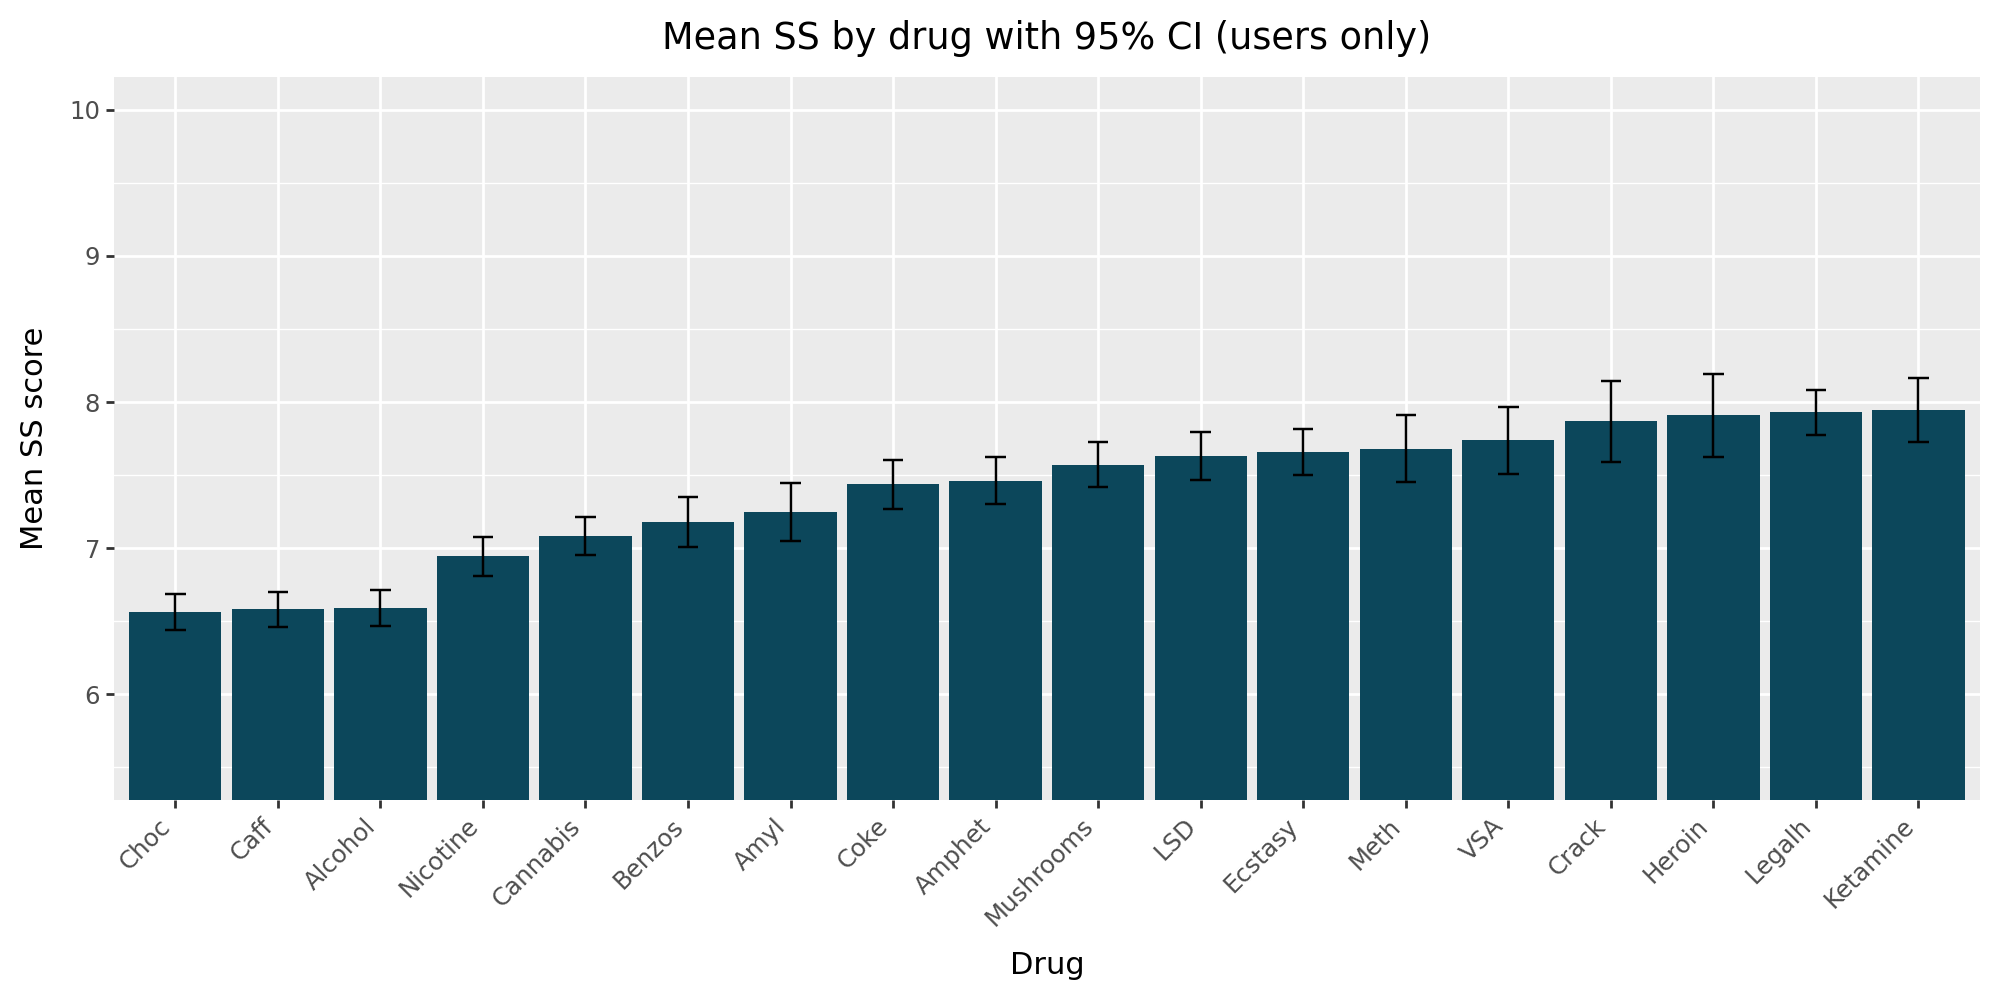

In [39]:
(
    plot_trait_mean_ci(trait_long, "SS", users_only=True)
    + pn.coord_cartesian(ylim=(5.5, 10))
)

In [40]:
stats_Sensation_score = drugs_vs_choc_ci(trait_long, "SS", users_only=True, reverese_calculations=False)
stats_Sensation_score.sort_values("Mean", ascending=False)

,Drug,Mean,SD,N,SE,CI_low,CI_high,CI_gap_ChocHigh_minus_DrugLow,SignificantlyHigherThanChoc
11,Ketamine,7.944304,2.206805,395,0.111036,7.726672,8.161935,1.042450,True
13,Legalh,7.929204,2.211030,791,0.078615,7.775118,8.083289,1.090895,True
10,Heroin,7.910714,2.432433,280,0.145366,7.625798,8.195631,0.941575,True
8,Crack,7.868217,2.269335,258,0.141283,7.591303,8.145131,0.907081,True
17,VSA,7.737209,2.417547,430,0.116584,7.508704,7.965715,0.824481,True
14,Meth,7.682018,2.489050,456,0.116560,7.453559,7.910476,0.769337,True
9,Ecstasy,7.656250,2.375255,864,0.080808,7.497867,7.814633,0.813644,True
12,LSD,7.628676,2.392342,816,0.083749,7.464529,7.792824,0.780306,True
15,Mushrooms,7.571429,2.342404,903,0.077950,7.418646,7.724211,0.734423,True
1,Amphet,7.463146,2.454883,909,0.081423,7.303557,7.622736,0.619334,True


As a large language model, yes, as we can see, it is statistically significant that, compared to chocolate users, people who use ketamine, legal highs, heroin, crack cocaine, volatile substances (VSA), methamphetamine, MDMA/ecstasy, LSD, psilocybin mushrooms, amphetamines, cocaine, amyl nitrite, benzodiazepines, cannabis, and nicotine have higher sensation scores (are more sensation-seeking).

Narkootikumide tarvitamine riigiti

In [41]:
# Temporarily here until I get the module fixed
def get_all_drug_usage_by_trait(data: pd.DataFrame, trait: str):
    selected_data = data[data_reading.DRUG_TYPES + [trait]]

    output_data = pd.DataFrame(columns=["Trait", "Drug", "Classifier", "Amount"])
    for drug_type in data_reading.DRUG_TYPES:
        single_drug_grouping = selected_data[[trait, drug_type]]
        
        single_drug_grouping = single_drug_grouping.groupby([trait, drug_type]).size().reset_index(name="Users")
        single_drug_grouping["Drug"] = drug_type
        single_drug_grouping = single_drug_grouping.rename(columns={drug_type: "Classifier"})
        output_data = pd.concat((output_data, single_drug_grouping))
    
    return output_data


data_analysis.get_all_drug_usage_by_trait(human_readable_data, "Gender")

,Gender,Drug,Classifier,Users
0,Female,Alcohol,Never Used,13
1,Female,Alcohol,Used in Last Day,207
2,Female,Alcohol,Used in Last Decade,28
3,Female,Alcohol,Used in Last Month,122
4,Female,Alcohol,Used in Last Week,370
...,...,...,...,...
9,Male,VSA,Used in Last Decade,77
10,Male,VSA,Used in Last Month,6
11,Male,VSA,Used in Last Week,7
12,Male,VSA,Used in Last Year,28


In [42]:
from data_reading import DRUG_TYPES
from scipy.stats import ttest_ind, chi2_contingency

In [43]:
def compute_trait_country_ci(df: pd.DataFrame, trait: str, countries=("UK", "USA")):
    """
    Compute mean, SD, SE and 95% CI for a given trait by Country.
    Returns a DataFrame with:
      Trait, Country, Mean, SD, N, SE, CI_low, CI_high
    """
    df = df[df["Country"].isin(countries)].copy()

    rows = []
    for country in countries:
        s = df.loc[df["Country"] == country, trait].dropna()
        if s.empty:
            continue

        mean = s.mean()
        sd = s.std()
        n = s.size
        se = sd / np.sqrt(n)
        z = 1.96
        ci_low = mean - z * se
        ci_high = mean + z * se

        rows.append(
            {
                "Trait": trait,
                "Country": country,
                "Mean": mean,
                "SD": sd,
                "N": n,
                "SE": se,
                "CI_low": ci_low,
                "CI_high": ci_high,
            }
        )

    return pd.DataFrame(rows)


def test_trait_country_diff(df: pd.DataFrame, trait: str, countries=("UK", "USA")):
    """
    Welch t-test for given trait: Country[0] vs Country[1].
    Returns (t_stat, p_value, significant_bool).
    """
    g1 = df.loc[df["Country"] == countries[0], trait].dropna()
    g2 = df.loc[df["Country"] == countries[1], trait].dropna()

    if g1.empty or g2.empty:
        return np.nan, np.nan, False

    t_stat, p_val = ttest_ind(g1, g2, equal_var=False)
    return t_stat, p_val, bool(p_val < 0.05)


def compute_all_traits_country_ci(
    df: pd.DataFrame,
    traits=None,
    countries=("UK", "USA"),
):
    """
    For all traits, compute mean, SD, SE, 95% CI by Country,
    plus Welch t-test p-value and significance per trait.
    Returns one long DataFrame for a single combined plot.
    """
    if traits is None:
        traits = PERSONALITY_TRAITS

    all_stats = []
    all_tests = []

    for trait in traits:
        stats_trait = compute_trait_country_ci(df, trait, countries=countries)
        all_stats.append(stats_trait)

        _, p_val, sig = test_trait_country_diff(df, trait, countries=countries)
        all_tests.append(
            {
                "Trait": trait,
                "p_value": p_val,
                "Significant_p<0.05": sig,
            }
        )

    stats_all = pd.concat(all_stats, ignore_index=True)
    tests_all = pd.DataFrame(all_tests)

    stats_all = stats_all.merge(tests_all, on="Trait", how="left")

    # Stable order on x-axis
    stats_all["Trait"] = pd.Categorical(
        stats_all["Trait"], categories=list(traits), ordered=True
    )

    return stats_all



In [44]:
from scipy.stats import chi2_contingency

def compute_drug_usage_country_ci(df: pd.DataFrame, drug: str, countries=("UK", "USA")):
    """
    For a given drug, compute proportion 'ever used' (vs never) by Country,
    plus SD, SE and normal-approx 95% CI.
    """
    df = df[df["Country"].isin(countries)].copy()
    df["EverUsed"] = (df[drug] != "Never Used").astype(int)

    rows = []
    for country in countries:
        s = df.loc[df["Country"] == country, "EverUsed"].dropna()
        if s.empty:
            continue

        mean = s.mean()  # proportion ever used
        sd = s.std()
        n = s.size
        se = sd / np.sqrt(n)
        z = 1.96
        ci_low = mean - z * se
        ci_high = mean + z * se

        rows.append(
            {
                "Drug": drug,
                "Country": country,
                "Mean": mean,
                "SD": sd,
                "N": n,
                "SE": se,
                "CI_low": ci_low,
                "CI_high": ci_high,
            }
        )

    return pd.DataFrame(rows)


def test_drug_usage_country_diff(df: pd.DataFrame, drug: str, countries=("UK", "USA")):
    """
    Chi-square test of independence for EverUsed vs Country.
    Returns (chi2, p_value, significant_bool).
    """
    df = df[df["Country"].isin(countries)].copy()
    df["EverUsed"] = (df[drug] != "Never Used").astype(int)

    table = []
    for country in countries:
        sub = df[df["Country"] == country]
        used = int((sub["EverUsed"] == 1).sum())
        never = int((sub["EverUsed"] == 0).sum())
        table.append([used, never])

    chi2, p, dof, expected = chi2_contingency(table)
    return chi2, p, bool(p < 0.05)


def plot_drug_usage_country(
    df: pd.DataFrame,
    drug: str,
    countries=("UK", "USA"),
    ref_country="UK",
):
    """
    Barplot of 'ever used' proportion for a drug by Country,
    with 95% CI, ±2 SD band of ref_country, and chi-square significance star.
    """

    stats = compute_drug_usage_country_ci(df, drug, countries=countries)
    if stats.empty:
        raise ValueError("No data for given drug/countries.")

    # Reference ±2 SD band (based on 0/1 EverUsed coding)
    ref_row = stats[stats["Country"] == ref_country]
    if ref_row.empty:
        raise ValueError(f"Reference country {ref_country} not found in data.")
    ref_row = ref_row.iloc[0]
    band_low = ref_row["Mean"] - 2 * ref_row["SD"]
    band_high = ref_row["Mean"] + 2 * ref_row["SD"]

    _, p_val, significant = test_drug_usage_country_diff(df, drug, countries=countries)

    y_star = stats["CI_high"].max() + 0.05
    sig_df = pd.DataFrame(
        {
            "x": [1.5],
            "y": [y_star],
            "label": ["*" if significant else ""],
        }
    )

    p = (
        pn.ggplot(stats, pn.aes("Country", "Mean"))
        + pn.geom_col(fill="#0C475B")
        + pn.geom_errorbar(pn.aes(ymin="CI_low", ymax="CI_high"), width=0.2)
        + pn.geom_hline(yintercept=band_low, linetype="dashed", color="#D55E00")
        + pn.geom_hline(yintercept=band_high, linetype="dashed", color="#D55E00")
        + pn.geom_text(
            pn.aes(x="x", y="y", label="label"),
            data=sig_df,
            inherit_aes=False,
            size=18,
        )
        + pn.scale_y_continuous(labels=lambda v: [f"{vv:.0%}" for vv in v])
        + pn.labs(
            title=(
                f"{drug}: ever used in UK vs USA "
                f"(95% CI, ±2 SD of {ref_country}; p = {p_val:.3f})"
            ),
            x="Country",
            y="Proportion ever used",
        )
        + pn.theme(
            figure_size=(6, 4),
            axis_text_x=pn.element_text(rotation=0),
        )
    )

    return p



In [45]:
def compute_all_drug_usage_country_ci(
    df: pd.DataFrame,
    drugs=None,
    countries=("UK", "USA"),
):
    """
    For all drugs, compute 'ever used' proportion stats by Country,
    plus chi-square p-value and significance flag per drug.
    Returns one long DataFrame suitable for a single combined plot.
    """
    if drugs is None:
        drugs = data_reading.DRUG_TYPES

    all_stats = []
    all_tests = []

    for drug in drugs:
        # reuse your per-drug summary function
        stats = compute_drug_usage_country_ci(df, drug, countries=countries)
        all_stats.append(stats)

        # reuse your chi-square significance test
        chi2, p_val, sig = test_drug_usage_country_diff(df, drug, countries=countries)
        all_tests.append(
            {
                "Drug": drug,
                "p_value": p_val,
                "Significant_p<0.05": sig,
            }
        )

    stats_all = pd.concat(all_stats, ignore_index=True)
    tests_all = pd.DataFrame(all_tests)

    # merge p-values and significance flags into stats
    stats_all = stats_all.merge(tests_all, on="Drug", how="left")

    # keep a stable drug order
    if drugs is not None:
        stats_all["Drug"] = pd.Categorical(
            stats_all["Drug"], categories=list(drugs), ordered=True
        )

    return stats_all


def plot_all_drug_usage_country(
    df: pd.DataFrame,
    drugs=None,
    countries=("UK", "USA"),
):
    """
    Single plot:
      x-axis: Drug
      bars: proportion 'ever used' (Mean) for UK vs USA
      error bars: 95% CI
      * above a drug name if UK vs USA differ significantly (p < 0.05 chi-square).
    """
    if drugs is None:
        drugs = data_reading.DRUG_TYPES

    stats = compute_all_drug_usage_country_ci(df, drugs=drugs, countries=countries)

    # star positions: per drug, above the highest CI_high across countries
    star_rows = (
        stats.groupby("Drug")["CI_high"]
        .max()
        .reset_index()
        .rename(columns={"CI_high": "y"})
    )

    sig_flags = (
        stats[["Drug", "Significant_p<0.05"]]
        .drop_duplicates("Drug")
    )
    star_rows = star_rows.merge(sig_flags, on="Drug", how="left")
    star_rows["label"] = star_rows["Significant_p<0.05"].map(lambda x: "*" if x else "")

    p = (
        pn.ggplot(stats, pn.aes("Drug", "Mean", fill="Country"))
        + pn.geom_col(
            position=pn.position_dodge(width=0.8),
            width=0.7,
        )
        + pn.geom_errorbar(
            pn.aes(ymin="CI_low", ymax="CI_high"),
            position=pn.position_dodge(width=0.8),
            width=0.25,
        )
        # significance stars (centered over each drug)
        + pn.geom_text(
            pn.aes(x="Drug", y="y", label="label"),
            data=star_rows,
            inherit_aes=False,
            size=10,
            va="bottom",
        )
        + pn.scale_y_continuous(labels=lambda v: [f"{vv:.0%}" for vv in v])
        + pn.labs(
            title="Proportion ever used for each drug in UK vs USA\n"
                  "(95% CI, * = p < 0.05, chi-square test)",
            x="Drug",
            y="Proportion ever used",
            fill="Country",
        )
        + pn.theme(
            figure_size=(12, 6),
            axis_text_x=pn.element_text(rotation=45, hjust=1),
        )
    )

    return p



/tmp/ipykernel_35366/3060273090.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


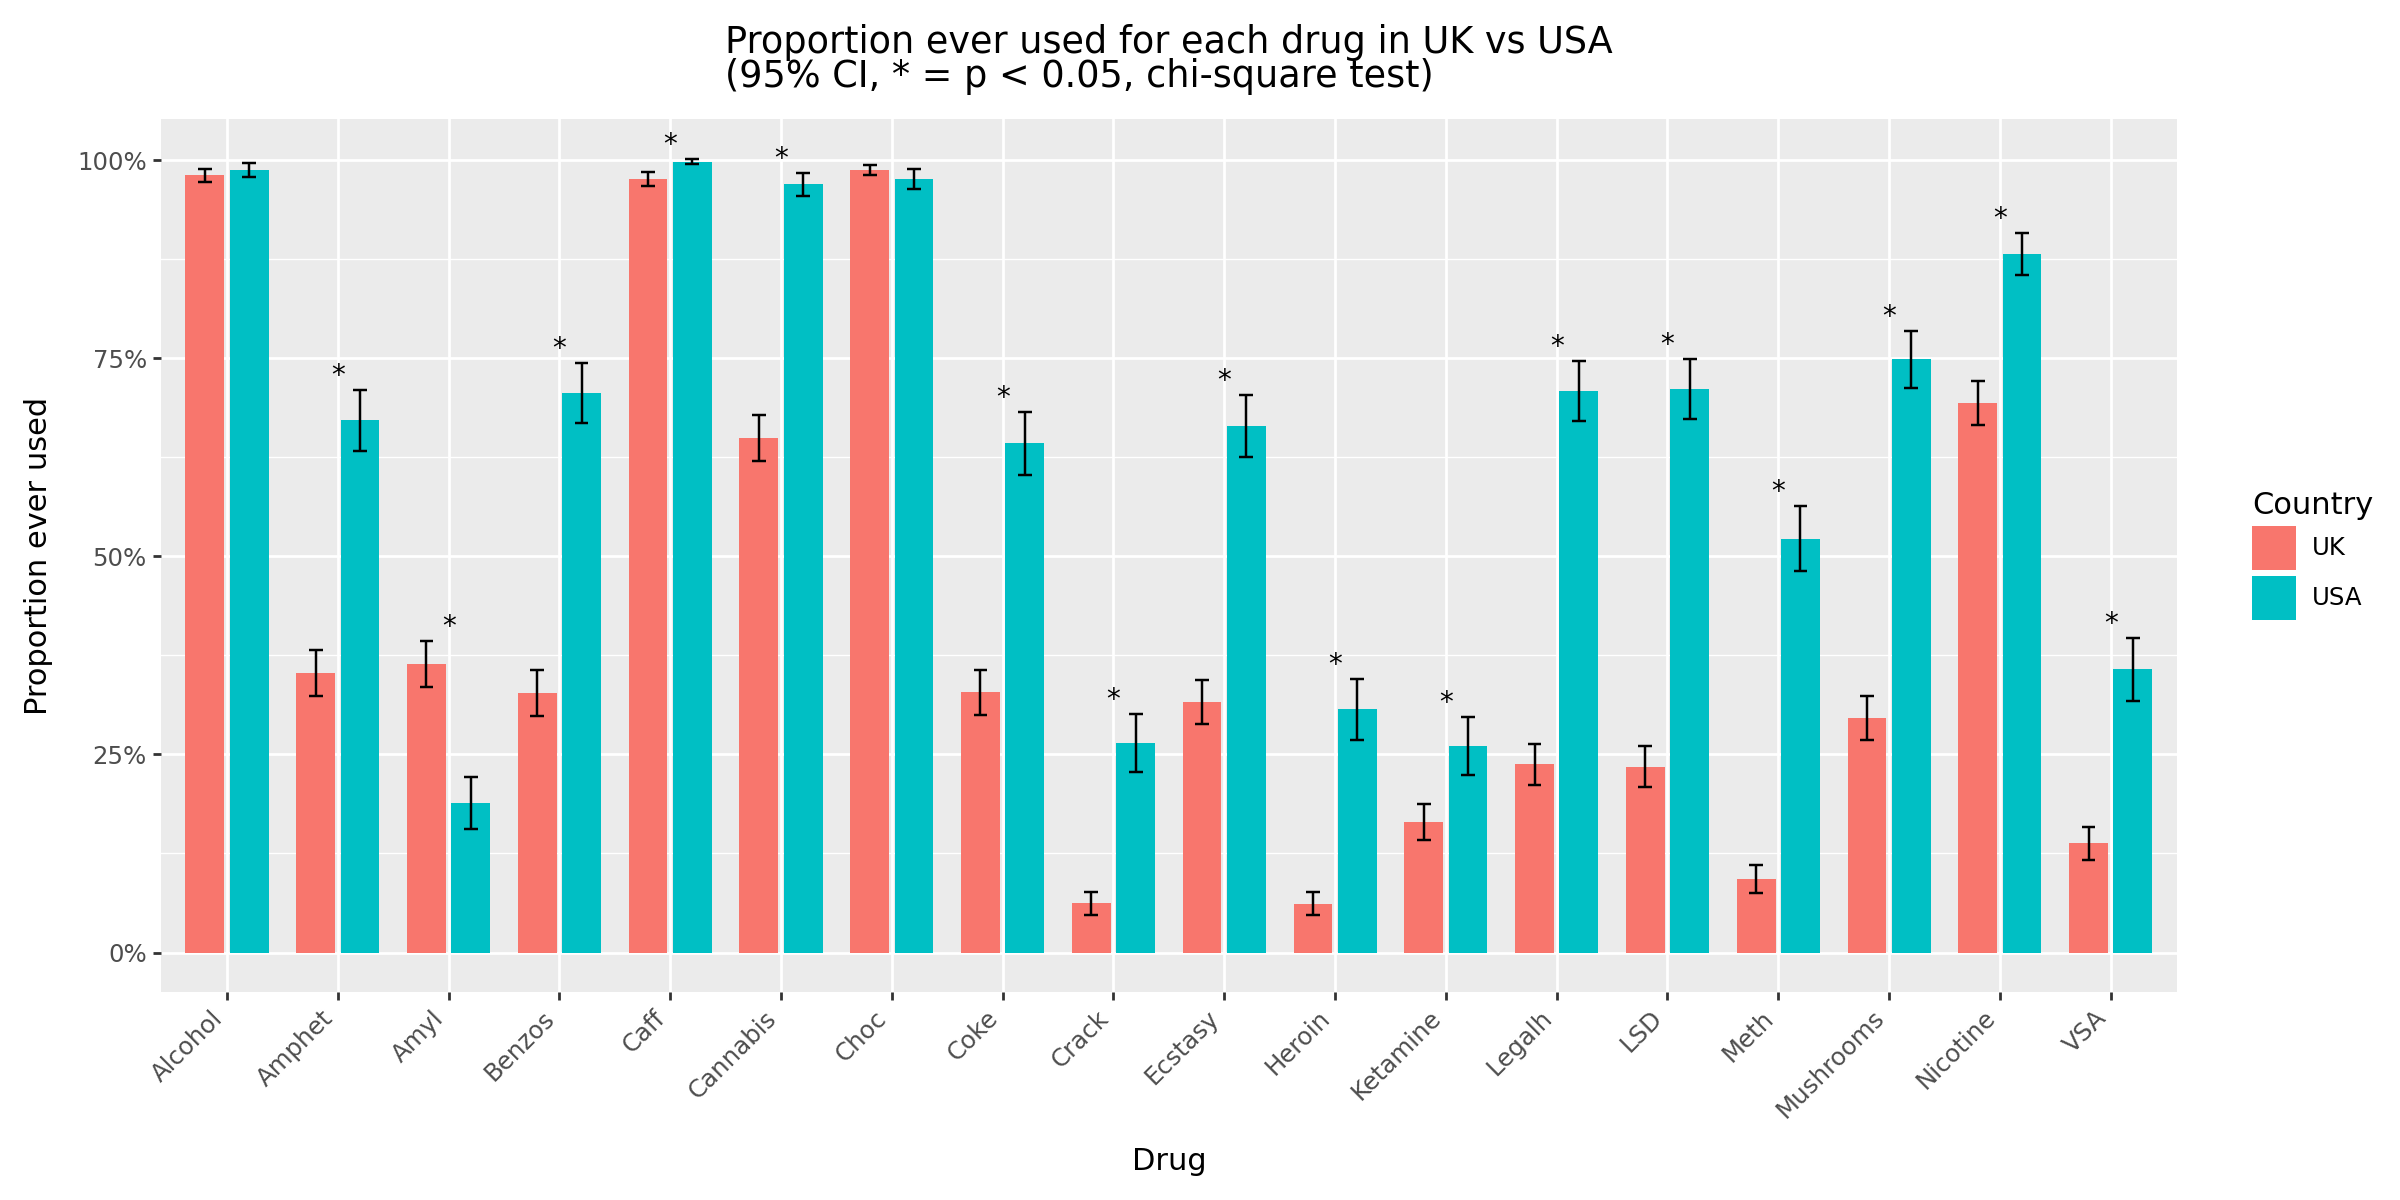

In [46]:
plot_all_drug_usage_country(data2)

In [47]:
from data_reading import PERSONALITY_TRAITS

In [48]:
def plot_all_traits_country(
    df: pd.DataFrame,
    traits=None,
    countries=("UK", "USA"),
):
    """
    Single plot:
      x-axis: Trait
      bars: mean score for UK vs USA
      error bars: 95% CI
      * above trait name if UK vs USA differ significantly (p < 0.05).
    """
    stats = compute_all_traits_country_ci(df, traits=traits, countries=countries)

    # Where to put the stars: per trait, above highest CI_high
    star_rows = (
        stats.groupby("Trait")["CI_high"]
        .max()
        .reset_index()
        .rename(columns={"CI_high": "y"})
    )

    sig_flags = (
        stats[["Trait", "Significant_p<0.05"]]
        .drop_duplicates("Trait")
    )
    star_rows = star_rows.merge(sig_flags, on="Trait", how="left")
    star_rows["label"] = star_rows["Significant_p<0.05"].map(lambda x: "*" if x else "")
    # little vertical margin above the bars
    star_rows["y"] = star_rows["y"] + 0.4

    p = (
        pn.ggplot(stats, pn.aes("Trait", "Mean", fill="Country"))
        + pn.geom_col(
            position=pn.position_dodge(width=0.8),
            width=0.7,
        )
        + pn.geom_errorbar(
            pn.aes(ymin="CI_low", ymax="CI_high"),
            position=pn.position_dodge(width=0.8),
            width=0.25,
        )
        + pn.geom_text(
            pn.aes(x="Trait", y="y", label="label"),
            data=star_rows,
            inherit_aes=False,
            size=10,
            va="bottom",
        )
        + pn.labs(
            title="Personality traits: UK vs USA (mean ± 95% CI; * = p < 0.05)",
            x="Trait",
            y="Mean score",
            fill="Country",
        )
        + pn.theme(
            figure_size=(10, 5),
            axis_text_x=pn.element_text(rotation=45, hjust=1),
        )
    )

    return p



/tmp/ipykernel_35366/1670009676.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


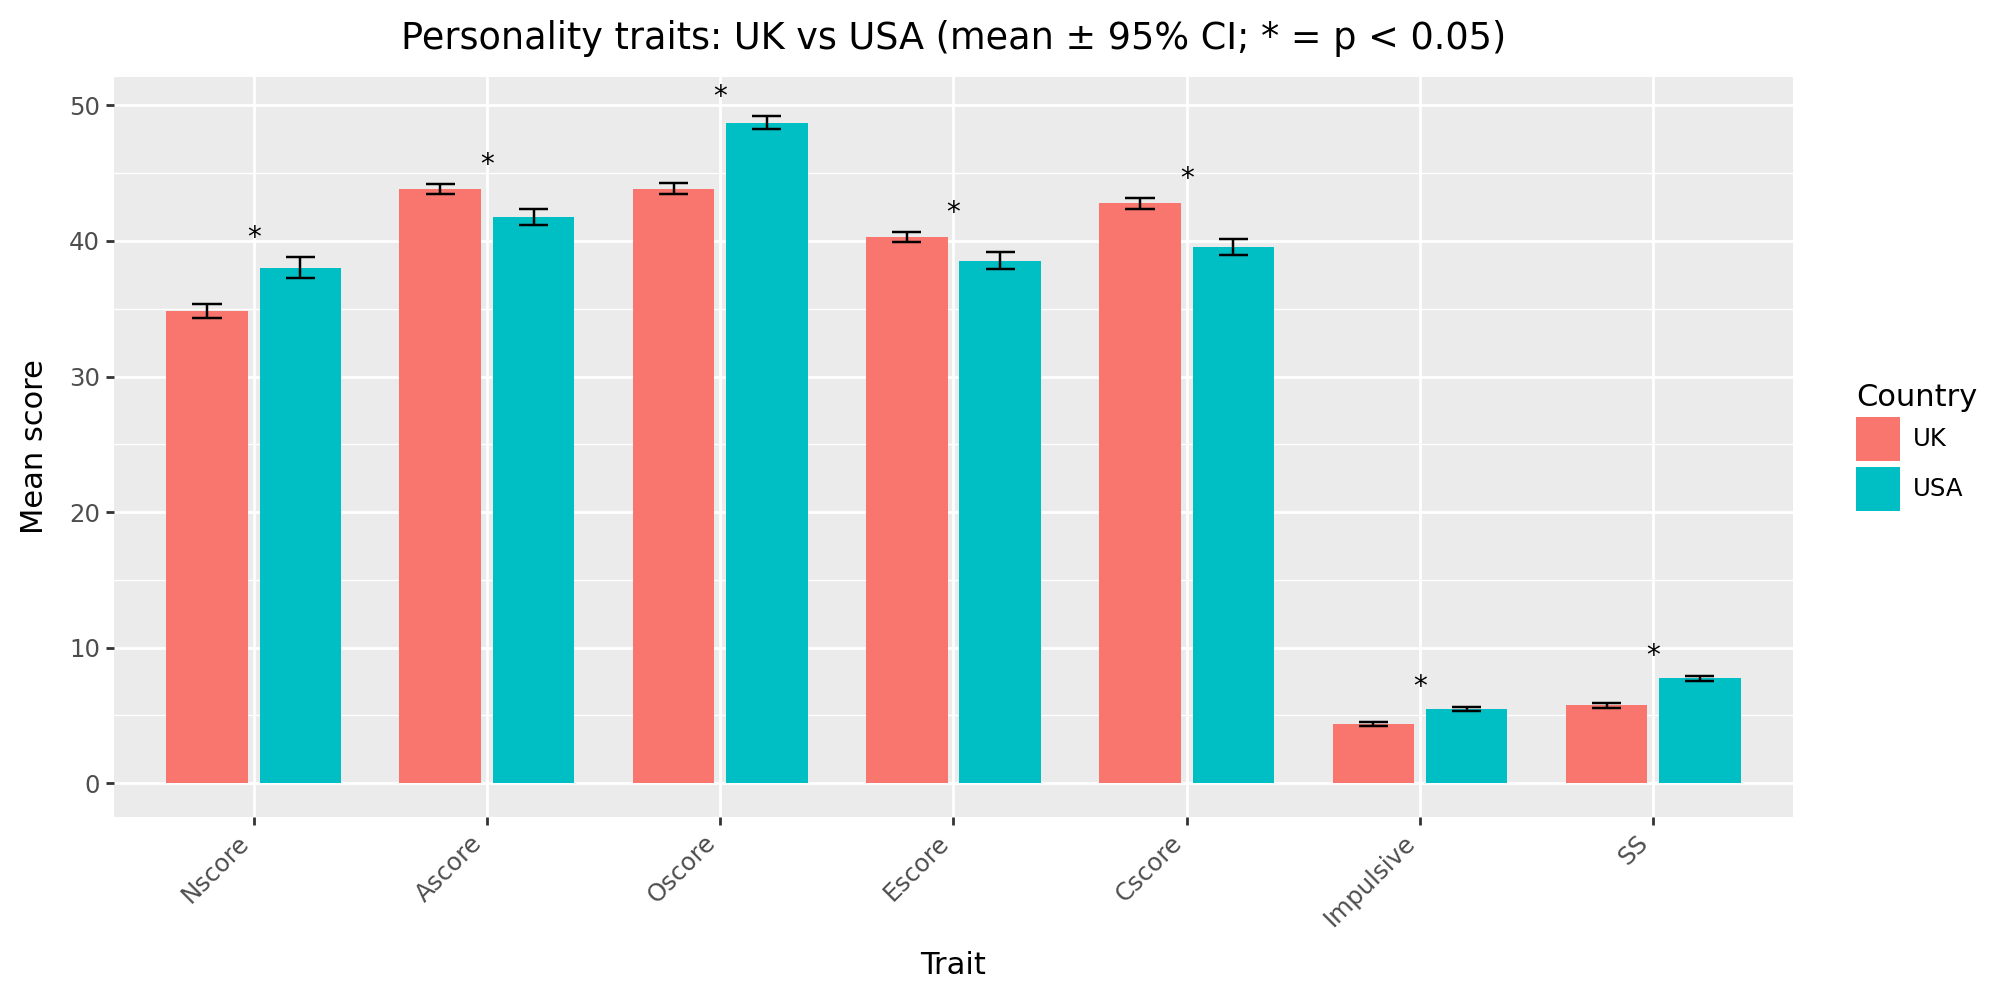

In [49]:
plot_all_traits_country(data2)

In [50]:
from data_reading import EDUCATION

In [51]:
def compute_edu_level_country_ci(
    df: pd.DataFrame,
    countries=("UK", "USA"),
    edu_labels=None,
):
    """
    For each education level and country, compute:
      - proportion of respondents with that level (Mean)
      - SD, SE, normal-approx 95% CI
      - raw counts (LevelCount, TotalCountryN)

    Returns a DataFrame with columns:
      Education, Country, Mean, SD, N, SE, CI_low, CI_high,
      LevelCount, TotalCountryN
    """
    df = df[df["Country"].isin(countries)].copy()

    # Use EDUCATION order if not specified
    if edu_labels is None:
        edu_labels = list(EDUCATION.values())

    all_rows = []
    for country in countries:
        sub = df[df["Country"] == country]
        total_n = len(sub)
        if total_n == 0:
            continue

        for edu in edu_labels:
            level_count = (sub["Education"] == edu).sum()
            p = level_count / total_n

            # Binomial approx
            sd = np.sqrt(p * (1 - p)) if total_n > 0 else np.nan
            n = total_n  # denominator for the proportion
            se = sd / np.sqrt(n) if n > 0 else np.nan
            z = 1.96
            ci_low = p - z * se
            ci_high = p + z * se

            all_rows.append(
                {
                    "Education": edu,
                    "Country": country,
                    "Mean": p,
                    "SD": sd,
                    "N": n,
                    "SE": se,
                    "CI_low": ci_low,
                    "CI_high": ci_high,
                    "LevelCount": level_count,
                    "TotalCountryN": total_n,
                }
            )

    stats = pd.DataFrame(all_rows)

    # keep a stable order on x-axis
    stats["Education"] = pd.Categorical(
        stats["Education"],
        categories=edu_labels,
        ordered=True,
    )

    return stats



In [52]:
def test_edu_level_country_diff(
    df: pd.DataFrame,
    level: str,
    countries=("UK", "USA"),
):
    """
    For a given education level, test if the proportion differs between countries.

    Constructs a 2x2 table:
      Country x {HasThisLevel, DoesNotHaveThisLevel}
    and runs chi-square test.

    Returns (chi2, p_value, significant_bool).
    """
    df = df[df["Country"].isin(countries)].copy()

    table = []
    for country in countries:
        sub = df[df["Country"] == country]
        has_level = (sub["Education"] == level).sum()
        not_level = len(sub) - has_level
        table.append([has_level, not_level])

    chi2, p_val, dof, expected = chi2_contingency(table)
    return chi2, p_val, bool(p_val < 0.05)



In [53]:
def compute_all_edu_levels_country_ci(
    df: pd.DataFrame,
    countries=("UK", "USA"),
    edu_labels=None,
):
    """
    For all education levels, compute:
      - proportion stats by country (Mean, CI, etc.)
      - chi-square p-value and significance per level.

    Returns a long DataFrame for plotting.
    """
    if edu_labels is None:
        edu_labels = list(EDUCATION.values())

    stats = compute_edu_level_country_ci(
        df,
        countries=countries,
        edu_labels=edu_labels,
    )

    # significance per level
    test_rows = []
    for level in edu_labels:
        chi2, p_val, sig = test_edu_level_country_diff(
            df,
            level=level,
            countries=countries,
        )
        test_rows.append(
            {
                "Education": level,
                "p_value": p_val,
                "Significant_p<0.05": sig,
            }
        )

    tests = pd.DataFrame(test_rows)

    stats = stats.merge(tests, on="Education", how="left")
    return stats



In [54]:
def plot_edu_levels_country(
    df: pd.DataFrame,
    countries=("UK", "USA"),
    edu_labels=None,
):
    """
    Single plot:
      x-axis: Education level
      bars: proportion of respondents in that level (UK vs USA)
      error bars: 95% CI
      * above level if proportions differ significantly (p < 0.05).
    """
    if edu_labels is None:
        edu_labels = list(EDUCATION.values())

    stats = compute_all_edu_levels_country_ci(
        df,
        countries=countries,
        edu_labels=edu_labels,
    )

    # Make sure Education is a categorical with the desired left→right order
    stats["Education"] = pd.Categorical(
        stats["Education"],
        categories=edu_labels,
        ordered=True,
    )

    print(stats)

    # positions for stars: per level, above highest CI_high
    star_rows = (
        stats.groupby("Education")["CI_high"]
        .max()
        .reset_index()
        .rename(columns={"CI_high": "y"})
    )

    sig_flags = (
        stats[["Education", "Significant_p<0.05"]]
        .drop_duplicates("Education")
    )
    star_rows = star_rows.merge(sig_flags, on="Education", how="left")
    star_rows["label"] = star_rows["Significant_p<0.05"].map(
        lambda x: "*" if x else ""
    )
    star_rows["y"] = star_rows["y"] + 0.02  # little margin above bars

    p = (
        pn.ggplot(stats, pn.aes("Education", "Mean", fill="Country"))
        + pn.geom_col(
            position=pn.position_dodge(width=0.8),
            width=0.7,
        )
        + pn.geom_errorbar(
            pn.aes(ymin="CI_low", ymax="CI_high"),
            position=pn.position_dodge(width=0.8),
            width=0.25,
        )
        + pn.geom_text(
            pn.aes(x="Education", y="y", label="label"),
            data=star_rows,
            inherit_aes=False,
            size=10,
            va="bottom",
        )
        + pn.scale_y_continuous(labels=lambda v: [f"{vv:.0%}" for vv in v])
        + pn.labs(
            title="Education distribution: UK vs USA "
                  "(proportion by level, 95% CI, * = p < 0.05)",
            x="Education level",
            y="Proportion of respondents",
            fill="Country",
        )
        + pn.theme(
            figure_size=(12, 6),
            axis_text_x=pn.element_text(rotation=45, hjust=1),
        )
    )

    return p



                              Education Country      Mean        SD     N  \
0           Left School Before 16 years      UK  0.017241  0.130170  1044   
1               Left School at 16 years      UK  0.072797  0.259803  1044   
2               Left School at 17 years      UK  0.012452  0.110892  1044   
3               Left School at 18 years      UK  0.033525  0.180003  1044   
4   Some College, No Certificate/Degree      UK  0.117816  0.322390  1044   
5      Professional Certificate/Diploma      UK  0.170498  0.376070  1044   
6                     University Degree      UK  0.304598  0.460237  1044   
7                       Master's Degree      UK  0.207854  0.405772  1044   
8                      Doctorate Degree      UK  0.063218  0.243355  1044   
9           Left School Before 16 years     USA  0.010772  0.103228   557   
10              Left School at 16 years     USA  0.016158  0.126083   557   
11              Left School at 17 years     USA  0.017953  0.132782   557   

/tmp/ipykernel_35366/3526659858.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


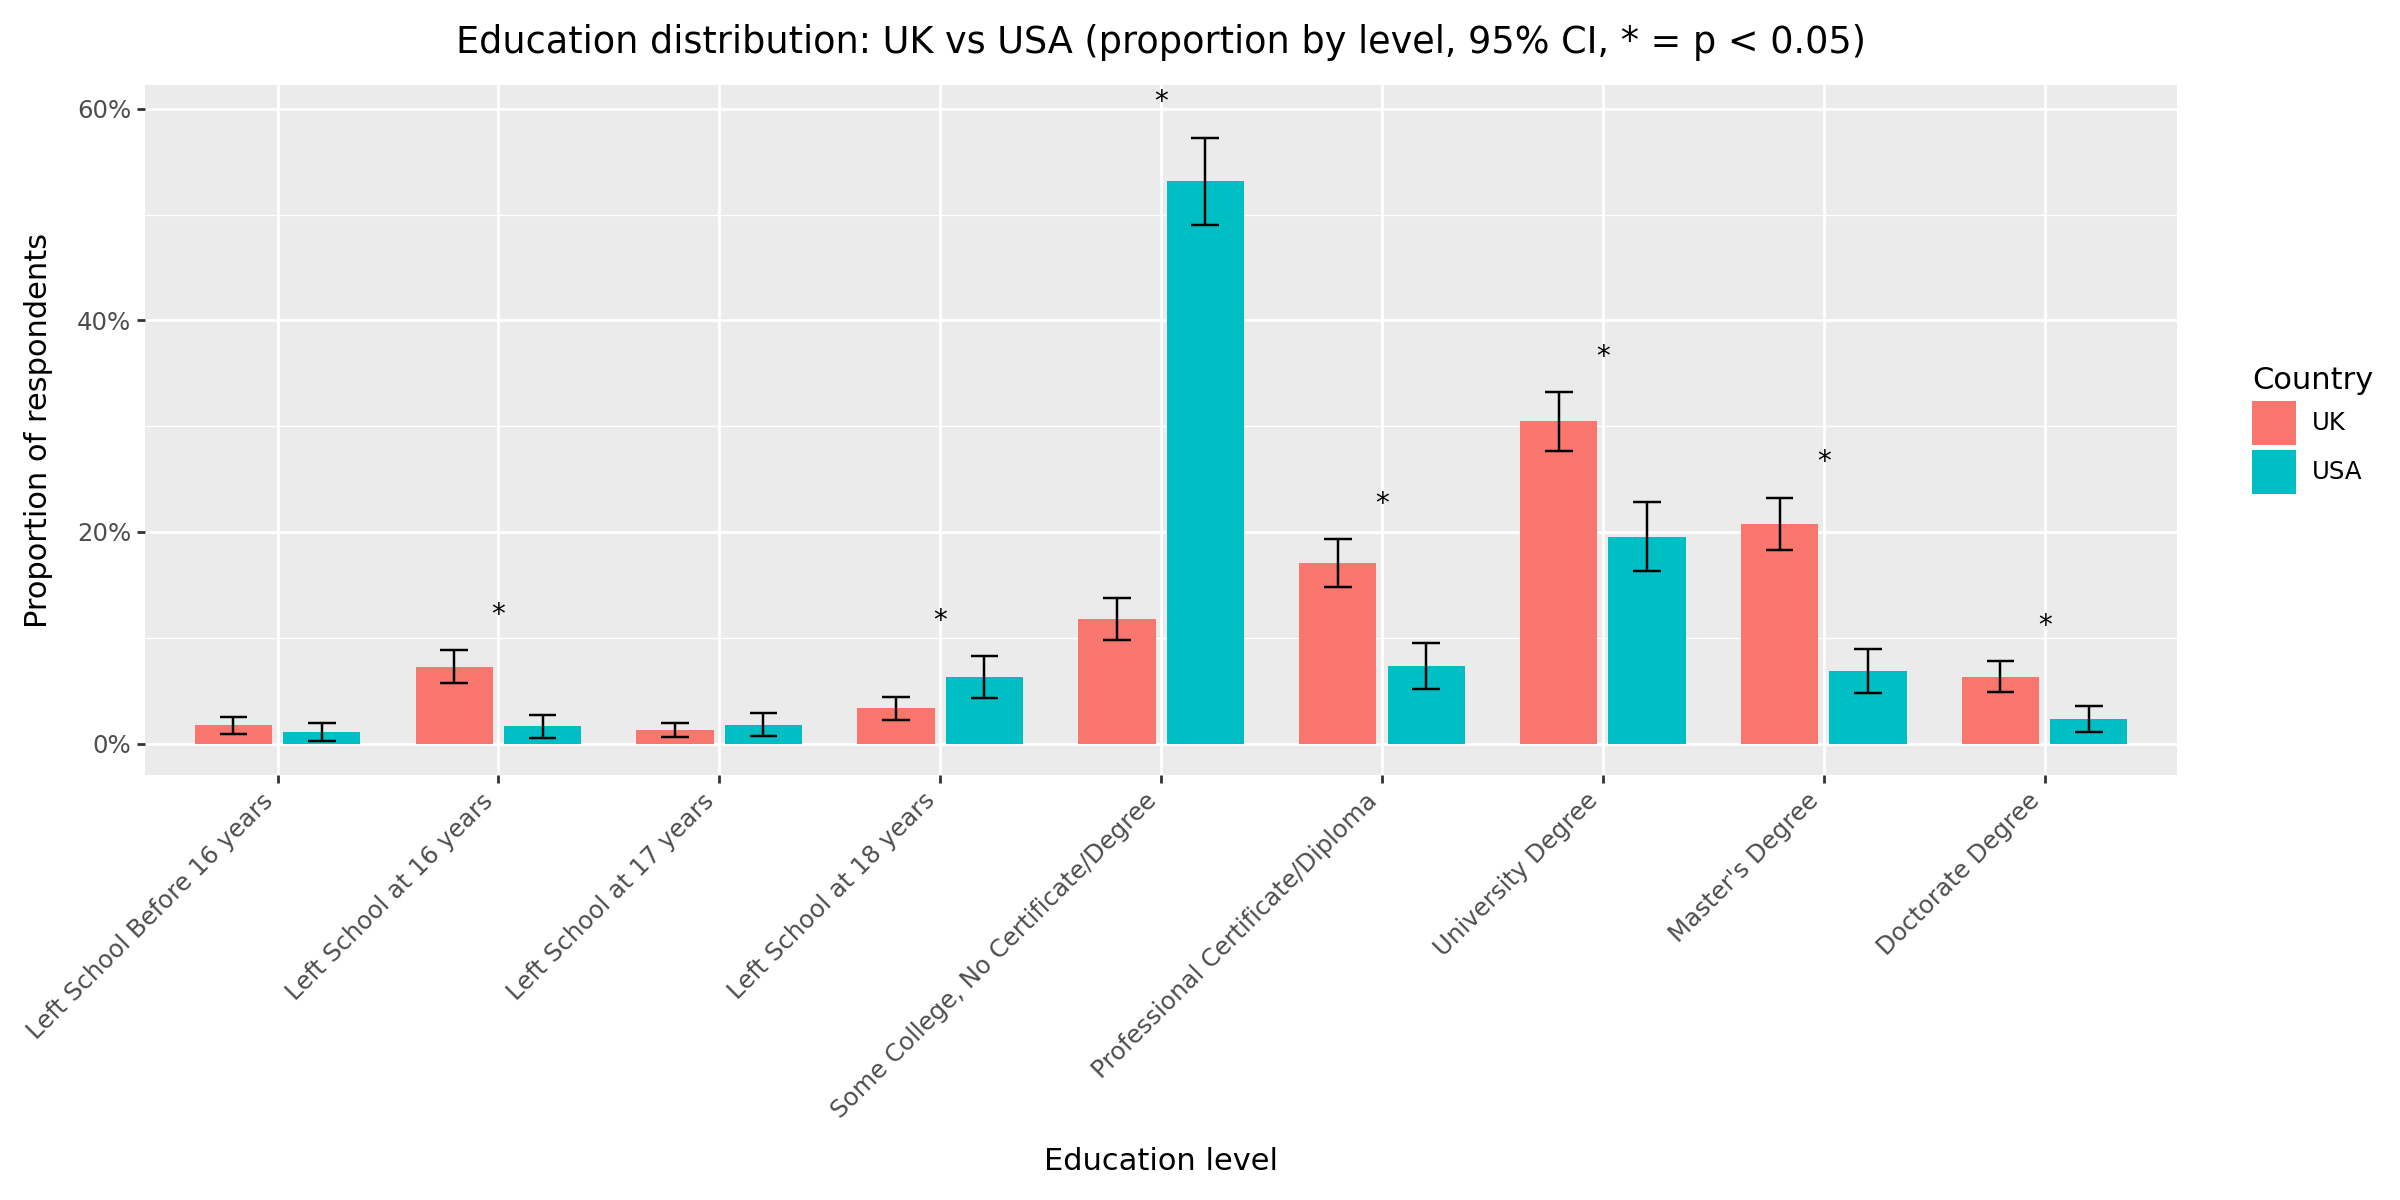

In [55]:
plot_edu_levels_country(data2)

Drug users per education level

In [56]:
drug_per_education = data_analysis.get_all_drug_usage_by_trait(human_readable_data, "Education")
#drug_per_education = drug_per_education[drug_per_education["Classifier"] != "Never Used"]
drug_per_education["Education"] = pd.Categorical(
        drug_per_education["Education"],
        categories=list(data_reading.EDUCATION.values()),
        ordered=True,
    )
drug_per_education_total = drug_per_education.copy()
drug_per_education_total

/home/rikkss/Documents/data-science-project/data_analysis.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


,Education,Drug,Classifier,Users
0,Left School Before 16 years,Alcohol,Used in Last Day,5
1,Left School Before 16 years,Alcohol,Used in Last Decade,2
2,Left School Before 16 years,Alcohol,Used in Last Week,11
3,Left School Before 16 years,Alcohol,Used in Last Year,4
4,Left School Before 16 years,Alcohol,Used over a Decade Ago,2
...,...,...,...,...
41,Master's Degree,VSA,Used in Last Year,2
42,Master's Degree,VSA,Used over a Decade Ago,20
43,Doctorate Degree,VSA,Never Used,63
44,Doctorate Degree,VSA,Used in Last Decade,1


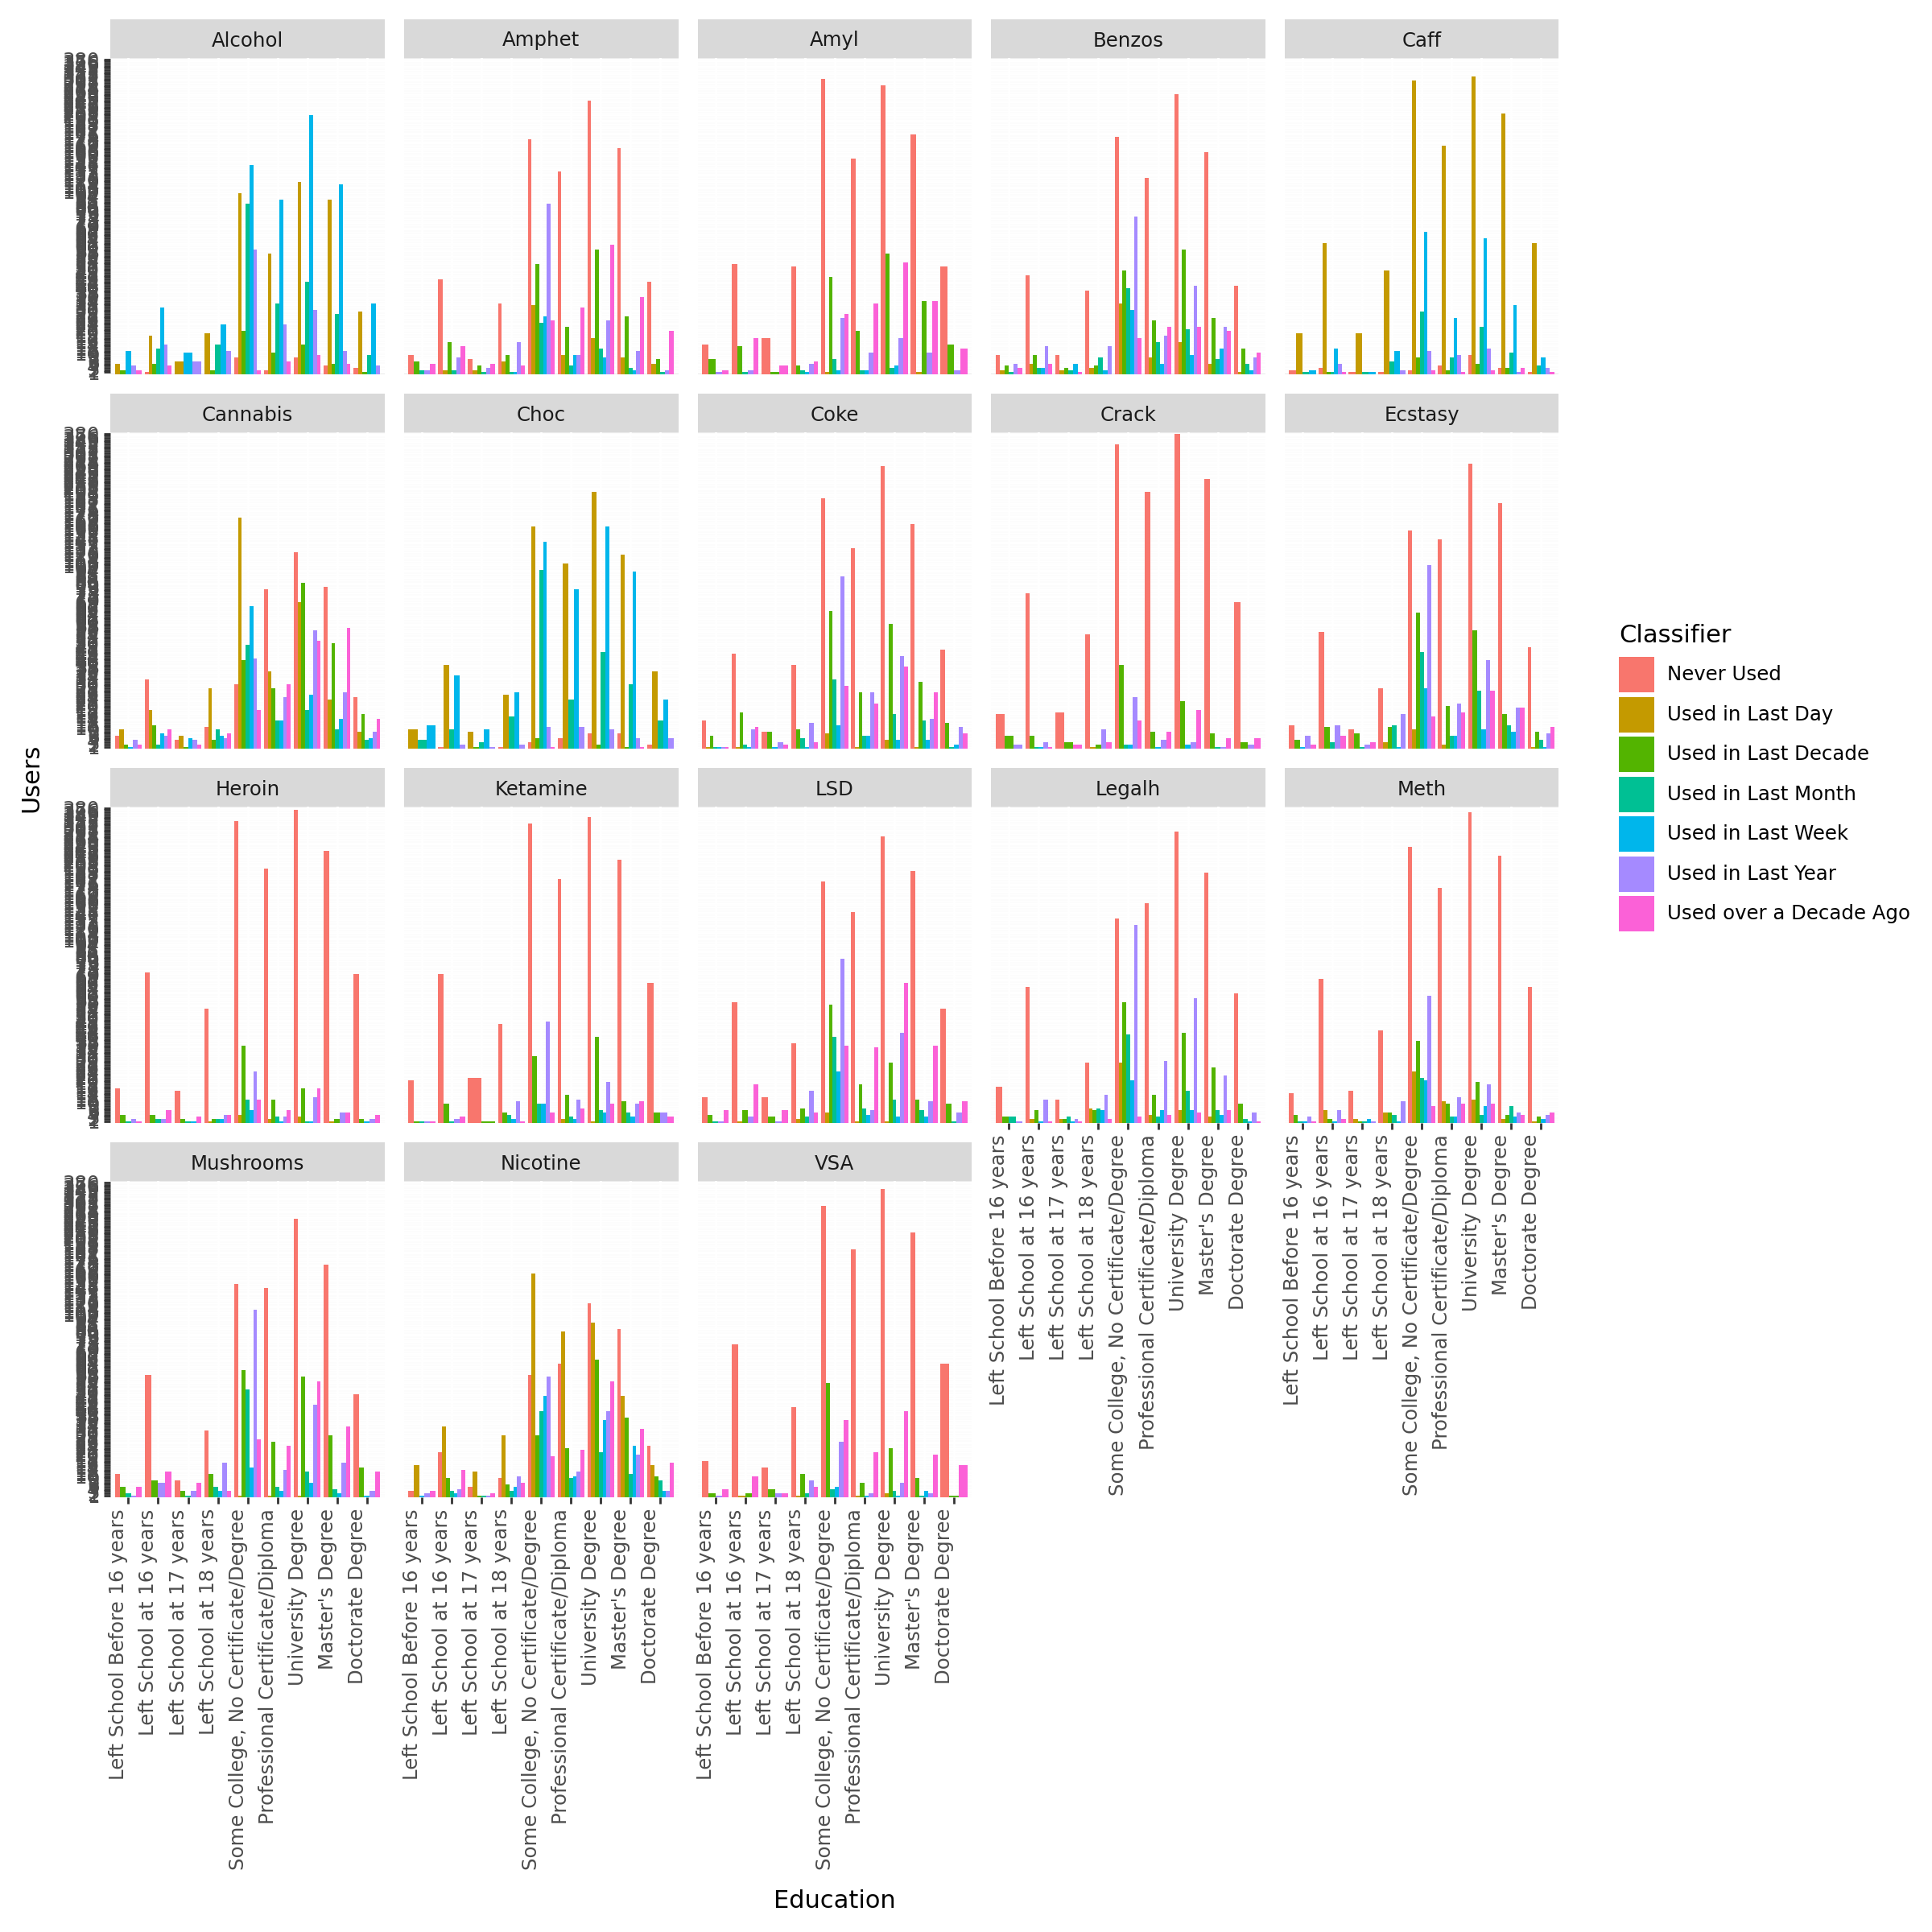

In [57]:
(
    pn.ggplot(drug_per_education, pn.aes("Education", "Users", fill="Classifier")) 
    + pn.geom_col(position="dodge")
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 12),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
    )
)

Taking into account the previously visualized amount of respondents per education level, the lower number of users in lower education categories makes sense. Thus, those need to be visualized proportionally to respondents per education level.

In [58]:
#total_drug_users_per_education = drug_per_education.copy()
#total_drug_users_per_education = total_drug_users_per_education.drop("Classifier", axis=1)
#total_drug_users_per_education = total_drug_users_per_education.groupby(["Education", "Drug"], observed=True).sum().reset_index()
#total_drug_users_per_education

drug_per_education["Relative"] = drug_per_education["Users"] / drug_per_education.groupby(["Education", "Drug"], observed=True).transform("sum")["Users"]
drug_per_education
#drug_per_education.groupby(["Education", "Drug"], observed=True).transform("sum")["Users"]

,Education,Drug,Classifier,Users,Relative
0,Left School Before 16 years,Alcohol,Used in Last Day,5,0.208333
1,Left School Before 16 years,Alcohol,Used in Last Decade,2,0.083333
2,Left School Before 16 years,Alcohol,Used in Last Week,11,0.458333
3,Left School Before 16 years,Alcohol,Used in Last Year,4,0.166667
4,Left School Before 16 years,Alcohol,Used over a Decade Ago,2,0.083333
...,...,...,...,...,...
41,Master's Degree,VSA,Used in Last Year,2,0.007843
42,Master's Degree,VSA,Used over a Decade Ago,20,0.078431
43,Doctorate Degree,VSA,Never Used,63,0.797468
44,Doctorate Degree,VSA,Used in Last Decade,1,0.012658


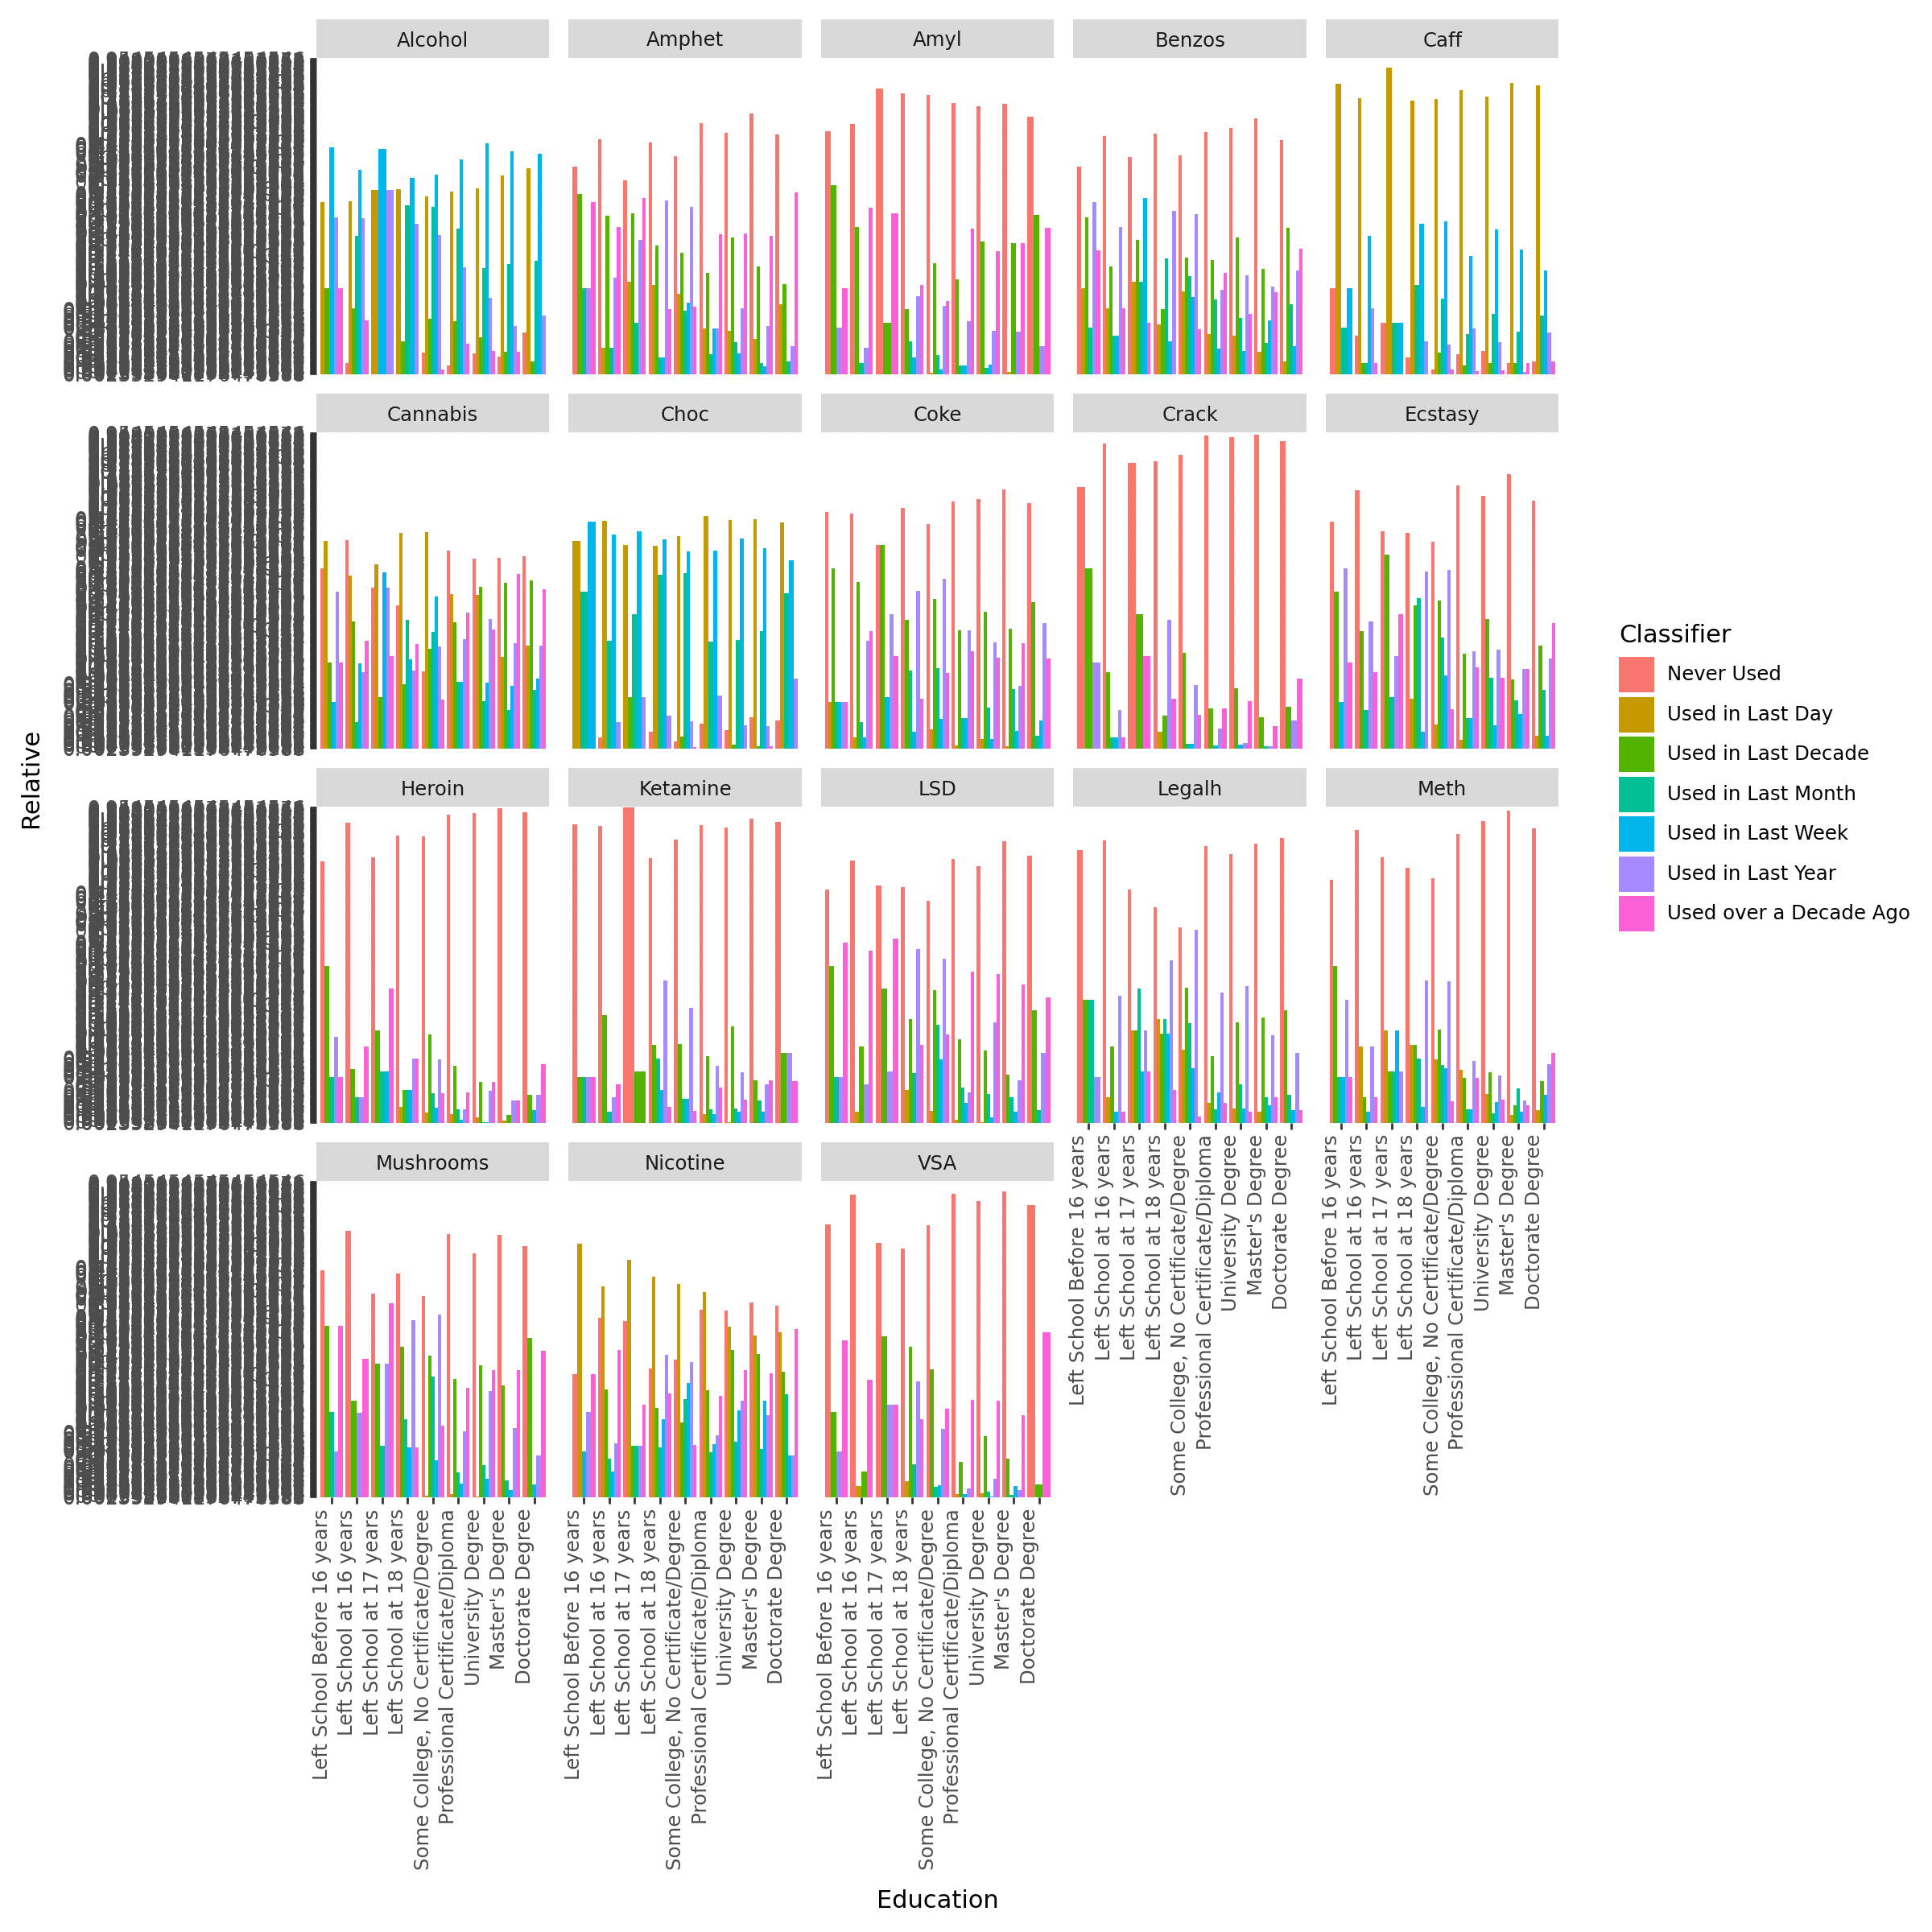

In [59]:
(
    pn.ggplot(drug_per_education, pn.aes("Education", "Relative", fill="Classifier")) 
    + pn.geom_col(position="dodge")
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 12),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
    )
)

Exclude non-users for clarity

In [ ]:
drug_per_education = drug_per_education[drug_per_education["Classifier"] != "Never Used"]
(
    pn.ggplot(drug_per_education, pn.aes("Education", "Relative", fill="Classifier")) 
    + pn.geom_col(position="dodge")
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 12),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
    )
)

For even more clarity, lets exclude the ones who haven't used the drug within the last year, to get the active users

In [ ]:
drug_per_education = drug_per_education[~drug_per_education["Classifier"].isin(["Used in Last Year", "Used over a Decade Ago", "Used in Last Decade"])]
(
    pn.ggplot(drug_per_education, pn.aes("Education", "Relative", fill="Classifier")) 
    + pn.geom_col()
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 12),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
        axis_text_y=pn.element_blank()
    )
)